In [1]:
# Install (run once on Kaggle)
!pip install -q neuroCombat polars pyarrow

  Preparing metadata (setup.py) ... done


In [2]:
!sudo apt-get update -qq
!sudo apt-get install -y texlive-latex-extra texlive-fonts-recommended dvipng cm-super


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-lato fonts-lmodern fonts-texgyre
  libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern pfb2t1c2pfb preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-recommended texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  libavalon-framework-java libcommons-loggin

In [3]:
from __future__ import annotations

import os, gc, warnings
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.stats import spearmanr, pearsonr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
import warnings
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
from __future__ import annotations
import os, re, math
from typing import Iterable, Set, Dict, Tuple, Sequence, List
from polars import selectors as cs
import polars as pl
from itertools import combinations
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.cm as cm
from scipy.stats import spearmanr
from matplotlib_venn import venn3
from matplotlib.patches import Patch

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

%config HistoryManager.enabled = False
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
# THESIS STYLE FOR PLOT
def apply_thesis_style(use_tex: bool = True,
                       legend_position: str = "upper right",
                       legend_outside: bool = False):
    """
    Applies a uniform style (Matplotlib + Seaborn) consistent with LaTeX
    and defines `place_legend()` to position legends consistently.

    Parameters
    ----------
    use_tex : bool
        If True, enables LaTeX text rendering (requires TeX installed).
    legend_position : str
        DEFAULT position for legends: 'upper right', 'upper left',
        'lower right', 'lower left', 'center', 'best' (also accepts 'top/bottom').
    legend_outside : bool
        If True, the default legend is outside the plot (to the right).
    """

    # --- Normalize default position ---
    def _normalize_pos(pos: str) -> str:
        if not isinstance(pos, str):
            return "upper right"
        key = pos.strip().lower().replace("top", "upper").replace("bottom", "lower")
        mapping = {
            "upper right": "upper right",
            "upper left":  "upper left",
            "lower right": "lower right",
            "lower left":  "lower left",
            "center":      "center",
            "best":        "best",
        }
        return mapping.get(key, "upper right")

    _default_loc = _normalize_pos(legend_position)

    # --- Seaborn theme + rcParams consistent with thesis ---
    sns.set_theme(style="whitegrid", context="notebook")
    mpl.rcParams.update({
        # Typography
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "Latin Modern Roman", "Times New Roman"],
        "mathtext.fontset": "cm",
        "text.usetex": bool(use_tex),

        # Sizes
        "figure.figsize": (6.8, 4.5),
        "font.size": 8.5,          # generic text (plt.text, etc.)
        "axes.labelsize": 10.5,    # axis labels
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9.5,
        "legend.title_fontsize": 9.5,

        # Axes look
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.facecolor": "white",
        "axes.edgecolor": "#D0D0D0",
        "axes.linewidth": 0.8,

        # Legend style (default; can be overridden by place_legend)
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "#D0D0D0",
        "legend.loc": _default_loc,
        "legend.framealpha": 1.0,
        "legend.handlelength": 1.8,
        "legend.handletextpad": 0.6,
        "legend.borderpad": 0.4,
        "legend.borderaxespad": 0.8,
    })

    def place_legend(ax=None,
                     position: str | None = None,
                     outside: bool | None = None,
                     fontsize: float | None = None):
        """
        Places the legend on an axis with consistent thesis style.

        Parameters
        ----------
        ax : matplotlib.axes.Axes, optional
            Axis on which to place the legend (default: current axis).
        position : str | None
            'upper right', 'upper left', 'lower right', 'lower left', 'center', 'best'.
            If None, uses the default position passed to apply_thesis_style().
            Spaces/caps tolerated; 'top/bottom' mapped to 'upper/lower'.
        outside : bool | None
            If True, places the legend outside the plot (to the right).
            If None, uses the default value passed to apply_thesis_style().
        fontsize : float | None
            To change the legend font size only in this plot.
        """

        if ax is None:
            ax = plt.gca()

        # Normalize requested position or use global default
        loc_val = _default_loc
        if isinstance(position, str):
            key = position.strip().lower().replace("top", "upper").replace("bottom", "lower")
            loc_map = {
                "upper right": "upper right",
                "upper left":  "upper left",
                "lower right": "lower right",
                "lower left":  "lower left",
                "center":      "center",
                "best":        "best",
            }
            loc_val = loc_map.get(key, _default_loc)

        # outside: if None, inherit from default; otherwise use override
        outside = (legend_outside if outside is None else bool(outside))

        # Build kwargs consistent with rcParams
        legend_kwargs = dict(
            loc=loc_val,
            frameon=True,
            facecolor="white",
            edgecolor=mpl.rcParams["legend.edgecolor"],
            framealpha=1.0,
            fontsize=mpl.rcParams["legend.fontsize"] if fontsize is None else fontsize,
            handlelength=1.8,
            handletextpad=0.6,
            borderpad=0.4,
            fancybox=False,
        )

        if outside:
            legend_kwargs.update({
                "bbox_to_anchor": (1.02, 1.0),
                "borderaxespad": 0.0,
            })

        leg = ax.legend(**legend_kwargs)
        if leg is not None:
            leg.get_frame().set_linewidth(0.8)
            leg.get_frame().set_edgecolor(mpl.rcParams["legend.edgecolor"])
            leg.get_frame().set_facecolor("white")
        return ax

    # Export the helper to the global notebook/script namespace
    globals()["place_legend"] = place_legend
    

apply_thesis_style(use_tex=True)

# Palette fissa per dataset

DS_PALETTE = {
        "GSE225845": plt.cm.viridis(0.50),
        "GSE287331": plt.cm.viridis(0.80)
    }
DS_PALETTE_VIRIDIS = {
        0: plt.cm.viridis(0.4),
        1: plt.cm.viridis(0.7),
    }

In [5]:
# CELLA 1 — Setup e Config
import os
import re
import numpy as np
import pandas as pd
import polars as pl
from sklearn.model_selection import train_test_split

# ── PATHS ──────────────────────────────────────────────────────────────────────
BETA_PATHS = {
    "GSE225845": "/kaggle/input/datasets/rovieramariella/gse225845-parquet/GSE225845.parquet",
    "GSE287331": "/kaggle/input/datasets/rovieramariella/3-gse287331-parquet/GSE287331_clean_imputed.parquet",
}

PHENO_PATHS = {
    "GSE225845": "/kaggle/input/datasets/rovieramariella/pheno-gse225845-with-true-age-bins/pheno_GSE225845_with_true_age_bins.parquet",
    "GSE287331": "/kaggle/input/datasets/rovieramariella/pheno-gse287331-with-age-bin/pheno_GSE287331_with_age_bin.parquet",
}

AGE_PATHS = {
    "GSE287331": "/kaggle/input/datasets/rovieramariella/output-gse287331-horvathdnamage-normal-adj-only-cs/Output_GSE287331_HorvathDNAmAge_normal_adj_only.csv",
}

OUTPUT_DIR = "/kaggle/working/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAMPLE_ID   = "id_tissue"
LABEL_COL   = "label"
RANDOM_STATE = 42

In [6]:
# CELLA 2 — Helpers
def require_cols(df, cols, tag):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"{tag} missing columns: {missing}")

def parse_idat_basename(idat):
    if idat is None or (isinstance(idat, float) and pd.isna(idat)):
        return (None, None)
    s = str(idat).strip()
    if not s:
        return (None, None)
    m = re.search(r"(\d{8,})\s*[_-]?\s*(R\d{2}C\d{2})", s)
    if not m:
        return (None, None)
    return (m.group(1), m.group(2))

def read_horvath_age_csv(path):
    df = pd.read_csv(path).copy()
    cols_lc = {c.lower(): c for c in df.columns}
    if "id_tissue" not in df.columns:
        if "sampleid" in cols_lc:
            df = df.rename(columns={cols_lc["sampleid"]: "id_tissue"})
        else:
            raise KeyError(f"Age file {path} missing id column.")
    if "age" not in df.columns:
        if "dnamage" in cols_lc:
            df = df.rename(columns={cols_lc["dnamage"]: "age"})
        else:
            raise KeyError(f"Age file {path} missing age column.")
    df["id_tissue"] = df["id_tissue"].astype(str)
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    return df[["id_tissue", "age"]].drop_duplicates("id_tissue")

_NON_CPG = {"id_tissue", "label", "sample_id", "barcode", "index"}

def get_cpg_cols(df: pl.DataFrame) -> list[str]:
    return [c for c in df.columns if c not in _NON_CPG]

In [7]:
# CELLA 3 — Build meta per tutti e tre i dataset
meta = {}

for ds in ["GSE225845", "GSE287331"]:
    print("\n" + "=" * 80)
    print(f"BUILD META — {ds}")
    print("=" * 80)

    # 1) id + label dalla beta — solo 2 colonne, polars fa projection pushdown
    beta_meta = (
        pl.scan_parquet(BETA_PATHS[ds])
        .select([SAMPLE_ID, LABEL_COL])
        .collect()
        .to_pandas()
    )
    beta_meta[SAMPLE_ID] = beta_meta[SAMPLE_ID].astype(str)

    # 2) pheno
    pheno = pd.read_parquet(PHENO_PATHS[ds]).copy()
    require_cols(pheno, [SAMPLE_ID], tag=f"[{ds}] pheno")
    pheno[SAMPLE_ID] = pheno[SAMPLE_ID].astype(str)

    # 3) SentrixID + ChipPosition da idat_basename (se presente)
    if "idat_basename" in pheno.columns:
        tech = pheno["idat_basename"].apply(
            lambda x: pd.Series(parse_idat_basename(x), index=["SentrixID", "ChipPosition"])
        )
        pheno = pd.concat([pheno, tech], axis=1)
    else:
        # GSE69914 potrebbe avere sentrix_id / slide_id diretti
        if "sentrix_id" in pheno.columns:
            pheno["SentrixID"] = pheno["sentrix_id"].astype(str)
        elif "slide_id" in pheno.columns:
            pheno["SentrixID"] = pheno["slide_id"].astype(str)
        else:
            pheno["SentrixID"] = None
        pheno["ChipPosition"] = None
        pheno["idat_basename"] = None

    # 4) age
    if ds == "GSE225845":
        require_cols(pheno, ["age_at_surgery"], tag=f"[{ds}] pheno (age)")
        pheno["age"] = pd.to_numeric(pheno["age_at_surgery"], errors="coerce")
    else:
        # GSE69914 e GSE287331: da file Horvath
        age_df = read_horvath_age_csv(AGE_PATHS[ds])
        pheno = pheno.merge(age_df, on="id_tissue", how="left")

    # 5) pheno minimale
    keep = ["id_tissue", "idat_basename", "SentrixID", "ChipPosition", "age"]
    pheno_small = pheno[[c for c in keep if c in pheno.columns]].drop_duplicates("id_tissue")

    # 6) merge con beta meta
    meta_df = beta_meta.merge(pheno_small, on="id_tissue", how="left")

    # salva Tumor separatamente prima di filtrare
    meta_tumor_ds = meta_df[meta_df[LABEL_COL] == 2].copy()
    meta_tumor_ds["dataset_origin"] = ds
    # accumula fuori dal loop
    if "meta_tumor_list" not in dir():
        meta_tumor_list = []
    meta_tumor_list.append(meta_tumor_ds)

    # 7) filtra solo Normal (0) e Adjacent (1)
    meta_df = meta_df[meta_df[LABEL_COL].isin([0, 1])].copy()
    meta_df.reset_index(drop=True, inplace=True)

    # 8) imputa age mancante con mediana del dataset
    age_median = meta_df["age"].median()
    n_age_na = meta_df["age"].isna().sum()
    meta_df["age"] = meta_df["age"].fillna(age_median)

    # 9) dataset_origin
    meta_df["dataset_origin"] = ds

    # 10) diagnostics
    n = len(meta_df)
    print(f"  n samples (N+A): {n}")
    print(f"  label dist:      {meta_df[LABEL_COL].value_counts().to_dict()}")
    print(f"  age NA imputati: {n_age_na}/{n}  (mediana={age_median:.1f})")
    print(f"  SentrixID unici: {meta_df['SentrixID'].nunique()}")

    meta[ds] = meta_df

meta_225 = meta["GSE225845"]
meta_287 = meta["GSE287331"]

print("\nDONE — meta_69, meta_225, meta_287 in scope.")

meta_tumor = pd.concat(meta_tumor_list, ignore_index=True)
print(f"Tumor samples: {len(meta_tumor)}")
print(meta_tumor["dataset_origin"].value_counts())


BUILD META — GSE225845
  n samples (N+A): 253
  label dist:      {1: 140, 0: 113}
  age NA imputati: 0/253  (mediana=48.0)
  SentrixID unici: 57

BUILD META — GSE287331
  n samples (N+A): 242
  label dist:      {0: 182, 1: 60}
  age NA imputati: 0/242  (mediana=51.3)
  SentrixID unici: 35

DONE — meta_69, meta_225, meta_287 in scope.
Tumor samples: 293
dataset_origin
GSE225845    224
GSE287331     69
Name: count, dtype: int64


In [8]:
# CELLA 4 — STEP 0: Train/Test split stratificato (PRIMA DI TUTTO)
from sklearn.model_selection import train_test_split

# unifica meta
meta_all = pd.concat([meta_225, meta_287], ignore_index=True)
meta_all["stratum"] = meta_all["dataset_origin"] + "_" + meta_all[LABEL_COL].map({0: "N", 1: "A"})

print("Distribuzione strati:")
print(meta_all["stratum"].value_counts().sort_index())

idx_all = np.arange(len(meta_all))
idx_train, idx_test = train_test_split(
    idx_all,
    test_size=0.30,
    stratify=meta_all["stratum"].values,
    random_state=RANDOM_STATE,
)

meta_train = meta_all.iloc[idx_train].reset_index(drop=True)
meta_test  = meta_all.iloc[idx_test].reset_index(drop=True)

print(f"\nTrain: {len(meta_train)} samples")
print(meta_train["stratum"].value_counts().sort_index())
print(f"\nTest:  {len(meta_test)} samples")
print(meta_test["stratum"].value_counts().sort_index())

# salva
meta_train.to_parquet(os.path.join(OUTPUT_DIR, "meta_train.parquet"), index=False)
meta_test.to_parquet(os.path.join(OUTPUT_DIR,  "meta_test.parquet"),  index=False)

train_ids = set(meta_train[SAMPLE_ID].tolist())
test_ids  = set(meta_test[SAMPLE_ID].tolist())
assert len(train_ids & test_ids) == 0, "LEAKAGE: campioni in comune tra train e test!"
print("\nSplit OK — nessun leakage.")

Distribuzione strati:
stratum
GSE225845_A    140
GSE225845_N    113
GSE287331_A     60
GSE287331_N    182
Name: count, dtype: int64

Train: 346 samples
stratum
GSE225845_A     98
GSE225845_N     79
GSE287331_A     42
GSE287331_N    127
Name: count, dtype: int64

Test:  149 samples
stratum
GSE225845_A    42
GSE225845_N    34
GSE287331_A    18
GSE287331_N    55
Name: count, dtype: int64

Split OK — nessun leakage.


In [9]:
# salva split come CSV leggero per riproducibilità
split_df = pd.concat([
    meta_train[[SAMPLE_ID, "dataset_origin"]].assign(split="train"),
    meta_test[[SAMPLE_ID,  "dataset_origin"]].assign(split="test"),
], ignore_index=True)

split_df.to_csv(os.path.join(OUTPUT_DIR, "train_test_split.csv"), index=False)
print(f"\nSplit salvato in: {OUTPUT_DIR}train_test_split.csv")
print(split_df["split"].value_counts())


Split salvato in: /kaggle/working/train_test_split.csv
split
train    346
test     149
Name: count, dtype: int64


In [10]:
# CELLA 5 — STEP 1: Intersezione CpG comuni tra i tre dataset
# ── PATHS blacklist (una per dataset) ─────────────────────────────────────────
BLACKLIST_PATHS = {
    "GSE225845": "/kaggle/input/datasets/rovieramariella/removed-cpgs-all-filters-summary-gse225845/removed_cpgs_all_filters_summary_gse225845.csv",
    "GSE287331": "/kaggle/input/datasets/rovieramariella/removed-cpgs-all-filters-summary-gse287331/removed_cpgs_all_filters_summary_gse287331.csv",
}

BLACKLIST_CPG_COL = "CpG_ID"

# ── STEP 1: schema CpG per dataset ────────────────────────────────────────────
print("Lettura schema beta con polars lazy...")
cpg_sets = {}
for ds, path in BETA_PATHS.items():
    all_cols = pl.scan_parquet(path).columns
    cpg_sets[ds] = {c for c in all_cols if c not in _NON_CPG}
    print(f"  {ds}: {len(cpg_sets[ds]):,} CpG")



# ── STEP 2: intersezione 3-way ─────────────────────────────────────────────────
common_cpgs_set = cpg_sets["GSE225845"] & cpg_sets["GSE287331"] 
print(f"\nCpG comuni (3-way, pre-blacklist): {len(common_cpgs_set):,}")

# ── STEP 3: carica le blacklist e uniscile ─────────────────────────────────────
blacklist_union = set()
for ds, bl_path in BLACKLIST_PATHS.items():
    bl = pl.read_csv(bl_path).select(
        pl.col(BLACKLIST_CPG_COL).cast(pl.Utf8)
    ).unique().to_series().to_list()
    bl_set = set(bl)
    overlap = bl_set & common_cpgs_set
    print(f"  blacklist {ds}: {len(bl_set):,} totali, {len(overlap):,} nell'intersezione")
    blacklist_union |= bl_set
print(f"\nBlacklist union: {len(blacklist_union):,} CpG unici")

# ── STEP 4: rimuovi blacklist dall'intersezione ────────────────────────────────
cpgs_after_blacklist = common_cpgs_set - blacklist_union
print(f"CpG dopo rimozione blacklist: {len(cpgs_after_blacklist):,}")
print(f"CpG rimossi dalla blacklist : {len(common_cpgs_set) - len(cpgs_after_blacklist):,}")

# ── STEP 5: preserva ordine GSE225845 ─────────────────────────────────────────
ref_order   = [c for c in pl.scan_parquet(BETA_PATHS["GSE225845"]).columns
               if c not in _NON_CPG]
common_cpgs = [c for c in ref_order if c in cpgs_after_blacklist]
print(f"\nCpG finali (ordine GSE225845): {len(common_cpgs):,}")
with open(os.path.join(OUTPUT_DIR, "common_cpgs_3way_filtered.txt"), "w") as f:
    f.write("\n".join(common_cpgs))
print("Salvato: common_cpgs_3way_filtered.txt")

Lettura schema beta con polars lazy...
  GSE225845: 750,426 CpG
  GSE287331: 703,166 CpG

CpG comuni (3-way, pre-blacklist): 660,280
  blacklist GSE225845: 219,743 totali, 174,827 nell'intersezione
  blacklist GSE287331: 216,193 totali, 174,827 nell'intersezione

Blacklist union: 261,109 CpG unici
CpG dopo rimozione blacklist: 485,453
CpG rimossi dalla blacklist : 174,827

CpG finali (ordine GSE225845): 485,453
Salvato: common_cpgs_3way_filtered.txt


In [11]:
# CELLA 6 — Diagnosi polarity inversion (su tutti i campioni, post-blacklist)
# Calcola Δβ (Adjacent - Normal) per ciascun dataset e misura la concordanza
# tra GSE225845 e GSE287331 sui 485,453 CpG comuni filtrati.
# La diagnosi avviene sui β grezzi (prima di qualsiasi trasformazione).

from scipy.stats import spearmanr

print("Carico beta matrices (solo common_cpgs, solo Normal+Adjacent)...")
B = {}
for ds in ["GSE225845", "GSE287331"]:
    beta_full = (
        pl.scan_parquet(BETA_PATHS[ds])
        .select([SAMPLE_ID, LABEL_COL] + common_cpgs)
        .collect()
        .filter(pl.col(LABEL_COL).is_in([0, 1]))
    )
    B[ds] = beta_full
    print(f"  {ds}: {beta_full.shape}")

print("\nCalcolo Δβ per dataset...")
delta = {}
for ds in ["GSE225845", "GSE287331"]:
    df     = B[ds].to_pandas()
    beta   = df[common_cpgs].values.astype(np.float32)
    labels = df[LABEL_COL].values.astype(int)   # cast esplicito → sicuro per ==

    mu_N = beta[labels == 0].mean(axis=0)
    mu_A = beta[labels == 1].mean(axis=0)
    delta[ds] = mu_A - mu_N

    print(f"  {ds}: Normal={( labels==0).sum()}  Adjacent={(labels==1).sum()}"
          f"  mean|Δβ|={np.abs(delta[ds]).mean():.4f}")

# ── Concordanza tra i due dataset ─────────────────────────────────────────────
d225 = delta["GSE225845"]
d287 = delta["GSE287331"]

rho, pval        = spearmanr(d225, d287)
sign_concordance = np.mean(np.sign(d225) == np.sign(d287))

print("\n" + "=" * 60)
print("POLARITY DIAGNOSIS — GSE225845 vs GSE287331")
print("=" * 60)
print(f"  Spearman ρ       : {rho:.3f}  (p = {pval:.2e})")
print(f"  Sign concordance : {sign_concordance:.3f}  ({sign_concordance*100:.1f}%)")
print()
if sign_concordance < 0.55:
    print("  ⚠ POLARITY INVERSION DETECTED")
    print("    → applica trasformazione |β - μ_Normal| prima di ComBat")
else:
    print("  ✓ Direzioni concordanti — nessuna inversione strutturale")

Carico beta matrices (solo common_cpgs, solo Normal+Adjacent)...
  GSE225845: (253, 485455)
  GSE287331: (242, 485455)

Calcolo Δβ per dataset...
  GSE225845: Normal=113  Adjacent=140  mean|Δβ|=0.0139
  GSE287331: Normal=182  Adjacent=60  mean|Δβ|=0.0302

POLARITY DIAGNOSIS — GSE225845 vs GSE287331
  Spearman ρ       : 0.090  (p = 0.00e+00)
  Sign concordance : 0.631  (63.1%)

  ✓ Direzioni concordanti — nessuna inversione strutturale


In [12]:
# DEBUG GSE225845
df = B["GSE225845"].to_pandas()
print("Label values:", df[LABEL_COL].unique())
print("Shape:", df.shape)
print("NaN nelle beta:", df[common_cpgs].isna().sum().sum())
print("NaN per label:")
print(df.groupby(LABEL_COL)[common_cpgs[0]].apply(lambda x: x.isna().sum()))
# controlla i primi valori beta
print("\nPrimi valori beta (Normal):")
print(df[df[LABEL_COL]==0][common_cpgs[:5]].head(3))

Label values: [0 1]
Shape: (253, 485455)
NaN nelle beta: 0
NaN per label:
label
0    0
1    0
Name: cg14361672, dtype: int64

Primi valori beta (Normal):
   cg14361672  cg01763666  cg02115394  cg26724186  cg24133276
0    0.494256    0.968906    0.053226    0.953827    0.111880
1    0.367773    0.924291    0.076050    0.950625    0.017322
2    0.464054    0.769529    0.038938    0.957350    0.019219


In [13]:
# CELLA 6 — STEP 1b: Carica beta ristrette ai CpG comuni e allinea ai meta
def load_and_align_beta(ds: str, ids_ordered: list[str]) -> np.ndarray:
    """
    Carica beta parquet, restringe ai CpG comuni,
    filtra e riordina i campioni secondo ids_ordered.
    Ritorna numpy array (n_samples, n_cpgs).
    """
    beta = pl.read_parquet(BETA_PATHS[ds]).select(["id_tissue"] + common_cpgs)
    beta = beta.with_columns(pl.col("id_tissue").cast(pl.Utf8))

    # join per riordinare secondo ids_ordered
    order_df = pl.DataFrame({
        "id_tissue": ids_ordered,
        "_order": list(range(len(ids_ordered)))
    })
    beta = (
        beta
        .join(order_df, on="id_tissue", how="inner")
        .sort("_order")
        .drop(["id_tissue", "_order"])
    )

    assert beta.shape[0] == len(ids_ordered), \
        f"[{ds}] attesi {len(ids_ordered)} campioni, trovati {beta.shape[0]}"

    return beta.to_numpy().astype(np.float32)


# ids ordinati per dataset nel train e test
def get_ids(meta_df, ds):
    return meta_df[meta_df["dataset_origin"] == ds][SAMPLE_ID].tolist()

print("Caricamento beta train...")
X_train = {
    ds: load_and_align_beta(ds, get_ids(meta_train, ds))
    for ds in ["GSE225845", "GSE287331"]
}

print("Caricamento beta test...")
X_test = {
    ds: load_and_align_beta(ds, get_ids(meta_test, ds))
    for ds in ["GSE225845", "GSE287331"]
}

for ds in ["GSE225845", "GSE287331"]:
    print(f"  {ds} — train: {X_train[ds].shape}, test: {X_test[ds].shape}")

# ── AGGIUNTA ──────────────────────────────────────────────
print("Caricamento beta tumor (reference-only per IP score)...")
X_tumor = {
    ds: load_and_align_beta(ds, get_ids(meta_tumor, ds))
    for ds in ["GSE225845", "GSE287331"]
}
print(f"  GSE225845 tumor: {X_tumor['GSE225845'].shape}")
print(f"  GSE287331 tumor: {X_tumor['GSE287331'].shape}")
# ──────────────────────────────────────────────────────────

Caricamento beta train...
Caricamento beta test...
  GSE225845 — train: (177, 485453), test: (76, 485453)
  GSE287331 — train: (169, 485453), test: (73, 485453)
Caricamento beta tumor (reference-only per IP score)...
  GSE225845 tumor: (224, 485453)
  GSE287331 tumor: (69, 485453)


In [14]:
# CELLA 7 — STEP 2+3: Calcola mean Normal sul train → trasforma in deviazione assoluta
# calcola mean Normal sul TRAIN per dataset (nessun leakage)
mean_normal_train = {}

for ds in ["GSE225845", "GSE287331"]:
    labels_tr = meta_train[meta_train["dataset_origin"] == ds][LABEL_COL].values
    X_tr = X_train[ds]
    normal_mask = labels_tr == 0
    assert normal_mask.sum() > 0, f"[{ds}] nessun campione Normal nel train!"
    mean_normal_train[ds] = X_tr[normal_mask].mean(axis=0)
    print(f"  {ds}: mean Normal calcolata su {normal_mask.sum()} campioni Normal train")

# trasforma in deviazione assoluta — train
X_train_abs = {
    ds: np.abs(X_train[ds] - mean_normal_train[ds])
    for ds in ["GSE225845", "GSE287331"]
}

# trasforma in deviazione assoluta — test (usa mean_normal del TRAIN, non ricalcolare)
X_test_abs = {
    ds: np.abs(X_test[ds] - mean_normal_train[ds])
    for ds in ["GSE225845", "GSE287331"]
}

print("\nTrasformazione deviazione assoluta completata.")
print("Verifica: mean deviation Adjacent > Normal nel train?")
for ds in ["GSE225845", "GSE287331"]:
    labels_tr = meta_train[meta_train["dataset_origin"] == ds][LABEL_COL].values
    mean_adj = X_train_abs[ds][labels_tr == 1].mean()
    mean_nor = X_train_abs[ds][labels_tr == 0].mean()
    print(f"  {ds}: mean_dev(Adjacent)={mean_adj:.4f}  mean_dev(Normal)={mean_nor:.4f}  OK={mean_adj > mean_nor}")

X_tumor_abs = {
    ds: np.abs(X_tumor[ds] - mean_normal_train[ds])
    for ds in ["GSE225845", "GSE287331"]
}

  GSE225845: mean Normal calcolata su 79 campioni Normal train
  GSE287331: mean Normal calcolata su 127 campioni Normal train

Trasformazione deviazione assoluta completata.
Verifica: mean deviation Adjacent > Normal nel train?
  GSE225845: mean_dev(Adjacent)=0.0407  mean_dev(Normal)=0.0325  OK=True
  GSE287331: mean_dev(Adjacent)=0.0399  mean_dev(Normal)=0.0267  OK=True


In [15]:
# Ricostruisci esplicitamente l'allineamento e confronta
# con quello che hai passato a neuroCombat

# Questo è come hai costruito X_tr_pool (Cella 13):
X_tr_pool_check = np.vstack([X_train_abs[ds] for ds in ["GSE225845", "GSE287331"]])

# Questo è come hai costruito ds_labels_tr (da qualche parte prima):
ds_labels_tr_check = (
    ["GSE225845"] * len(X_train_abs["GSE225845"]) +
    ["GSE287331"] * len(X_train_abs["GSE287331"])
)

# Verifica 1: dimensioni coerenti
assert X_tr_pool_check.shape[0] == len(ds_labels_tr_check), \
    f"MISMATCH: {X_tr_pool_check.shape[0]} righe vs {len(ds_labels_tr_check)} labels"

# Verifica 2: i primi N campioni sono tutti GSE225845
n_225 = len(X_train_abs["GSE225845"])
n_287 = len(X_train_abs["GSE287331"])

assert all(l == "GSE225845" for l in ds_labels_tr_check[:n_225]), \
    "Prime righe non sono tutte GSE225845"
assert all(l == "GSE287331" for l in ds_labels_tr_check[n_225:]), \
    "Ultime righe non sono tutte GSE287331"

# Verifica 3: tissue_labels_tr è allineato allo stesso modo
tissue_labels_tr_check = np.concatenate([
    meta_train[meta_train["dataset_origin"] == ds][LABEL_COL].values
    for ds in ["GSE225845", "GSE287331"]
])

assert len(tissue_labels_tr_check) == X_tr_pool_check.shape[0], \
    f"tissue_labels_tr mismatch: {len(tissue_labels_tr_check)} vs {X_tr_pool_check.shape[0]}"

# Verifica 4 (la più importante): controlla che i sample ID
# corrispondano tra meta_train e X_train_abs per dataset
for ds in ["GSE225845", "GSE287331"]:
    meta_ds = meta_train[meta_train["dataset_origin"] == ds]
    n_meta = len(meta_ds)
    n_X = X_train_abs[ds].shape[0]
    assert n_meta == n_X, \
        f"[{ds}] meta_train ha {n_meta} campioni ma X_train_abs ha {n_X} righe"
    print(f"[{ds}] OK: {n_meta} campioni allineati")

print("Tutte le verifiche passate — allineamento confermato")

[GSE225845] OK: 177 campioni allineati
[GSE287331] OK: 169 campioni allineati
Tutte le verifiche passate — allineamento confermato


PCA — Absolute deviation (pre-ComBat)
Post-transformation diagnostics (train pool)
Post-transformation — by dataset


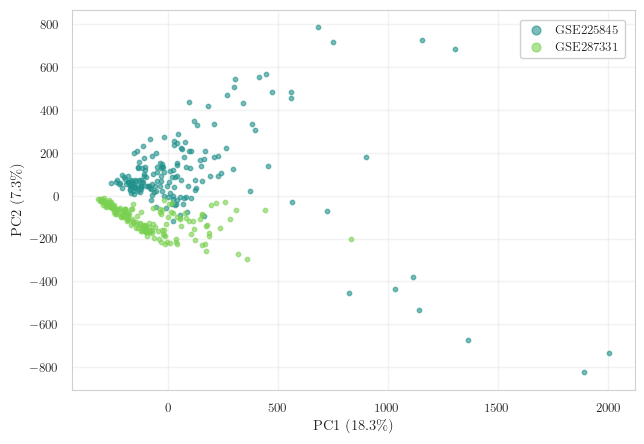

Post-transformation — by label


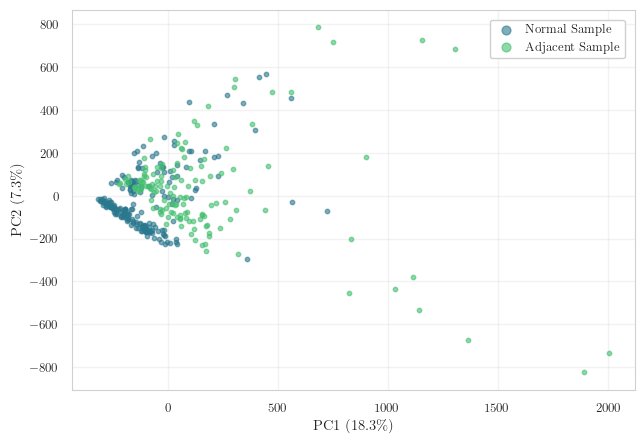

In [16]:
# ============================================================
# CELLA 8 — Post-transformation diagnostics (complementary analysis)
#   PCA on absolute deviation (pre-ComBat)
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# -----------------------------
# PRINT title/subtitle (NOT on plot)
# -----------------------------
print("PCA — Absolute deviation (pre-ComBat)")
print("Post-transformation diagnostics (train pool)")

# -----------------------------
# Thesis style
# -----------------------------
if "apply_thesis_style" in globals():
    apply_thesis_style(use_tex=True)

# pool train for PCA
X_tr_pool = np.vstack([X_train_abs[ds] for ds in ["GSE225845", "GSE287331"]])
ds_labels_tr = (
    ["GSE225845"] * len(X_train_abs["GSE225845"]) +
    ["GSE287331"] * len(X_train_abs["GSE287331"])
)
tissue_labels_tr = np.concatenate([
    meta_train[meta_train["dataset_origin"] == ds][LABEL_COL].values
    for ds in ["GSE225845", "GSE287331"]
])

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(StandardScaler().fit_transform(X_tr_pool))
ev = pca.explained_variance_ratio_


# ============================================================
# FIGURE 1 — colored by dataset
# ============================================================
plt.figure(figsize=(6.5, 4.5))

for ds in ["GSE225845", "GSE287331"]:
    mask = np.array(ds_labels_tr) == ds
    plt.scatter(
        coords[mask, 0], coords[mask, 1],
        c=[DS_PALETTE[ds]],
        s=10, alpha=0.6, label=ds
    )

plt.xlabel(f"PC1 ({ev[0]*100:.1f}\\%)")
plt.ylabel(f"PC2 ({ev[1]*100:.1f}\\%)")
print("Post-transformation — by dataset")
plt.legend(markerscale=2, fontsize=9)

out1 = os.path.join(OUTPUT_DIR, "plot_pca_abs_precombat_by_dataset.pdf")
plt.tight_layout()
plt.savefig(out1, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# ============================================================
# FIGURE 2 — colored by label
# ============================================================
plt.figure(figsize=(6.5, 4.5))

for lab, name in [(0, "Normal Sample"), (1, "Adjacent Sample")]:
    mask = tissue_labels_tr == lab
    plt.scatter(
        coords[mask, 0], coords[mask, 1],
        c=[DS_PALETTE_VIRIDIS[lab]],
        s=10, alpha=0.6, label=name
    )

plt.xlabel(f"PC1 ({ev[0]*100:.1f}\\%)")
plt.ylabel(f"PC2 ({ev[1]*100:.1f}\\%)")
print("Post-transformation — by label")
plt.legend(markerscale=2, fontsize=9)

out2 = os.path.join(OUTPUT_DIR, "plot_pca_abs_precombat_by_label.pdf")
plt.tight_layout()
plt.savefig(out2, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [17]:
# CELLA 9 — ComBat sul pool train + GSE69914
from neuroCombat import neuroCombat, neuroCombatFromTraining
import numpy as np
import pandas as pd
import polars as pl


# ── Intersezione common_cpgs ∩ GSE69914 ──────────────────────
common_cpgs_list = list(common_cpgs)
shared_common    = [c for c in common_cpgs_list ]




# ── Trasformazione assoluta GSE69914 con mean_normal dal train ─
print("\n[3] Absolute deviation GSE69914 (mean_normal dal train)...")
# mean_normal_train è su common_cpgs completo → prendi solo shared_common
col_to_j_common   = {c: j for j, c in enumerate(common_cpgs_list)}
idx_shared        = np.array([col_to_j_common[c] for c in shared_common], dtype=int)
mean_nor_pool_full = (mean_normal_train["GSE225845"][idx_shared] +
                      mean_normal_train["GSE287331"][idx_shared]) / 2.0


# ── Pool train + GSE69914 per ComBat ─────────────────────────
print("\n[4] ComBat su pool train ")
X_tr_pool = np.vstack([
    X_train_abs["GSE225845"],
    X_train_abs["GSE287331"]
])
batch_pool = (
    ["GSE225845"] * len(X_train_abs["GSE225845"]) +
    ["GSE287331"] * len(X_train_abs["GSE287331"]) 
)
label_pool = np.concatenate([tissue_labels_tr]).astype(int)

covars_train = pd.DataFrame({"batch": batch_pool, "label": label_pool})
print(f"    Pool totale: {X_tr_pool.shape}")
print(covars_train["batch"].value_counts())

result = neuroCombat(
    dat=X_tr_pool.T,
    covars=covars_train,
    batch_col="batch",
    categorical_cols=["label"],
    mean_only=False,
)

# separa i tre dataset
n_225 = len(X_train_abs["GSE225845"])
n_287 = len(X_train_abs["GSE287331"])

X_tr_combat      = result["data"].T[:n_225 + n_287]
X_69_combat_full = result["data"].T[n_225 + n_287:]   # (n_69, len(shared_common))
combat_estimates = result["estimates"]

print(f"\nComBat completato.")
print(f"  X_tr_combat      : {X_tr_combat.shape}")
print(f"  X_69_combat_full : {X_69_combat_full.shape}")

# ── Applica ComBat al test set ────────────────────────────────
X_te_pool = np.vstack([X_test_abs[ds] for ds in ["GSE225845", "GSE287331"]])
ds_labels_te = (
    ["GSE225845"] * len(X_test_abs["GSE225845"]) +
    ["GSE287331"] * len(X_test_abs["GSE287331"])
)
X_te_combat = neuroCombatFromTraining(
    dat=X_te_pool.T,
    batch=ds_labels_te,
    estimates=combat_estimates,
)["data"].T
print(f"  X_te_combat      : {X_te_combat.shape}")



[3] Absolute deviation GSE69914 (mean_normal dal train)...

[4] ComBat su pool train 
    Pool totale: (346, 485453)
batch
GSE225845    177
GSE287331    169
Name: count, dtype: int64
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data

ComBat completato.
  X_tr_combat      : (346, 485453)
  X_69_combat_full : (0, 485453)
[neuroCombatFromTraining] In development ...

  X_te_combat      : (149, 485453)


In [18]:
# CELLA 10 — Applica ComBat al test set (neuroCombatFromTraining)
X_te_pool = np.vstack([X_test_abs[ds] for ds in ["GSE225845", "GSE287331"]])
ds_labels_te = (
    ["GSE225845"] * len(X_test_abs["GSE225845"]) +
    ["GSE287331"] * len(X_test_abs["GSE287331"])
)

X_te_combat = neuroCombatFromTraining(
    dat=X_te_pool.T,
    batch=ds_labels_te,
    estimates=combat_estimates,
)["data"].T

print(f"Test set post-ComBat: {X_te_combat.shape}")

X_tum_pool_raw = np.vstack([X_tumor_abs[ds] for ds in ["GSE225845", "GSE287331"]])
ds_labels_tum = (
    ["GSE225845"] * len(X_tumor_abs["GSE225845"]) +
    ["GSE287331"] * len(X_tumor_abs["GSE287331"])
)
X_tum_combat = neuroCombatFromTraining(
    dat=X_tum_pool_raw.T,
    batch=ds_labels_tum,
    estimates=combat_estimates,
)["data"].T

[neuroCombatFromTraining] In development ...

Test set post-ComBat: (149, 485453)
[neuroCombatFromTraining] In development ...



PCA — Pre vs post ComBat (train set)
Post-ComBat diagnostics (complementary analysis)
Pre-ComBat — by dataset


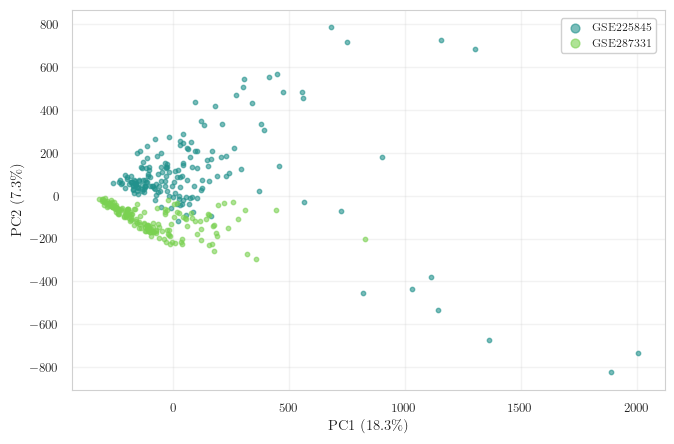

Pre-ComBat — by label


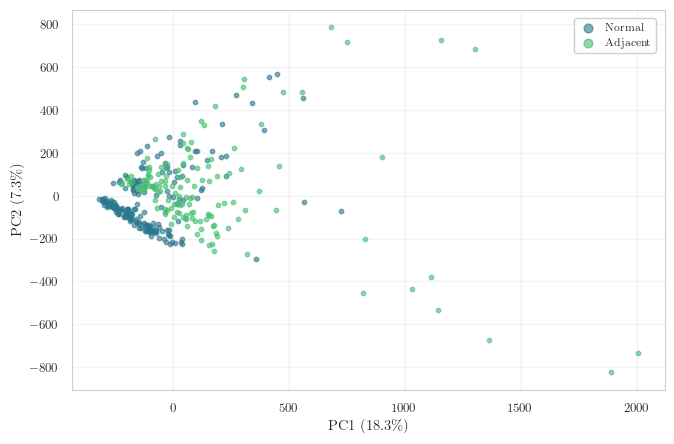

Post-ComBat — by dataset


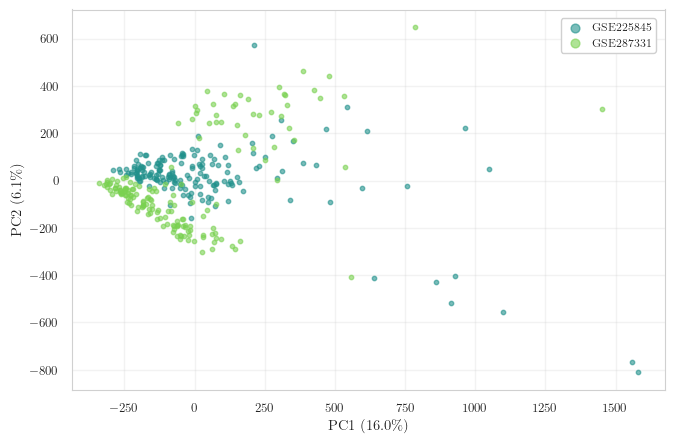

Post-ComBat — by label


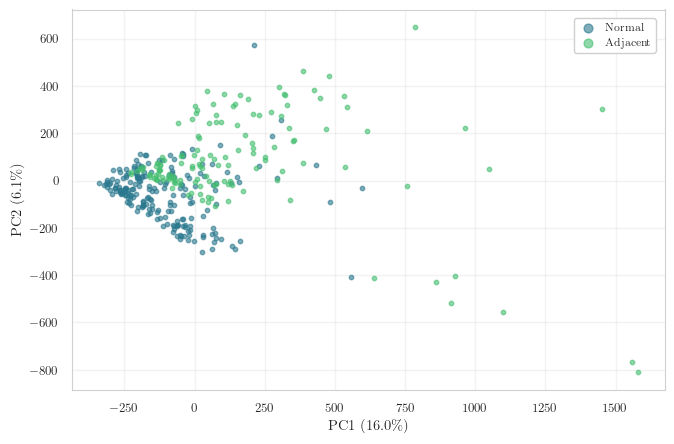


Verify biological signal post-ComBat:
  GSE225845: mean_dev(Adjacent)=0.0389  mean_dev(Normal)=0.0306  OK=True
  GSE287331: mean_dev(Adjacent)=0.0420  mean_dev(Normal)=0.0289  OK=True


In [19]:
# ============================================================
# CELLA 11 — Post-ComBat diagnostics (complementary analysis)
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# -----------------------------
# PRINT title/subtitle (NOT on plot)
# -----------------------------
print("PCA — Pre vs post ComBat (train set)")
print("Post-ComBat diagnostics (complementary analysis)")

# -----------------------------
# Thesis style
# -----------------------------
if "apply_thesis_style" in globals():
    apply_thesis_style(use_tex=True)


tissue_labels_te = np.concatenate([
    meta_test[meta_test["dataset_origin"] == ds][LABEL_COL].values
    for ds in ["GSE225845", "GSE287331"]
])

# -----------------------------
# PCA pre vs post ComBat (4 separate figures)
# -----------------------------
X_tr_pool_2ds = np.vstack([X_train_abs["GSE225845"], X_train_abs["GSE287331"]])
for X_pool, title in [
    (X_tr_pool_2ds, "Pre-ComBat"),
    (X_tr_combat,   "Post-ComBat"),
]:
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(StandardScaler().fit_transform(X_pool))
    ev = pca.explained_variance_ratio_

    # FIG 1/3 — by dataset
    plt.figure(figsize=(6.8, 4.5))
    for ds in ["GSE225845", "GSE287331"]:
        mask = np.array(ds_labels_tr) == ds
        plt.scatter(
            coords[mask, 0], coords[mask, 1],
            c=[DS_PALETTE[ds]],
            s=10, alpha=0.6, label=ds
        )
    print(f"{title} — by dataset")
    plt.xlabel(f"PC1 ({ev[0]*100:.1f}\\%)")
    plt.ylabel(f"PC2 ({ev[1]*100:.1f}\\%)")
    plt.legend(markerscale=2, fontsize=8)
    out_path = os.path.join(
        OUTPUT_DIR,
        f"plot_pca_{'precombat' if title=='Pre-ComBat' else 'postcombat'}_by_dataset.pdf"
    )
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    plt.close()

    # FIG 2/4 — by label
    plt.figure(figsize=(6.8, 4.5))
    for lab, name in [(0, "Normal"), (1, "Adjacent")]:
        mask = tissue_labels_tr == lab
        plt.scatter(
            coords[mask, 0], coords[mask, 1],
            c=[DS_PALETTE_VIRIDIS[lab]],
            s=10, alpha=0.6, label=name
        )
    print(f"{title} — by label")
    plt.xlabel(f"PC1 ({ev[0]*100:.1f}\\%)")
    plt.ylabel(f"PC2 ({ev[1]*100:.1f}\\%)")
    plt.legend(markerscale=2, fontsize=8)
    out_path = os.path.join(
        OUTPUT_DIR,
        f"plot_pca_{'precombat' if title=='Pre-ComBat' else 'postcombat'}_by_label.pdf"
    )
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    plt.close()

# -----------------------------
# Verify biological signal is preserved post-ComBat
# -----------------------------
print("\nVerify biological signal post-ComBat:")
for ds in ["GSE225845", "GSE287331"]:
    mask_ds = np.array(ds_labels_tr) == ds
    labels_ds = tissue_labels_tr[mask_ds]
    X_ds = X_tr_combat[mask_ds]
    mean_adj = X_ds[labels_ds == 1].mean()
    mean_nor = X_ds[labels_ds == 0].mean()
    print(f"  {ds}: mean_dev(Adjacent)={mean_adj:.4f}  mean_dev(Normal)={mean_nor:.4f}  OK={mean_adj > mean_nor}")


In [20]:
# X_tr_pool originale ora ha 438 righe (225845 + 287331 + 69914)
# rinomina e ricrea quella a 2 dataset per compatibilità con le celle successive
X_tr_pool_3ds = X_tr_pool                                                    # 438 righe — per riferimento
X_tr_pool     = np.vstack([X_train_abs["GSE225845"], X_train_abs["GSE287331"]])  # 346 righe — come prima


Variabili analizzate: ['SentrixID', 'ChipPosition', 'age', 'label', 'dataset_origin']

PCA Pre-ComBat...
  Done. Shape res_df: (50, 3)

PCA Post-ComBat...
  Done. Shape res_df: (50, 3)

Pre-ComBat — GSE225845
Saved: /kaggle/working/plot_pc_dominance_Pre-ComBat_—_GSE225845.pdf


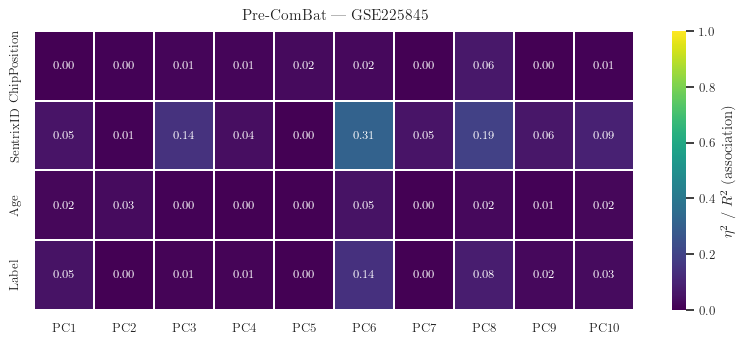


Pre-ComBat — GSE287331
Saved: /kaggle/working/plot_pc_dominance_Pre-ComBat_—_GSE287331.pdf


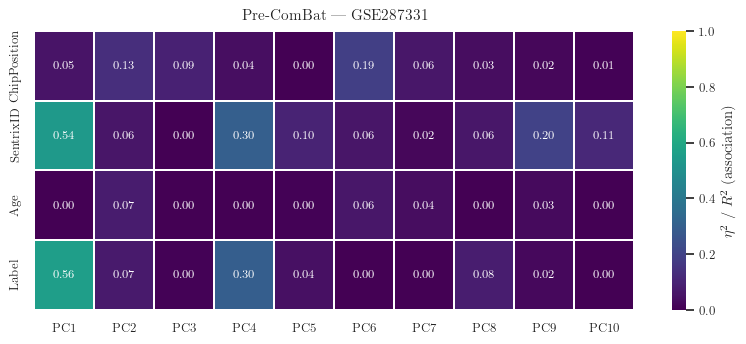


Post-ComBat — GSE225845
Saved: /kaggle/working/plot_pc_dominance_Post-ComBat_—_GSE225845.pdf


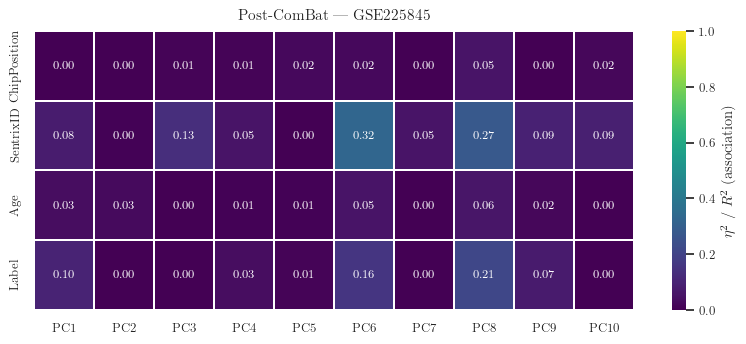


Post-ComBat — GSE287331
Saved: /kaggle/working/plot_pc_dominance_Post-ComBat_—_GSE287331.pdf


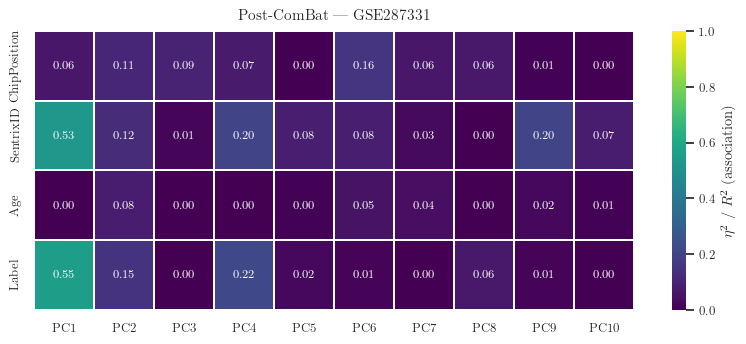


DELTA ASSOCIAZIONE (Post - Pre ComBat)
Valori negativi = riduzione effetto tecnico = ComBat efficace
pc                PC1    PC2    PC3    PC4    PC5
variable_label                                   
Age             0.006 -0.031  0.019 -0.003  0.002
ChipPosition    0.004  0.000 -0.028  0.043  0.001
Dataset        -0.108 -0.482  0.021 -0.035 -0.012
Label          -0.028  0.222  0.003 -0.019  0.003
SentrixID      -0.105  0.026 -0.233  0.063 -0.126

INTERPRETATION:
  Dataset/SentrixID delta < 0 → ComBat ha ridotto l'effetto tecnico ✓
  Label delta ≈ 0            → segnale biologico preservato ✓
  Label delta << 0           → ⚠ ComBat ha rimosso anche segnale biologico


In [21]:
# ============================================================
# PLOT — PC Dominance Analysis PRE vs POST ComBat
# Coerente con notebook 05-4iwbbio-combat-label
#
# Prerequisiti in scope (già disponibili nel notebook):
#   X_tr_pool       : np.ndarray (n_train, n_cpgs) — pre-ComBat
#   X_tr_combat     : np.ndarray (n_train, n_cpgs) — post-ComBat
#   ds_labels_tr    : list of str ["GSE225845"*n, "GSE287331"*m]
#   tissue_labels_tr: np.ndarray (n_train,) — 0=Normal, 1=Adjacent
#   meta_train      : pd.DataFrame con colonne SentrixID, ChipPosition, age
#   OUTPUT_DIR      : str
#   RANDOM_STATE    : int
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr, kruskal

if "apply_thesis_style" in globals():
    apply_thesis_style(use_tex=True)

# ── 1) Costruisci meta allineata al pool train ────────────────────────────────
# ds_labels_tr è costruito con lo stesso loop di X_tr_pool:
#   ["GSE225845"]*n_225 + ["GSE287331"]*n_287
# meta_train è concatenato nello stesso ordine (meta_225 poi meta_287)
# Quindi l'allineamento è garantito dalla costruzione del notebook

meta_pool_tr = pd.concat([
    meta_train[meta_train["dataset_origin"] == ds].reset_index(drop=True)
    for ds in ["GSE225845", "GSE287331"]
], ignore_index=True)


# ── 2) Funzione associazione PC ~ variabile ───────────────────────────────────

def pc_association(pc_scores: np.ndarray, meta: pd.DataFrame, variables: list) -> pd.DataFrame:
    """
    Per ogni PC e ogni variabile calcola l'associazione:
    - variabili categoriche (dtype object o bool): eta^2 da Kruskal-Wallis
      eta^2 = (H - k + 1) / (n - k)  dove H=statistica KW, k=n_gruppi
    - variabili numeriche (float/int): R^2 da Spearman^2
    
    Ritorna DataFrame con colonne: pc, variable, association
    """
    n_pcs = pc_scores.shape[1]
    rows = []

    for var in variables:
        col = meta[var].values

        # determina tipo
        is_cat = (
            pd.api.types.is_object_dtype(col) or
            pd.api.types.is_bool_dtype(col) or
            pd.api.types.is_categorical_dtype(col)
        )

        for pc_idx in range(n_pcs):
            pc_vec = pc_scores[:, pc_idx]
            pc_name = f"PC{pc_idx + 1}"

            # rimuovi NaN
            valid = ~pd.isnull(col)
            pc_v = pc_vec[valid]
            col_v = col[valid]

            if len(pc_v) < 10:
                assoc = np.nan
            elif is_cat:
                # Kruskal-Wallis eta^2
                groups = [pc_v[col_v == g] for g in np.unique(col_v) if (col_v == g).sum() > 1]
                if len(groups) < 2:
                    assoc = np.nan
                else:
                    try:
                        H, _ = kruskal(*groups)
                        k = len(groups)
                        n = len(pc_v)
                        # eta^2 approssimato
                        assoc = float(np.clip((H - k + 1) / (n - k), 0, 1))
                    except Exception:
                        assoc = np.nan
            else:
                # Spearman R^2
                try:
                    col_num = pd.to_numeric(col_v, errors="coerce")
                    ok2 = ~np.isnan(col_num)
                    if ok2.sum() < 10:
                        assoc = np.nan
                    else:
                        rho, _ = spearmanr(pc_v[ok2], col_num[ok2])
                        assoc = float(rho ** 2)
                except Exception:
                    assoc = np.nan

            rows.append({"pc": pc_name, "variable": var, "association": assoc})

    return pd.DataFrame(rows)


# ── 3) Variabili da analizzare ────────────────────────────────────────────────
# Usa solo quelle disponibili in meta_train
VARIABLES = []
for v in ["SentrixID", "ChipPosition", "age", LABEL_COL, "dataset_origin"]:
    if v in meta_pool_tr.columns:
        VARIABLES.append(v)
    else:
        print(f"  ⚠ variabile '{v}' non trovata in meta_train — saltata")

print(f"\nVariabili analizzate: {VARIABLES}")

# rinomina per il plot
VAR_RENAME = {
    "age":            "Age",
    LABEL_COL:        "Label",
    "dataset_origin": "Dataset",
    "SentrixID":      "SentrixID",
    "ChipPosition":   "ChipPosition",
}

# ── 4) Calcola PC scores pre e post ComBat ────────────────────────────────────
N_PCS = 10

results = {}
for name, X in [("Pre-ComBat", X_tr_pool), ("Post-ComBat", X_tr_combat)]:
    print(f"\nPCA {name}...")
    pca = PCA(n_components=N_PCS, random_state=RANDOM_STATE)
    pc_scores = pca.fit_transform(StandardScaler().fit_transform(X))
    res_df = pc_association(pc_scores, meta_pool_tr, VARIABLES)
    results[name] = res_df
    print(f"  Done. Shape res_df: {res_df.shape}")


# ── 5) Funzione plot heatmap ──────────────────────────────────────────────────
def plot_pc_dominance_heatmap(res_df, title, outdir, max_pc=10):
    pivot = res_df.pivot(index="variable", columns="pc", values="association")
    pivot = pivot.rename(index=lambda x: VAR_RENAME.get(str(x), str(x)))

    # ordina PC
    pc_order = [f"PC{i+1}" for i in range(max_pc)]
    pivot = pivot[[c for c in pc_order if c in pivot.columns]]

    if "apply_thesis_style" in globals():
        apply_thesis_style(use_tex=True)

    fig, ax = plt.subplots(figsize=(8.0, max(3.5, len(pivot) * 0.8)))
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="viridis",
        vmin=0, vmax=1,
        annot=True, fmt=".2f",
        linewidths=0.3,
        cbar_kws={"label": r"$\eta^2$ / $R^2$ (association)"},
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(title, fontsize=11, pad=8)

    plt.tight_layout()
    safe_title = title.replace(" ", "_").replace("/", "_")
    out_path = os.path.join(outdir, f"plot_pc_dominance_{safe_title}.pdf")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()
    plt.close(fig)


# ── 6) Plot separati per dataset, pre e post ComBat ──────────────────────────
for condition, res_df in results.items():
    for ds in ["GSE225845", "GSE287331"]:
        # filtra solo i campioni di quel dataset
        mask_ds = meta_pool_tr["dataset_origin"].values == ds
        meta_ds = meta_pool_tr[mask_ds].reset_index(drop=True)

        # ricalcola PCA solo su quel subset
        X_ds = (X_tr_pool if condition == "Pre-ComBat" else X_tr_combat)[mask_ds]
        pca_ds = PCA(n_components=N_PCS, random_state=RANDOM_STATE)
        pc_scores_ds = pca_ds.fit_transform(StandardScaler().fit_transform(X_ds))

        # variabili disponibili per questo dataset
        vars_ds = [v for v in VARIABLES if v in meta_ds.columns and v != "dataset_origin"]
        res_ds = pc_association(pc_scores_ds, meta_ds, vars_ds)

        title = f"{condition} — {ds}"
        print(f"\n{title}")
        plot_pc_dominance_heatmap(res_ds, title, OUTPUT_DIR, max_pc=N_PCS)


# ── 7) Confronto diretto: delta associazione post - pre ──────────────────────
print("\n" + "=" * 60)
print("DELTA ASSOCIAZIONE (Post - Pre ComBat)")
print("Valori negativi = riduzione effetto tecnico = ComBat efficace")
print("=" * 60)

res_pre  = results["Pre-ComBat"]
res_post = results["Post-ComBat"]

merged = res_pre.merge(
    res_post, on=["pc", "variable"], suffixes=("_pre", "_post")
)
merged["delta"] = merged["association_post"] - merged["association_pre"]
merged["variable_label"] = merged["variable"].map(lambda x: VAR_RENAME.get(x, x))

# stampa solo PC1-PC5 per leggibilità
pc_show = [f"PC{i+1}" for i in range(5)]
print(
    merged[merged["pc"].isin(pc_show)]
    .pivot(index="variable_label", columns="pc", values="delta")
    .round(3)
    .to_string()
)

print("\nINTERPRETATION:")
print("  Dataset/SentrixID delta < 0 → ComBat ha ridotto l'effetto tecnico ✓")
print("  Label delta ≈ 0            → segnale biologico preservato ✓")
print("  Label delta << 0           → ⚠ ComBat ha rimosso anche segnale biologico")

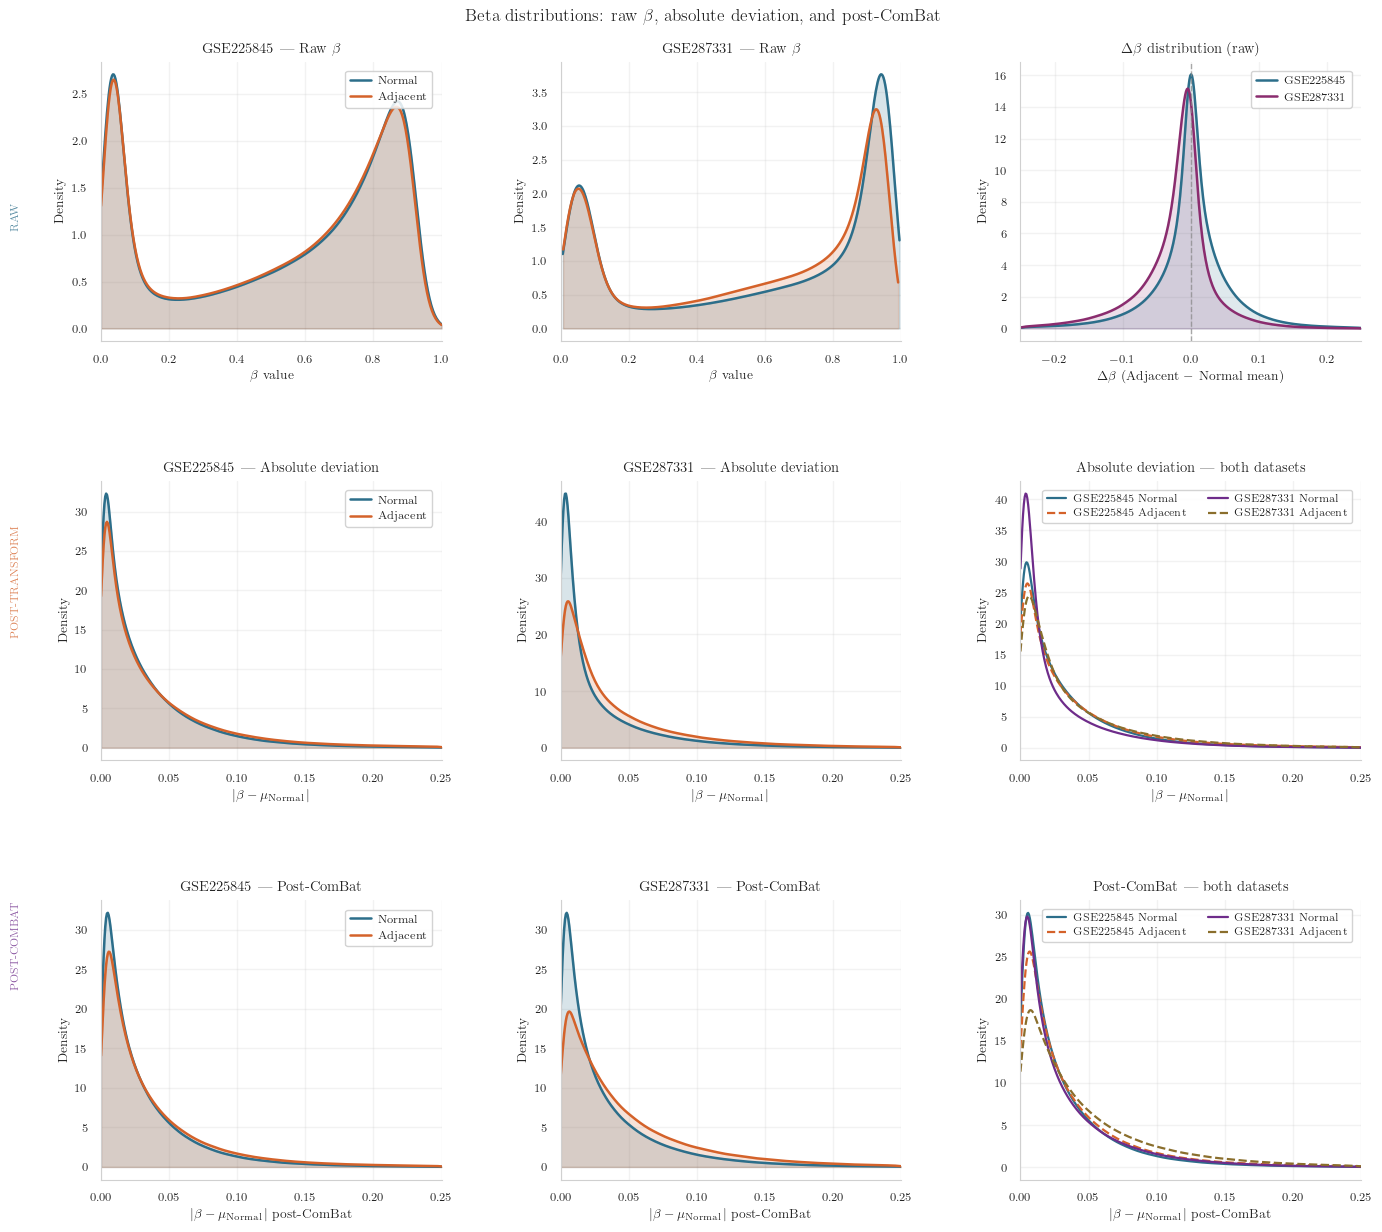

Salvato!


In [22]:
# ============================================================
# PLOT — Beta distributions: raw vs absolute deviation vs post-ComBat
# Prerequisiti in scope:
#   X_train        : dict {ds: np.ndarray (n_samples, n_cpgs)} — beta raw
#   X_train_abs    : dict {ds: np.ndarray (n_samples, n_cpgs)} — |beta - mu_Normal|
#   X_tr_combat    : np.ndarray (n_train, n_cpgs) — post-ComBat pooled
#   meta_train     : pd.DataFrame con colonne dataset_origin, label (0=Normal, 1=Adjacent)
#   ds_labels_tr   : list of str — dataset label per ogni riga di X_tr_combat
#   tissue_labels_tr: np.ndarray — 0=Normal, 1=Adjacent per ogni riga di X_tr_combat
#   LABEL_COL      : str = "label"
#   OUTPUT_DIR     : str
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

apply_thesis_style(use_tex=True)

COLORS = {
    'normal':   '#2C6E8A',
    'adjacent': '#D4622A',
}

LABEL_FS = 9.5
TICK_FS  = 8.5
TITLE_FS = 10.5
SUBSAMPLE = 8

def kde_plot(ax, data_n, data_a, xlabel, title, xlim=None, show_legend=True):
    for data, color, label in [
        (data_n, COLORS['normal'],   'Normal'),
        (data_a, COLORS['adjacent'], 'Adjacent'),
    ]:
        flat = data.ravel()[::SUBSAMPLE]
        if xlim:
            flat = flat[(flat >= xlim[0]) & (flat <= xlim[1])]
        if len(flat) < 20:
            continue
        kde = gaussian_kde(flat, bw_method=0.08)
        xgrid = np.linspace(flat.min(), flat.max(), 400)
        y = kde(xgrid)
        ax.plot(xgrid, y, color=color, lw=1.8, label=label)
        ax.fill_between(xgrid, y, alpha=0.18, color=color)
    ax.set_xlabel(xlabel, fontsize=LABEL_FS)
    ax.set_ylabel('Density', fontsize=LABEL_FS)
    ax.set_title(title, fontsize=TITLE_FS, fontweight='bold', pad=6)
    ax.tick_params(labelsize=TICK_FS)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor('white')
    if xlim:
        ax.set_xlim(xlim)
    if show_legend:
        ax.legend(fontsize=8.5, framealpha=0.85, edgecolor='#CCCCCC')

# ── Prepara dati pre-trasformazione e post-trasformazione ─────────────────────
data = {}
for ds in ['GSE225845', 'GSE287331']:
    labels = meta_train[meta_train['dataset_origin'] == ds][LABEL_COL].values
    data[ds] = {
        'raw_n':   X_train[ds][labels == 0],
        'raw_a':   X_train[ds][labels == 1],
        'abs_n':   X_train_abs[ds][labels == 0],
        'abs_a':   X_train_abs[ds][labels == 1],
        'mu_norm': X_train[ds][labels == 0].mean(axis=0),
    }

# ── Prepara dati post-ComBat ──────────────────────────────────────────────────
ds_labels_arr      = np.array(ds_labels_tr)
tissue_labels_arr  = np.array(tissue_labels_tr)
combat_data = {}
for ds in ['GSE225845', 'GSE287331']:
    mask_ds = ds_labels_arr == ds
    combat_data[ds] = {
        'combat_n': X_tr_combat[mask_ds & (tissue_labels_arr == 0)],
        'combat_a': X_tr_combat[mask_ds & (tissue_labels_arr == 1)],
    }

# ── Figure 3 righe × 3 colonne ───────────────────────────────────────────────
fig = plt.figure(figsize=(14, 13))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(3, 3, figure=fig,
                       hspace=0.50, wspace=0.35,
                       left=0.07, right=0.97, top=0.92, bottom=0.06)

# ── ROW 0: raw beta ───────────────────────────────────────────────────────────
ax00 = fig.add_subplot(gs[0, 0])
kde_plot(ax00, data['GSE225845']['raw_n'], data['GSE225845']['raw_a'],
         xlabel=r'$\beta$ value', title='GSE225845 — Raw $\\beta$',
         xlim=(0, 1), show_legend=True)

ax01 = fig.add_subplot(gs[0, 1])
kde_plot(ax01, data['GSE287331']['raw_n'], data['GSE287331']['raw_a'],
         xlabel=r'$\beta$ value', title='GSE287331 — Raw $\\beta$',
         xlim=(0, 1), show_legend=False)

ax02 = fig.add_subplot(gs[0, 2])
DS_COLORS_DELTA = {'GSE225845': '#2C6E8A', 'GSE287331': '#8A2C6E'}
for ds, color in DS_COLORS_DELTA.items():
    delta = (data[ds]['raw_a'] - data[ds]['mu_norm']).ravel()[::SUBSAMPLE]
    delta = delta[(delta >= -0.25) & (delta <= 0.25)]
    kde = gaussian_kde(delta, bw_method=0.12)
    xg = np.linspace(-0.25, 0.25, 400)
    y = kde(xg)
    ax02.plot(xg, y, color=color, lw=1.8, label=ds)
    ax02.fill_between(xg, y, alpha=0.15, color=color)
ax02.axvline(0, color='#888888', lw=1.0, ls='--', alpha=0.7)
ax02.set_xlabel(r'$\Delta\beta$ (Adjacent $-$ Normal mean)', fontsize=LABEL_FS)
ax02.set_ylabel('Density', fontsize=LABEL_FS)
ax02.set_title(r'$\Delta\beta$ distribution (raw)', fontsize=TITLE_FS, fontweight='bold', pad=6)
ax02.tick_params(labelsize=TICK_FS)
ax02.spines[['top', 'right']].set_visible(False)
ax02.set_facecolor('white')
ax02.legend(fontsize=8.5, framealpha=0.85, edgecolor='#CCCCCC')
ax02.set_xlim(-0.25, 0.25)

# ── ROW 1: absolute deviation (pre-ComBat) ────────────────────────────────────
ax10 = fig.add_subplot(gs[1, 0])
kde_plot(ax10, data['GSE225845']['abs_n'], data['GSE225845']['abs_a'],
         xlabel=r'$|\beta - \mu_{\mathrm{Normal}}|$',
         title='GSE225845 — Absolute deviation',
         xlim=(0, 0.25), show_legend=True)

ax11 = fig.add_subplot(gs[1, 1])
kde_plot(ax11, data['GSE287331']['abs_n'], data['GSE287331']['abs_a'],
         xlabel=r'$|\beta - \mu_{\mathrm{Normal}}|$',
         title='GSE287331 — Absolute deviation',
         xlim=(0, 0.25), show_legend=False)

ax12 = fig.add_subplot(gs[1, 2])
DS_PAIRS = {
    'GSE225845': ('#2C6E8A', '#D4622A'),
    'GSE287331': ('#6E2C8A', '#8A6E2C'),
}
for ds, (color_n, color_a) in DS_PAIRS.items():
    for arr, color, ls, lbl in [
        (data[ds]['abs_n'], color_n, '-',  f'{ds} Normal'),
        (data[ds]['abs_a'], color_a, '--', f'{ds} Adjacent'),
    ]:
        flat = arr.ravel()[::SUBSAMPLE]
        flat = flat[(flat >= 0) & (flat <= 0.25)]
        if len(flat) < 20:
            continue
        kde = gaussian_kde(flat, bw_method=0.10)
        xg = np.linspace(0, 0.25, 400)
        y = kde(xg)
        ax12.plot(xg, y, color=color, lw=1.6, ls=ls, label=lbl)
ax12.set_xlabel(r'$|\beta - \mu_{\mathrm{Normal}}|$', fontsize=LABEL_FS)
ax12.set_ylabel('Density', fontsize=LABEL_FS)
ax12.set_title('Absolute deviation — both datasets', fontsize=TITLE_FS, fontweight='bold', pad=6)
ax12.tick_params(labelsize=TICK_FS)
ax12.spines[['top', 'right']].set_visible(False)
ax12.set_facecolor('white')
ax12.legend(fontsize=7.8, framealpha=0.85, edgecolor='#CCCCCC', ncol=2)
ax12.set_xlim(0, 0.25)

# ── ROW 2: post-ComBat ────────────────────────────────────────────────────────
ax20 = fig.add_subplot(gs[2, 0])
kde_plot(ax20, combat_data['GSE225845']['combat_n'], combat_data['GSE225845']['combat_a'],
         xlabel=r'$|\beta - \mu_{\mathrm{Normal}}|$ post-ComBat',
         title='GSE225845 — Post-ComBat',
         xlim=(0, 0.25), show_legend=True)

ax21 = fig.add_subplot(gs[2, 1])
kde_plot(ax21, combat_data['GSE287331']['combat_n'], combat_data['GSE287331']['combat_a'],
         xlabel=r'$|\beta - \mu_{\mathrm{Normal}}|$ post-ComBat',
         title='GSE287331 — Post-ComBat',
         xlim=(0, 0.25), show_legend=False)

ax22 = fig.add_subplot(gs[2, 2])
for ds, (color_n, color_a) in DS_PAIRS.items():
    for arr, color, ls, lbl in [
        (combat_data[ds]['combat_n'], color_n, '-',  f'{ds} Normal'),
        (combat_data[ds]['combat_a'], color_a, '--', f'{ds} Adjacent'),
    ]:
        flat = arr.ravel()[::SUBSAMPLE]
        flat = flat[(flat >= 0) & (flat <= 0.25)]
        if len(flat) < 20:
            continue
        kde = gaussian_kde(flat, bw_method=0.10)
        xg = np.linspace(0, 0.25, 400)
        y = kde(xg)
        ax22.plot(xg, y, color=color, lw=1.6, ls=ls, label=lbl)
ax22.set_xlabel(r'$|\beta - \mu_{\mathrm{Normal}}|$ post-ComBat', fontsize=LABEL_FS)
ax22.set_ylabel('Density', fontsize=LABEL_FS)
ax22.set_title('Post-ComBat — both datasets', fontsize=TITLE_FS, fontweight='bold', pad=6)
ax22.tick_params(labelsize=TICK_FS)
ax22.spines[['top', 'right']].set_visible(False)
ax22.set_facecolor('white')
ax22.legend(fontsize=7.8, framealpha=0.85, edgecolor='#CCCCCC', ncol=2)
ax22.set_xlim(0, 0.25)

# ── Titolo e etichette di riga ────────────────────────────────────────────────
fig.suptitle(
    r'Beta distributions: raw $\beta$, absolute deviation, and post-ComBat',
    fontsize=12.5, fontweight='bold', y=0.96
)
for y_pos, label, color in [
    (0.80, 'RAW', '#2C6E8A'),
    (0.52, 'POST-TRANSFORM', '#D4622A'),
    (0.24, 'POST-COMBAT', '#6E2C8A'),
]:
    fig.text(0.005, y_pos, label,
             fontsize=8, fontweight='bold', color=color,
             rotation=90, va='center', alpha=0.75)

plt.savefig(f'{OUTPUT_DIR}beta_transformation_plot.pdf',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Salvato!")

In [23]:
# ── CELLA 12 — STEP 5: Feature Selection (Edgar β) ────────────────────────────
# Input disponibili dal pipeline:
#   X_tr_combat       (n_train, n_cpgs)  numpy float32
#   X_te_combat       (n_test,  n_cpgs)  numpy float32
#   tissue_labels_tr  (n_train,)         numpy int
#   tissue_labels_te  (n_test,)          numpy int
#   common_cpgs       lista nomi CpG     len = n_cpgs
# ──────────────────────────────────────────────────────────────────────────────

R_BETA_CUTOFF = 0.05
LABELS_USE    = [0, 1]

def compute_r_beta_edgar(X: np.ndarray, labels: np.ndarray, cutoff: float):
    """
    Edgar-like variability: r_beta = Q90 - Q10
    calcolato sul train set (già passato come X).
    """
    q90 = np.quantile(X, 0.90, axis=0)
    q10 = np.quantile(X, 0.10, axis=0)
    r_beta = q90 - q10
    mask_keep = r_beta >= cutoff
    return r_beta, mask_keep

print("=" * 90)
print(f"Edgar(β) train-only  cutoff r_beta >= {R_BETA_CUTOFF}")
print("=" * 90)

r_beta, mask_edgar = compute_r_beta_edgar(X_tr_combat, tissue_labels_tr, R_BETA_CUTOFF)

cpg_cols_edgar   = [common_cpgs[i] for i in range(len(common_cpgs)) if mask_edgar[i]]
selected_cpg_indices = np.where(mask_edgar)[0]
selected_cpgs        = cpg_cols_edgar

print(f"CpGs prima di Edgar : {len(common_cpgs):,}")
print(f"CpGs dopo Edgar     : {len(selected_cpgs):,}  (rimossi {len(common_cpgs) - len(selected_cpgs):,})")

# applica ai numpy array — nessun leakage, mask calcolata solo su train
B_train = X_tr_combat[:, selected_cpg_indices].astype(np.float32)
B_test  = X_te_combat[:, selected_cpg_indices].astype(np.float32)
y_train = tissue_labels_tr
y_test  = tissue_labels_te

print(f"B_train: {B_train.shape}")
print(f"B_test : {B_test.shape}")

# salva lista CpG selezionati
with open(os.path.join(OUTPUT_DIR, "cpgs_edgar_selected.txt"), "w") as f:
    f.write("\n".join(selected_cpgs))
print("Done.")

Edgar(β) train-only  cutoff r_beta >= 0.05
CpGs prima di Edgar : 485,453
CpGs dopo Edgar     : 284,310  (rimossi 201,143)
B_train: (346, 284310)
B_test : (149, 284310)
Done.



Edgar(β) variability on TRAIN — Q90−Q10 distribution with 3 cutoffs

Saved plot to: /kaggle/working/edgar_variability_train.pdf


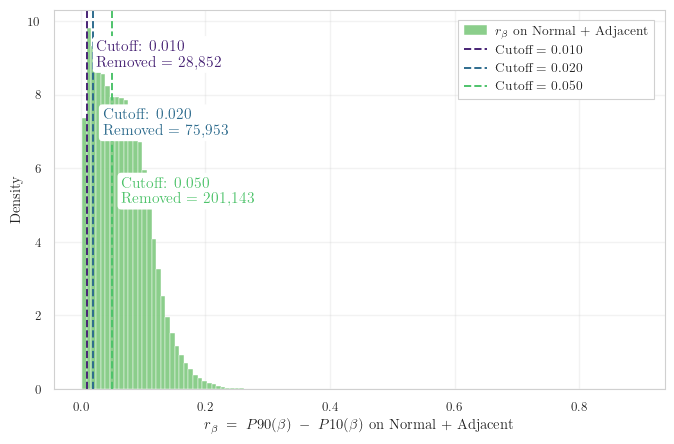

In [24]:
# -----------------------------
# PLOT — Edgar(β) variability (train-only) — white background only (no border)
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nEdgar(β) variability on TRAIN — Q90−Q10 distribution with 3 cutoffs\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

r_beta_plot = np.asarray(r_beta, dtype=float)

cutoffs = [0.010, 0.020, 0.050]

HIST_COLOR = "#7FC97F"

LINE_COLORS = {
    0.010: plt.cm.viridis(0.10),
    0.020: plt.cm.viridis(0.35),
    0.050: plt.cm.viridis(0.72),
}

HIST_LABEL = r"$r_\beta$ on Normal + Adjacent"
XLABEL = r"$r_\beta \;=\; P90(\beta)\;-\;P10(\beta)$ on Normal + Adjacent"

fig, ax = plt.subplots()

ax.hist(
    r_beta_plot,
    bins=120,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label=HIST_LABEL,
    zorder=1,
)

ymax = ax.get_ylim()[1]
X_SHIFT = 0.015

for i, c in enumerate(cutoffs):
    col = LINE_COLORS[c]

    ax.axvline(
        c,
        linestyle="--",
        linewidth=1.4,
        color=col,
        label=rf"Cutoff = {c:0.3f}",
        zorder=2,
    )

    removed = int((r_beta_plot < c).sum())

    ax.text(
        c + X_SHIFT,
        ymax * (0.92 - 0.18 * i),
        f"Cutoff: {c:0.3f}\nRemoved = {removed:,}",
        color=col,
        fontsize=11.0,
        fontweight="semibold",
        ha="left",
        va="top",
        zorder=5,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            linewidth=0,
            alpha=1.0,
        ),
    )

ax.set_xlabel(XLABEL)
ax.set_ylabel("Density")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
pdf_path = Path(OUTPUT_DIR) / "edgar_variability_train.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()


STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only
After M-transform: M_train=(346, 284310) | M_test=(149, 284310)
BLOCK B — Variance filter cutoff diagnostics
SD(M): min=0.1793  max=9.0657  median=3.4281

  → Cutoff DATA-DRIVEN (prima valle): SD=1.7344
    Equivale a drop_frac=5.015%
    Rimosse: 14,258  |  Tenute: 270,052  (95.0%)

  Confronto con frazioni manuali:
    drop_frac=1.00%  SD_thr=1.4693  rimosse=2,844  tenute=281,466
    drop_frac=2.00%  SD_thr=1.5348  rimosse=5,687  tenute=278,623 ← originale
    drop_frac=5.00%  SD_thr=1.7334  rimosse=14,216  tenute=270,094
    drop_frac=10.00%  SD_thr=2.0509  rimosse=28,431  tenute=255,879

  DECISIONE: scegli il valore da usare in VAR_DROP_FRAC nella cella STEP 2


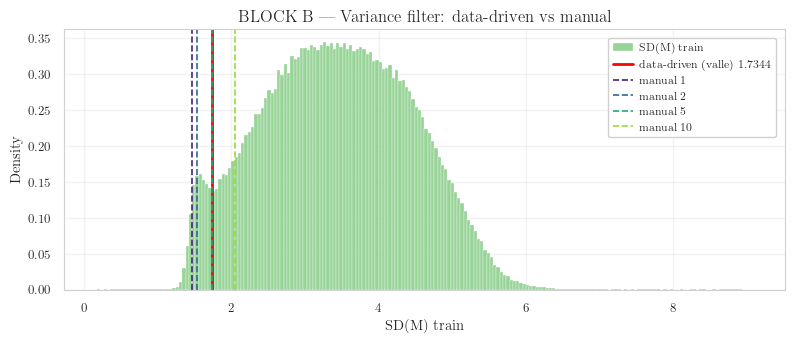


>>> Valore suggerito per VAR_DROP_FRAC: 0.05014948471738595
>>> Confrontalo con il tuo 0.02 e scegli tu.


In [25]:
# -----------------------------
# STEP 2 — M-transform + variance filter (train-only)
#   - beta -> M (post-Edgar)
#   - drop lowest-variance 2% in TRAIN only (optional/off if Edgar is aggressive)
# -----------------------------

# CONFIG (add/override)
EPS_M = 1e-6
VAR_DROP_FRAC = 0.05          # drop lowest 2% by variance/SD
APPLY_VAR_FILTER = True       # set False if Edgar already aggressive

def beta_to_m(beta_arr: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    b = np.clip(beta_arr, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def soft_sd_filter(X, cols, drop_frac):
    sd = X.std(axis=0, ddof=1)
    thr = np.quantile(sd, drop_frac)
    keep = sd >= thr
    return X[:, keep], cols[keep], sd[keep], keep

print("\n" + "=" * 90)
print("STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only")
print("=" * 90)

# (assumes from STEP 1 you have: B_train, B_test, beta_tr, beta_te, cpg_cols_edgar)
cols_full = np.array(cpg_cols_edgar, dtype=object)

# β → M
M_train = beta_to_m(B_train, eps=EPS_M).astype(np.float32)
M_test  = beta_to_m(B_test,  eps=EPS_M).astype(np.float32)
print(f"After M-transform: M_train={M_train.shape} | M_test={M_test.shape}")

# ╔══════════════════════════════════════════════════════════╗
# ║  BLOCK B — Variance filter cutoff automatico            ║
# ║  DOVE: metti questa cella DOPO beta->M (inizio STEP 2)  ║
# ║  ma PRIMA del filtro soft_sd_filter                     ║
# ╚══════════════════════════════════════════════════════════╝

def diagnose_var_cutoff(M_train, candidate_fracs=[0.01, 0.02, 0.05, 0.10]):
    """
    Mostra il cutoff variance data-driven (prima valle della distribuzione SD)
    e quante CpG vengono rimosse per ogni frazione candidata.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.signal import find_peaks

    sd = M_train.std(axis=0, ddof=1)

    # cerca prima valle
    hist_vals, bin_edges = np.histogram(sd, bins=300)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    valleys, props = find_peaks(-hist_vals, prominence=hist_vals.max() * 0.05)

    if len(valleys) > 0:
        valley_sd = float(bin_centers[valleys[0]])
        frac_at_valley = float((sd < valley_sd).mean())
    else:
        valley_sd = None
        frac_at_valley = None

    print("=" * 60)
    print("BLOCK B — Variance filter cutoff diagnostics")
    print("=" * 60)
    print(f"SD(M): min={sd.min():.4f}  max={sd.max():.4f}  median={np.median(sd):.4f}")
    print()

    if valley_sd is not None:
        n_rem = int((sd < valley_sd).sum())
        n_keep = int((sd >= valley_sd).sum())
        print(f"  → Cutoff DATA-DRIVEN (prima valle): SD={valley_sd:.4f}")
        print(f"    Equivale a drop_frac={frac_at_valley:.3%}")
        print(f"    Rimosse: {n_rem:,}  |  Tenute: {n_keep:,}  ({100*n_keep/sd.size:.1f}%)")
    else:
        print("  → Nessuna valle trovata — distribuzione unimodale")
        print("    Suggerimento: usa drop_frac=0.02 (originale)")
    print()
    print("  Confronto con frazioni manuali:")
    for f in candidate_fracs:
        thr = float(np.quantile(sd, f))
        n_rem = int((sd < thr).sum())
        n_keep = sd.size - n_rem
        marker = " ← originale" if f == 0.02 else ""
        print(f"    drop_frac={f:.2%}  SD_thr={thr:.4f}  "
              f"rimosse={n_rem:,}  tenute={n_keep:,}{marker}")
    print()
    print("  DECISIONE: scegli il valore da usare in VAR_DROP_FRAC nella cella STEP 2")
    print("=" * 60)

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(sd, bins=200, density=True, alpha=0.8, color="#7FC97F",
            edgecolor="white", linewidth=0.3, label="SD(M) train")
    if valley_sd is not None:
        ax.axvline(valley_sd, linestyle="-", linewidth=2.0,
                   color="red", label=f"data-driven (valle) {valley_sd:.4f}")
    colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(candidate_fracs)))
    for f, col in zip(candidate_fracs, colors):
        thr = float(np.quantile(sd, f))
        ax.axvline(thr, linestyle="--", linewidth=1.2, color=col,
                   label=f"manual {f:.0%} → {thr:.4f}")
    ax.set_xlabel("SD(M) train")
    ax.set_ylabel("Density")
    ax.set_title("BLOCK B — Variance filter: data-driven vs manual")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    return frac_at_valley

# RUNNA così (dopo beta->M, prima del filtro):
var_frac_suggested = diagnose_var_cutoff(M_train)
print(f"\n>>> Valore suggerito per VAR_DROP_FRAC: {var_frac_suggested}")
print(">>> Confrontalo con il tuo 0.02 e scegli tu.")


In [26]:
# -----------------------------
# STEP 2 — M-transform + variance filter (train-only)
#   - beta -> M (post-Edgar)
#   - drop lowest-variance 2% in TRAIN only (optional/off if Edgar is aggressive)
# -----------------------------

# CONFIG (add/override)
EPS_M = 1e-6
VAR_DROP_FRAC = 0.05         # drop lowest 5% by variance/SD
APPLY_VAR_FILTER = True       # set False if Edgar already aggressive


def beta_to_m(beta_arr: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    b = np.clip(beta_arr, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def soft_sd_filter(X, cols, drop_frac):
    sd = X.std(axis=0, ddof=1)
    thr = np.quantile(sd, drop_frac)
    keep_mask = sd >= thr
    return X[:, keep_mask], cols[keep_mask], sd[keep_mask], keep_mask

print("\n" + "=" * 90)
print("STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only")
print("=" * 90)

# (assumes from STEP 5 you have: B_train, B_test, selected_cpgs)
cpg_cols_edgar = np.array(selected_cpgs, dtype=object)

# β → M
M_train = beta_to_m(B_train, eps=EPS_M).astype(np.float32)
M_test  = beta_to_m(B_test,  eps=EPS_M).astype(np.float32)
print(f"After M-transform: M_train={M_train.shape} | M_test={M_test.shape}")

# Variance/SD filter (train-only), optional
if APPLY_VAR_FILTER and (VAR_DROP_FRAC > 0):
    M_train_f, cpg_cols_f, sd_f, keep_mask = soft_sd_filter(M_train, cpg_cols_edgar, drop_frac=VAR_DROP_FRAC)
    M_test_f = M_test[:, keep_mask]

    print(f"Variance filter: drop_frac={VAR_DROP_FRAC:.2%}")
    print(f"CpGs before: {M_train.shape[1]:,} | after: {M_train_f.shape[1]:,}  (dropped {M_train.shape[1]-M_train_f.shape[1]:,})")

    # overwrite "current" matrices/cols for next steps
    M_train, M_test, cpg_cols_edgar = M_train_f, M_test_f, cpg_cols_f
else:
    print("Variance filter OFF (no CpGs removed).")

# keep aligned beta matrices too (needed later for |Δβ| gates)
# B_train/B_test remain post-Edgar; apply same keep_mask if variance filter ON
if APPLY_VAR_FILTER and (VAR_DROP_FRAC > 0):
    B_train = B_train[:, keep_mask]
    B_test  = B_test[:, keep_mask]
    cpg_cols_current = cpg_cols_edgar.copy()
else:
    cpg_cols_current = cpg_cols_edgar.copy()

print(f"Current aligned: B_train={B_train.shape} | M_train={M_train.shape} | CpGs={len(cpg_cols_current):,}")


STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only
After M-transform: M_train=(346, 284310) | M_test=(149, 284310)
Variance filter: drop_frac=5.00%
CpGs before: 284,310 | after: 270,094  (dropped 14,216)
Current aligned: B_train=(346, 270094) | M_train=(346, 270094) | CpGs=270,094



STEP 2 — SD(M) distribution on TRAIN with variance cutoff (train-only): 2%

Saved plot to: /kaggle/working/sdM_variance_filter_train.pdf


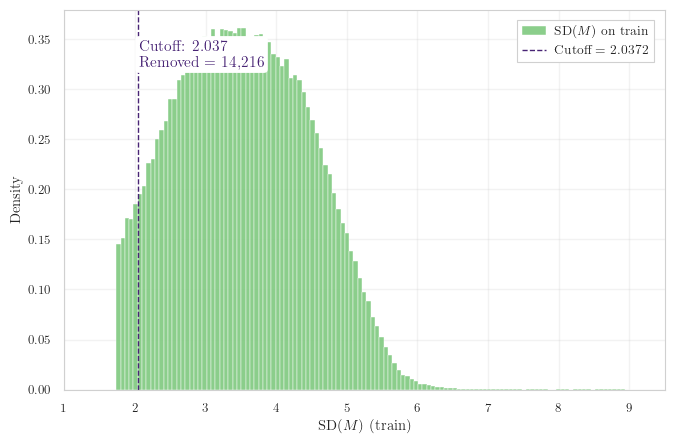

Kept = 255,878 / 270,094 CpGs (Removed = 14,216)


In [27]:
# =============================
# STEP 2 — PLOT: SD(M) distribution + 2% cutoff (train-only)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nSTEP 2 — SD(M) distribution on TRAIN with variance cutoff (train-only): 2%\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

# Recompute pre-filter SD (identical to STEP 2 input)
M_train_pre = beta_to_m(B_train, eps=EPS_M).astype(np.float32)

sd_pre = M_train_pre.std(axis=0, ddof=1)
thr = float(np.quantile(sd_pre, VAR_DROP_FRAC))

total = int(sd_pre.size)

# keep_mask exists only if variance filter was applied
if APPLY_VAR_FILTER and (VAR_DROP_FRAC > 0):
    removed = int((~keep_mask).sum())
else:
    removed = 0

kept = total - removed

fig, ax = plt.subplots()
ax.set_xlim(1, 9.5)

# Histogram (same green as Edgar)
HIST_COLOR = "#7FC97F"
ax.hist(
    sd_pre,
    bins=120,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label=r"$\mathrm{SD}(M)$ on train",
    zorder=1,
)

# Cutoff line
cut_color = plt.cm.viridis(0.10)
ax.axvline(
    thr,
    linestyle="--",
    linewidth=1.0,
    color=cut_color,
    label=rf"Cutoff = {thr:.4f}",
    zorder=2,
)

ax.set_xlabel(r"$\mathrm{SD}(M)$ (train)")
ax.set_ylabel("Density")

# Annotation
X_SHIFT = 0.02
ymax = ax.get_ylim()[1]

ax.text(
    thr + X_SHIFT,
    ymax * 0.92,
    f"Cutoff: {thr:.3f}\nRemoved = {removed:,}",
    color=cut_color,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
pdf_path = Path(OUTPUT_DIR) / "sdM_variance_filter_train.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

print(f"Kept = {kept:,} / {total:,} CpGs (Removed = {removed:,})")

In [28]:
# ============================================================
# STEP 2.5 — Bio-weight (DA METTERE TRA STEP2 e STEP3)
# ============================================================

import pandas as pd
import numpy as np

MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"

def load_manifest_bio(path: str) -> pd.DataFrame:
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Header manifest non trovato (colonna IlmnID).")

    df = pd.read_csv(
        path,
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
        usecols=["IlmnID", "Relation_to_UCSC_CpG_Island", "UCSC_RefGene_Group"],
    )
    df.columns = [c.strip() for c in df.columns]
    df["IlmnID"] = df["IlmnID"].astype(str).str.strip()
    return df

manifest_bio = load_manifest_bio(MANIFEST_PATH)

island_cpgs = set(manifest_bio.loc[manifest_bio["Relation_to_UCSC_CpG_Island"] == "Island", "IlmnID"])
promoter_cpgs = set(
    manifest_bio.loc[
        manifest_bio["UCSC_RefGene_Group"].fillna("").astype(str).str.contains("TSS", na=False),
        "IlmnID"
    ]
)

cpg_cols_current_arr = np.array(cpg_cols_current, dtype=object)

bio_weight = np.array([
    1.00 if (c in island_cpgs and c in promoter_cpgs) else
    0.70 if (c in island_cpgs) else
    0.50 if (c in promoter_cpgs) else
    0.20
    for c in cpg_cols_current_arr
], dtype=np.float32)

# normalizza in [0,1]
bio_weight_norm = (bio_weight - bio_weight.min()) / (bio_weight.max() - bio_weight.min())

# diagnostica
n_top    = int((bio_weight == 1.00).sum())
n_island = int((bio_weight == 0.70).sum())
n_prom   = int((bio_weight == 0.50).sum())
n_other  = int((bio_weight == 0.20).sum())

print(f"[BIO] CpG in isola CpG    : {len(island_cpgs):,}")
print(f"[BIO] CpG in promotore TSS: {len(promoter_cpgs):,}")
print(f"[BIO] Entrambi            : {len(island_cpgs & promoter_cpgs):,}")
print(f"\n[BIO] Distribuzione peso biologico su {len(cpg_cols_current_arr):,} CpG (post STEP2):")
print(f"  isola+TSS (1.00): {n_top:,}   ({100*n_top/len(cpg_cols_current_arr):.1f}%)")
print(f"  isola     (0.70): {n_island:,}   ({100*n_island/len(cpg_cols_current_arr):.1f}%)")
print(f"  promotore (0.50): {n_prom:,}   ({100*n_prom/len(cpg_cols_current_arr):.1f}%)")
print(f"  altro     (0.20): {n_other:,}   ({100*n_other/len(cpg_cols_current_arr):.1f}%)")

[BIO] CpG in isola CpG    : 161,441
[BIO] CpG in promotore TSS: 196,657
[BIO] Entrambi            : 73,261

[BIO] Distribuzione peso biologico su 270,094 CpG (post STEP2):
  isola+TSS (1.00): 6,267   (2.3%)
  isola     (0.70): 17,542   (6.5%)
  promotore (0.50): 37,028   (13.7%)
  altro     (0.20): 209,257   (77.5%)


In [29]:
# ── Allinea X_tum_combat alle stesse CpG di M_train ──────────────────────────
# M_train è post-Edgar post-variance-filter → cpg_cols_current
# X_tum_combat è post-ComBat ma ha ancora tutte le CpG pre-filter

# 1) mappa CpG → indice in X_tum_combat
#    le colonne di X_tum_combat corrispondono a common_cpgs (post-intersezione, pre-Edgar)
tum_cpg_cols = np.array(common_cpgs, dtype=object)  # colonne di X_tum_combat
tum_col_map  = {c: j for j, c in enumerate(tum_cpg_cols)}

# 2) trova indici delle cpg_cols_current in X_tum_combat
cpg_cols_current_arr = np.array(cpg_cols_current, dtype=object)
idx_tum = np.array(
    [tum_col_map[c] for c in cpg_cols_current_arr if c in tum_col_map],
    dtype=int
)
found    = [c for c in cpg_cols_current_arr if c in tum_col_map]
missing  = [c for c in cpg_cols_current_arr if c not in tum_col_map]

if missing:
    print(f"⚠ {len(missing)} CpG di cpg_cols_current non trovate in X_tum_combat — escluse")

# 3) filtra e converti in M-space
X_tum_filtered = X_tum_combat[:, idx_tum].astype(np.float32)
X_tum_M        = beta_to_m(X_tum_filtered, eps=EPS_M)

print(f"X_tum_M shape: {X_tum_M.shape}  (atteso: n_tumor x {len(cpg_cols_current_arr)})")

# rinomina per Step 3
X_tum_combat = X_tum_M

X_tum_M shape: (293, 270094)  (atteso: n_tumor x 270094)


In [30]:
# -----------------------------
# STEP 3 — Repeated Stratified K-Fold stability ranking (train-only)
#   + IP score calcolato dentro il loop RSKF (più stabile)
#   + cutoff |ΔM| data-driven (elbow cord distance)
#   + Mann-Whitney GPU (CuPy) — identico a method='asymptotic'
# -----------------------------

X_tumor_combat = X_tum_combat

import cupy as cp
from scipy.special import ndtr
from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import mannwhitneyu

print("\n" + "=" * 90)
print("STEP 3 — RSKF (K=5, R=10) + IP score dentro loop + cutoff |ΔM| data-driven [GPU]")
print("=" * 90)

# ── Verifica GPU ──────────────────────────────────────────────────────────────
try:
    cp.cuda.Device(0).use()
    print(f"GPU disponibile: {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
except Exception as e:
    raise RuntimeError(f"GPU non disponibile: {e}")

# ── CONFIG ────────────────────────────────────────────────────────────────────
K_FOLDS               = 5
R_REPEATS             = 10
STABILITY_SIGN_MIN    = 0.75
PREFILTER_TOP_DM      = 50000    # tutte le CpG
PRINT_EVERY           = 1
MIN_CANDIDATES_TARGET = 5000
CHUNK_SIZE            = 10000   # colonne per chunk GPU (evita OOM)

W_BIO   = 0.50
W_IP    = 0.50
EPS_IP  = 1e-4

# ── INPUT ─────────────────────────────────────────────────────────────────────
X    = M_train
y    = y_train
cols = np.array(cpg_cols_current, dtype=object)
n, p = X.shape

print(f"Train: n={n} | p={p:,} | splits={K_FOLDS*R_REPEATS} (K={K_FOLDS}, R={R_REPEATS})")
print(f"W_BIO={W_BIO} | W_IP={W_IP} (dentro score_bio)")

assert X_tumor_combat.shape[1] == p, \
    f"X_tumor_combat ha {X_tumor_combat.shape[1]} feature, attese {p}"

mean_tum_global = X_tumor_combat.mean(axis=0)

# ── Funzione Mann-Whitney GPU con chunking ────────────────────────────────────
def mannwhitney_gpu_chunked(X0, X1, idx_pf, chunk_size=CHUNK_SIZE):
    """
    Mann-Whitney U con approssimazione normale (identica a method='asymptotic')
    vettorizzata su GPU con CuPy, con chunking per colonne per evitare OOM.
    """
    n1 = X0.shape[0]
    n2 = X1.shape[0]
    n1n2 = float(n1 * n2)
    mean_U = n1n2 / 2.0
    std_U  = float(np.sqrt(n1n2 * (n1 + n2 + 1) / 12.0))

    pvals_out = np.ones(len(idx_pf), dtype=np.float64)

    for start in range(0, len(idx_pf), chunk_size):
        end      = min(start + chunk_size, len(idx_pf))
        idx_chunk = idx_pf[start:end]

        A = cp.asarray(X0[:, idx_chunk], dtype=cp.float32)  # (n1, chunk)
        B = cp.asarray(X1[:, idx_chunk], dtype=cp.float32)  # (n2, chunk)

        # U1: quante volte A > B per ogni colonna
        # broadcasting (n1, 1, chunk) vs (1, n2, chunk)
        A_exp = A[:, cp.newaxis, :]
        B_exp = B[cp.newaxis, :, :]

        U1 = (A_exp > B_exp).sum(axis=(0, 1)).astype(cp.float64) + \
             0.5 * (A_exp == B_exp).sum(axis=(0, 1)).astype(cp.float64)

        z     = (U1 - mean_U) / std_U
        z_cpu = cp.asnumpy(z)
        pvals_out[start:end] = 2.0 * ndtr(-np.abs(z_cpu))

        # libera memoria GPU
        del A, B, A_exp, B_exp, U1, z
        cp.get_default_memory_pool().free_all_blocks()

    return pvals_out

# ── STEP 3.1 — Loop RSKF ─────────────────────────────────────────────────────
rkf = RepeatedStratifiedKFold(
    n_splits=K_FOLDS, n_repeats=R_REPEATS, random_state=RANDOM_STATE
)

rank_p_sum             = np.zeros(p, dtype=np.float64)
rank_dm_sum            = np.zeros(p, dtype=np.float64)
sign_agree_count       = np.zeros(p, dtype=np.int32)
sign_valid_count       = np.zeros(p, dtype=np.int32)
ip_norm_sum            = np.zeros(p, dtype=np.float64)
ip_raw_sum             = np.zeros(p, dtype=np.float64)
ip_valid_count         = np.zeros(p, dtype=np.int32)
valid_splits_for_score = 0

def _ranks_ascending(values):
    order = np.argsort(values, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, values.size + 1, dtype=np.int32)
    return ranks

def _ranks_descending(values):
    order = np.argsort(-values, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, values.size + 1, dtype=np.int32)
    return ranks

for split_id, (train_idx, val_idx) in enumerate(rkf.split(X, y), start=1):
    X_tr = X[train_idx]; y_tr = y[train_idx]
    X_va = X[val_idx];   y_va = y[val_idx]

    tr0 = (y_tr == 0); tr1 = (y_tr == 1)
    va0 = (y_va == 0); va1 = (y_va == 1)
    if tr0.sum() == 0 or tr1.sum() == 0 or va0.sum() == 0 or va1.sum() == 0:
        continue

    X0_tr = X_tr[tr0]; X1_tr = X_tr[tr1]
    X0_va = X_va[va0]; X1_va = X_va[va1]

    dM_tr     = X1_tr.mean(axis=0) - X0_tr.mean(axis=0)
    abs_dM_tr = np.abs(dM_tr)
    dM_va     = X1_va.mean(axis=0) - X0_va.mean(axis=0)

    sign_tr = np.sign(dM_tr).astype(np.int8)
    sign_va = np.sign(dM_va).astype(np.int8)

    nonzero = (sign_tr != 0) & (sign_va != 0)
    sign_valid_count += nonzero.astype(np.int32)
    sign_agree_count += (nonzero & (sign_tr == sign_va)).astype(np.int32)

    # ── IP calcolato sul fold train ───────────────────────────────────────────
    mean_norm_fold  = X0_tr.mean(axis=0)
    mean_adj_fold   = X1_tr.mean(axis=0)

    num_ip_fold     = mean_adj_fold - mean_norm_fold
    denom_ip_fold   = mean_tum_global - mean_norm_fold
    denom_safe_fold = np.where(
        np.abs(denom_ip_fold) < EPS_IP,
        np.sign(denom_ip_fold + 1e-10) * EPS_IP,
        denom_ip_fold
    )
    IP_raw_fold  = num_ip_fold / denom_safe_fold
    IP_norm_fold = np.clip(IP_raw_fold, 0.0, 1.0).astype(np.float32)

    ip_raw_sum     += IP_raw_fold
    ip_norm_sum    += IP_norm_fold
    ip_valid_count += 1

    # ── p-value GPU su tutte le CpG ──────────────────────────────────────────
    idx_pf   = np.arange(p)
    pvals    = np.ones(p, dtype=np.float64)
    pvals_pf = mannwhitney_gpu_chunked(X0_tr, X1_tr, idx_pf)
    pvals[idx_pf] = pvals_pf

    rank_p_sum  += _ranks_ascending(pvals)
    rank_dm_sum += _ranks_descending(abs_dM_tr)
    valid_splits_for_score += 1

    if split_id % PRINT_EVERY == 0 or split_id == K_FOLDS * R_REPEATS:
        print(f"  done split {split_id:>3}/{K_FOLDS*R_REPEATS} | "
              f"p={p:,} | valid={valid_splits_for_score}")

if valid_splits_for_score == 0:
    raise RuntimeError("No valid splits — controlla labels/stratificazione.")

# ── STEP 3.2 — Aggregazione score ────────────────────────────────────────────
mean_rank_p  = rank_p_sum  / valid_splits_for_score
mean_rank_dm = rank_dm_sum / valid_splits_for_score

score_stat_raw = 0.5 * mean_rank_p + 0.5 * mean_rank_dm
score_stat = (score_stat_raw - score_stat_raw.min()) / \
             (score_stat_raw.max() - score_stat_raw.min())

IP_raw  = (ip_raw_sum  / np.maximum(ip_valid_count, 1)).astype(np.float32)
IP_norm = (ip_norm_sum / np.maximum(ip_valid_count, 1)).astype(np.float32)

print(f"\n[IP] Distribuzione IP_raw (media sui fold, prima del clip):")
print(f"  min={IP_raw.min():.3f}  max={IP_raw.max():.3f}  median={np.median(IP_raw):.3f}")
print(f"  IP in [0,1]          : {int(((IP_raw>=0)&(IP_raw<=1)).sum()):,}  "
      f"({100*((IP_raw>=0)&(IP_raw<=1)).mean():.1f}%)")
print(f"  IP > 1 (Adj > Tum)   : {int((IP_raw>1).sum()):,}  — clippati a 1")
print(f"  IP < 0 (dir. opposta): {int((IP_raw<0).sum()):,}  — clippati a 0")

score_bio = W_IP * (1.0 - IP_norm) + (1.0 - W_IP) * (1.0 - bio_weight_norm)
score = (1.0 - W_BIO) * score_stat + W_BIO * score_bio

print(f"\n[SCORE] score_stat range : [{score_stat.min():.4f}, {score_stat.max():.4f}]")
print(f"[SCORE] score_bio  range : [{score_bio.min():.4f}, {score_bio.max():.4f}]")
print(f"[SCORE] score      range : [{score.min():.4f}, {score.max():.4f}]")

# ── STEP 3.3 — Stability ─────────────────────────────────────────────────────
stability_sign = np.zeros(p, dtype=np.float64)
nz = sign_valid_count > 0
stability_sign[nz] = sign_agree_count[nz] / sign_valid_count[nz]

dM_full     = X[y == 1].mean(axis=0) - X[y == 0].mean(axis=0)
abs_dM_full = np.abs(dM_full)

# ── STEP 3.4 — Cutoff |ΔM| data-driven (elbow cord distance) ─────────────────
def elbow_cord(ranks, values):
    x = np.asarray(ranks,  dtype=float)
    v = np.asarray(values, dtype=float)
    x_n = (x - x.min()) / (x.max() - x.min())
    y_n = (v - v.min()) / (v.max() - v.min())
    dx = x_n[-1] - x_n[0]
    dy = y_n[-1] - y_n[0]
    norm = np.sqrt(dx**2 + dy**2)
    dist = np.abs(dy * x_n - dx * y_n + x_n[-1]*y_n[0] - y_n[-1]*x_n[0]) / norm
    return int(np.argmax(dist))

dm_stable = abs_dM_full[stability_sign >= STABILITY_SIGN_MIN]
dm_sorted = np.sort(dm_stable)[::-1]
ranks_dm  = np.arange(1, len(dm_sorted) + 1)

elbow_idx            = elbow_cord(ranks_dm, dm_sorted)
DELTA_M_THR_MAIN     = float(dm_sorted[elbow_idx])
DELTA_M_THR_FALLBACK = float(np.percentile(abs_dM_full, 90))

n_main     = int((dm_stable >= DELTA_M_THR_MAIN).sum())
n_fallback = int((abs_dM_full[stability_sign >= STABILITY_SIGN_MIN]
                  >= DELTA_M_THR_FALLBACK).sum())

print(f"\n[|ΔM|] Cutoff data-driven (elbow cord): {DELTA_M_THR_MAIN:.4f}  → {n_main:,} CpG")
print(f"[|ΔM|] Cutoff fallback (p90)          : {DELTA_M_THR_FALLBACK:.4f}  → {n_fallback:,} CpG")

# ── STEP 3.5 — Filtro candidati ───────────────────────────────────────────────
thr       = DELTA_M_THR_MAIN
mask_cand = (stability_sign >= STABILITY_SIGN_MIN) & (abs_dM_full >= thr)
n_cand    = int(mask_cand.sum())
print(f"\nCandidati stability>={STABILITY_SIGN_MIN} & |ΔM|>={thr:.4f}: {n_cand:,}")

if n_cand < MIN_CANDIDATES_TARGET:
    print(f"⚠ Troppo pochi candidati ({n_cand}), uso fallback p90")
    thr       = DELTA_M_THR_FALLBACK
    mask_cand = (stability_sign >= STABILITY_SIGN_MIN) & (abs_dM_full >= thr)
    n_cand    = int(mask_cand.sum())
    print(f"Fallback |ΔM|>={thr:.4f}: candidati={n_cand:,}")

if n_cand == 0:
    raise RuntimeError("Step 3: 0 candidati anche dopo fallback.")

cand_idx        = np.where(mask_cand)[0]
order           = np.argsort(score[cand_idx], kind="mergesort")
cand_idx_sorted = cand_idx[order]
cand_idx_top    = cand_idx_sorted

cpg_candidates = cols[cand_idx_top]

print(f"\nCpG candidati selezionati : {len(cpg_candidates):,}")
print(f"  threshold |ΔM|          : {thr:.4f} "
      f"({'elbow data-driven' if thr == DELTA_M_THR_MAIN else 'fallback p90'})")
print(f"  stability threshold     : >= {STABILITY_SIGN_MIN}")
print(f"  W_BIO={W_BIO} | W_IP={W_IP}")
print("  esempio CpG:", cpg_candidates[:5].tolist())

# ── STEP 3.6 — Salva stats ────────────────────────────────────────────────────
step3_stats = {
    "score":                   score[cand_idx_top],
    "score_stat":              score_stat[cand_idx_top],
    "score_bio":               score_bio[cand_idx_top],
    "IP_norm":                 IP_norm[cand_idx_top],
    "IP_raw":                  IP_raw[cand_idx_top],
    "mean_rank_p":             mean_rank_p[cand_idx_top],
    "mean_rank_abs_dM":        mean_rank_dm[cand_idx_top],
    "stability_sign":          stability_sign[cand_idx_top],
    "deltaM_full":             dM_full[cand_idx_top],
    "abs_deltaM_full":         abs_dM_full[cand_idx_top],
    "used_deltaM_thr":         thr,
    "used_deltaM_thr_source":  "elbow_cord" if thr == DELTA_M_THR_MAIN else "fallback_p90",
    "valid_splits_for_score":  valid_splits_for_score,
    "sign_valid_splits":       sign_valid_count[cand_idx_top],
}

import pickle
from pathlib import Path

OUTDIR = Path(OUTPUT_DIR) / "fs_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

with open(OUTDIR / "cpg_candidates.pkl", "wb") as f:
    pickle.dump(cpg_candidates.tolist(), f)
with open(OUTDIR / "step3_stats.pkl", "wb") as f:
    pickle.dump(step3_stats, f)

print("\nStep3 variables saved.")


STEP 3 — RSKF (K=5, R=10) + IP score dentro loop + cutoff |ΔM| data-driven [GPU]
GPU disponibile: Tesla T4
Train: n=346 | p=270,094 | splits=50 (K=5, R=10)
W_BIO=0.5 | W_IP=0.5 (dentro score_bio)
  done split   1/50 | p=270,094 | valid=1
  done split   2/50 | p=270,094 | valid=2
  done split   3/50 | p=270,094 | valid=3
  done split   4/50 | p=270,094 | valid=4
  done split   5/50 | p=270,094 | valid=5
  done split   6/50 | p=270,094 | valid=6
  done split   7/50 | p=270,094 | valid=7
  done split   8/50 | p=270,094 | valid=8
  done split   9/50 | p=270,094 | valid=9
  done split  10/50 | p=270,094 | valid=10
  done split  11/50 | p=270,094 | valid=11
  done split  12/50 | p=270,094 | valid=12
  done split  13/50 | p=270,094 | valid=13
  done split  14/50 | p=270,094 | valid=14
  done split  15/50 | p=270,094 | valid=15
  done split  16/50 | p=270,094 | valid=16
  done split  17/50 | p=270,094 | valid=17
  done split  18/50 | p=270,094 | valid=18
  done split  19/50 | p=270,094 | vali

In [35]:
# -----------------------------
# STEP 3 — Repeated Stratified K-Fold stability ranking (train-only)
#   + IP score calcolato dentro il loop RSKF (più stabile)
#   + cutoff |ΔM| data-driven (elbow cord distance)
#
# Prerequisiti in scope:
#   M_train, y_train, cpg_cols_current  — da STEP 2
#   bio_weight_norm                     — da STEP 2.5
#   X_tumor_combat                      — Tumor post-ComBat, allineato a cpg_cols_current
#   RANDOM_STATE, OUTPUT_DIR
#
# Score finale:
#   score      = (1 - W_BIO) * score_stat + W_BIO * score_bio        [0,1] basso=buono
#   score_stat = normalizzato(0.5*rank_p + 0.5*rank_|ΔM|)
#   score_bio  = W_IP*(1-IP_norm) + (1-W_IP)*(1-bio_weight_norm)
#   IP_norm    = media sui fold di clip(ΔM(Adj-Norm) / ΔM(Tum-Norm), 0, 1)
#   IP_raw     = media sui fold di ΔM(Adj-Norm) / ΔM(Tum-Norm)  (non clippato)
#
# Selezione candidati:
#   stability_sign >= STABILITY_SIGN_MIN
#   |ΔM| >= elbow data-driven (cord distance sulla curva |ΔM|-rank)
#   nessun taglio arbitrario a N fisso
# -----------------------------

X_tumor_combat = X_tum_combat

from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import mannwhitneyu

print("\n" + "=" * 90)
print("STEP 3 — RSKF (K=5, R=10) + IP score dentro loop + cutoff |ΔM| data-driven")
print("=" * 90)

# ── CONFIG ────────────────────────────────────────────────────────────────────
K_FOLDS               = 5
R_REPEATS             = 10
STABILITY_SIGN_MIN    = 0.75
PREFILTER_TOP_DM      = None
PRINT_EVERY           = 1
MIN_CANDIDATES_TARGET = 5000    # safety: se elbow troppo stringente usa fallback p90

W_BIO   = 0.50
W_IP    = 0.50
EPS_IP  = 1e-4

# ── INPUT ─────────────────────────────────────────────────────────────────────
X    = M_train
y    = y_train
cols = np.array(cpg_cols_current, dtype=object)
n, p = X.shape

print(f"Train: n={n} | p={p:,} | splits={K_FOLDS*R_REPEATS} (K={K_FOLDS}, R={R_REPEATS})")
print(f"W_BIO={W_BIO} | W_IP={W_IP} (dentro score_bio)")

assert X_tumor_combat.shape[1] == p, \
    f"X_tumor_combat ha {X_tumor_combat.shape[1]} feature, attese {p}"

# media tumor fissa (non ha label Normal/Adjacent, non si splitta)
mean_tum_global = X_tumor_combat.mean(axis=0)

# ── STEP 3.1 — Loop RSKF ─────────────────────────────────────────────────────
rkf = RepeatedStratifiedKFold(
    n_splits=K_FOLDS, n_repeats=R_REPEATS, random_state=RANDOM_STATE
)

rank_p_sum             = np.zeros(p, dtype=np.float64)
rank_dm_sum            = np.zeros(p, dtype=np.float64)
sign_agree_count       = np.zeros(p, dtype=np.int32)
sign_valid_count       = np.zeros(p, dtype=np.int32)
ip_norm_sum            = np.zeros(p, dtype=np.float64)
ip_raw_sum             = np.zeros(p, dtype=np.float64)
ip_valid_count         = np.zeros(p, dtype=np.int32)
valid_splits_for_score = 0

def _ranks_ascending(values):
    order = np.argsort(values, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, values.size + 1, dtype=np.int32)
    return ranks

def _ranks_descending(values):
    order = np.argsort(-values, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, values.size + 1, dtype=np.int32)
    return ranks

for split_id, (train_idx, val_idx) in enumerate(rkf.split(X, y), start=1):
    X_tr = X[train_idx]; y_tr = y[train_idx]
    X_va = X[val_idx];   y_va = y[val_idx]

    tr0 = (y_tr == 0); tr1 = (y_tr == 1)
    va0 = (y_va == 0); va1 = (y_va == 1)
    if tr0.sum() == 0 or tr1.sum() == 0 or va0.sum() == 0 or va1.sum() == 0:
        continue

    X0_tr = X_tr[tr0]; X1_tr = X_tr[tr1]
    X0_va = X_va[va0]; X1_va = X_va[va1]

    dM_tr     = X1_tr.mean(axis=0) - X0_tr.mean(axis=0)
    abs_dM_tr = np.abs(dM_tr)
    dM_va     = X1_va.mean(axis=0) - X0_va.mean(axis=0)

    sign_tr = np.sign(dM_tr).astype(np.int8)
    sign_va = np.sign(dM_va).astype(np.int8)

    nonzero = (sign_tr != 0) & (sign_va != 0)
    sign_valid_count += nonzero.astype(np.int32)
    sign_agree_count += (nonzero & (sign_tr == sign_va)).astype(np.int32)

    # ── IP calcolato sul fold train ───────────────────────────────────────────
    mean_norm_fold  = X0_tr.mean(axis=0)
    mean_adj_fold   = X1_tr.mean(axis=0)

    num_ip_fold     = mean_adj_fold - mean_norm_fold      # ΔM(Adj-Norm)
    denom_ip_fold   = mean_tum_global - mean_norm_fold    # ΔM(Tum-Norm)
    denom_safe_fold = np.where(
        np.abs(denom_ip_fold) < EPS_IP,
        np.sign(denom_ip_fold + 1e-10) * EPS_IP,
        denom_ip_fold
    )
    IP_raw_fold  = num_ip_fold / denom_safe_fold
    IP_norm_fold = np.clip(IP_raw_fold, 0.0, 1.0).astype(np.float32)

    ip_raw_sum     += IP_raw_fold
    ip_norm_sum    += IP_norm_fold
    ip_valid_count += 1
    # ─────────────────────────────────────────────────────────────────────────

    # prefilter per |ΔM| poi MWU
    if PREFILTER_TOP_DM is not None and PREFILTER_TOP_DM < p:
        idx_pf = np.argpartition(-abs_dM_tr, PREFILTER_TOP_DM - 1)[:PREFILTER_TOP_DM]
    else:
        idx_pf = np.arange(p)

    pvals = np.ones(p, dtype=np.float64)
    for j in idx_pf:
        pvals[j] = mannwhitneyu(
            X0_tr[:, j], X1_tr[:, j],
            alternative="two-sided", method="asymptotic"
        ).pvalue

    rank_p_sum  += _ranks_ascending(pvals)
    rank_dm_sum += _ranks_descending(abs_dM_tr)
    valid_splits_for_score += 1

    if split_id % PRINT_EVERY == 0 or split_id == K_FOLDS * R_REPEATS:
        print(f"  done split {split_id:>3}/{K_FOLDS*R_REPEATS} | "
              f"pf={idx_pf.size:,} | valid={valid_splits_for_score}")

if valid_splits_for_score == 0:
    raise RuntimeError("No valid splits — controlla labels/stratificazione.")

# ── STEP 3.2 — Aggregazione score ────────────────────────────────────────────
mean_rank_p  = rank_p_sum  / valid_splits_for_score
mean_rank_dm = rank_dm_sum / valid_splits_for_score

score_stat_raw = 0.5 * mean_rank_p + 0.5 * mean_rank_dm
score_stat = (score_stat_raw - score_stat_raw.min()) / \
             (score_stat_raw.max() - score_stat_raw.min())      # [0,1]

# IP mediato sui fold
IP_raw  = (ip_raw_sum  / np.maximum(ip_valid_count, 1)).astype(np.float32)
IP_norm = (ip_norm_sum / np.maximum(ip_valid_count, 1)).astype(np.float32)

print(f"\n[IP] Distribuzione IP_raw (media sui fold, prima del clip):")
print(f"  min={IP_raw.min():.3f}  max={IP_raw.max():.3f}  median={np.median(IP_raw):.3f}")
print(f"  IP in [0,1]          : {int(((IP_raw>=0)&(IP_raw<=1)).sum()):,}  "
      f"({100*((IP_raw>=0)&(IP_raw<=1)).mean():.1f}%)")
print(f"  IP > 1 (Adj > Tum)   : {int((IP_raw>1).sum()):,}  — clippati a 1")
print(f"  IP < 0 (dir. opposta): {int((IP_raw<0).sum()):,}  — clippati a 0")

# score biologico: IP + bio_weight, entrambi "basso=buono"
score_bio = W_IP * (1.0 - IP_norm) + (1.0 - W_IP) * (1.0 - bio_weight_norm)

# score finale [0,1] basso=buono
score = (1.0 - W_BIO) * score_stat + W_BIO * score_bio

print(f"\n[SCORE] score_stat range : [{score_stat.min():.4f}, {score_stat.max():.4f}]")
print(f"[SCORE] score_bio  range : [{score_bio.min():.4f}, {score_bio.max():.4f}]")
print(f"[SCORE] score      range : [{score.min():.4f}, {score.max():.4f}]")

# ── STEP 3.3 — Stability ─────────────────────────────────────────────────────
stability_sign = np.zeros(p, dtype=np.float64)
nz = sign_valid_count > 0
stability_sign[nz] = sign_agree_count[nz] / sign_valid_count[nz]

# ΔM globale sul train completo
dM_full     = X[y == 1].mean(axis=0) - X[y == 0].mean(axis=0)
abs_dM_full = np.abs(dM_full)

# ── STEP 3.4 — Cutoff |ΔM| data-driven (elbow cord distance) ─────────────────
def elbow_cord(ranks, values):
    """Massima distanza perpendicolare dalla corda primo-ultimo punto."""
    x = np.asarray(ranks,  dtype=float)
    v = np.asarray(values, dtype=float)
    x_n = (x - x.min()) / (x.max() - x.min())
    y_n = (v - v.min()) / (v.max() - v.min())
    dx = x_n[-1] - x_n[0]
    dy = y_n[-1] - y_n[0]
    norm = np.sqrt(dx**2 + dy**2)
    dist = np.abs(dy * x_n - dx * y_n + x_n[-1]*y_n[0] - y_n[-1]*x_n[0]) / norm
    return int(np.argmax(dist))

dm_stable = abs_dM_full[stability_sign >= STABILITY_SIGN_MIN]
dm_sorted = np.sort(dm_stable)[::-1]
ranks_dm  = np.arange(1, len(dm_sorted) + 1)

elbow_idx            = elbow_cord(ranks_dm, dm_sorted)
DELTA_M_THR_MAIN     = float(dm_sorted[elbow_idx])
DELTA_M_THR_FALLBACK = float(np.percentile(abs_dM_full, 90))

n_main     = int((dm_stable >= DELTA_M_THR_MAIN).sum())
n_fallback = int((abs_dM_full[stability_sign >= STABILITY_SIGN_MIN]
                  >= DELTA_M_THR_FALLBACK).sum())

print(f"\n[|ΔM|] Cutoff data-driven (elbow cord): {DELTA_M_THR_MAIN:.4f}  → {n_main:,} CpG")
print(f"[|ΔM|] Cutoff fallback (p90)          : {DELTA_M_THR_FALLBACK:.4f}  → {n_fallback:,} CpG")

# ── STEP 3.5 — Filtro candidati ───────────────────────────────────────────────
thr       = DELTA_M_THR_MAIN
mask_cand = (stability_sign >= STABILITY_SIGN_MIN) & (abs_dM_full >= thr)
n_cand    = int(mask_cand.sum())
print(f"\nCandidati stability>={STABILITY_SIGN_MIN} & |ΔM|>={thr:.4f}: {n_cand:,}")

if n_cand < MIN_CANDIDATES_TARGET:
    print(f"⚠ Troppo pochi candidati ({n_cand}), uso fallback p90")
    thr       = DELTA_M_THR_FALLBACK
    mask_cand = (stability_sign >= STABILITY_SIGN_MIN) & (abs_dM_full >= thr)
    n_cand    = int(mask_cand.sum())
    print(f"Fallback |ΔM|>={thr:.4f}: candidati={n_cand:,}")

if n_cand == 0:
    raise RuntimeError("Step 3: 0 candidati anche dopo fallback.")

# ordina per score (basso=buono) — nessun taglio arbitrario
cand_idx        = np.where(mask_cand)[0]
order           = np.argsort(score[cand_idx], kind="mergesort")
cand_idx_sorted = cand_idx[order]
cand_idx_top    = cand_idx_sorted          # tutti i candidati sopra soglia

cpg_candidates = cols[cand_idx_top]

print(f"\nCpG candidati selezionati : {len(cpg_candidates):,}")
print(f"  threshold |ΔM|          : {thr:.4f} "
      f"({'elbow data-driven' if thr == DELTA_M_THR_MAIN else 'fallback p90'})")
print(f"  stability threshold     : >= {STABILITY_SIGN_MIN}")
print(f"  W_BIO={W_BIO} | W_IP={W_IP}")
print("  esempio CpG:", cpg_candidates[:5].tolist())

# ── STEP 3.6 — Salva stats ────────────────────────────────────────────────────
step3_stats = {
    "score":                   score[cand_idx_top],
    "score_stat":              score_stat[cand_idx_top],
    "score_bio":               score_bio[cand_idx_top],
    "IP_norm":                 IP_norm[cand_idx_top],
    "IP_raw":                  IP_raw[cand_idx_top],
    "mean_rank_p":             mean_rank_p[cand_idx_top],
    "mean_rank_abs_dM":        mean_rank_dm[cand_idx_top],
    "stability_sign":          stability_sign[cand_idx_top],
    "deltaM_full":             dM_full[cand_idx_top],
    "abs_deltaM_full":         abs_dM_full[cand_idx_top],
    "used_deltaM_thr":         thr,
    "used_deltaM_thr_source":  "elbow_cord" if thr == DELTA_M_THR_MAIN else "fallback_p90",
    "valid_splits_for_score":  valid_splits_for_score,
    "sign_valid_splits":       sign_valid_count[cand_idx_top],
}

import pickle
from pathlib import Path

OUTDIR = Path(OUTPUT_DIR) / "fs_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

with open(OUTDIR / "cpg_candidates.pkl", "wb") as f:
    pickle.dump(cpg_candidates.tolist(), f)
with open(OUTDIR / "step3_stats.pkl", "wb") as f:
    pickle.dump(step3_stats, f)

print("\nStep3 variables saved.")


STEP 3 — RSKF (K=5, R=10) + IP score dentro loop + cutoff |ΔM| data-driven
Train: n=346 | p=270,094 | splits=50 (K=5, R=10)
W_BIO=0.5 | W_IP=0.5 (dentro score_bio)
  done split   1/50 | pf=270,094 | valid=1


KeyboardInterrupt: 


STEP 3 — stability_sign distribution (train↔val agreement)

Saved plot to: /kaggle/working/plots_outputs/stability_sign_distribution.pdf


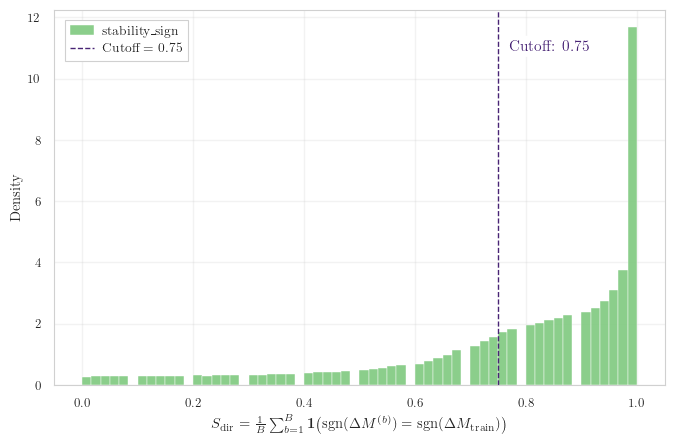

In [31]:
# =============================
# STEP 3 — PLOT: stability_sign distribution (train↔val agreement)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nSTEP 3 — stability_sign distribution (train↔val agreement)\n")

apply_thesis_style(use_tex=True, legend_position="upper left", legend_outside=False)

fig, ax = plt.subplots()

HIST_COLOR = "#7FC97F"
CUT_COLOR = plt.cm.viridis(0.10)

ax.hist(
    stability_sign,
    bins=60,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label="stability_sign",
    zorder=1,
)

ax.axvline(
    STABILITY_SIGN_MIN,
    linestyle="--",
    linewidth=1.0,
    color=CUT_COLOR,
    label=rf"Cutoff = {STABILITY_SIGN_MIN:.2f}",
    zorder=2,
)

ax.set_xlabel(
    r"$S_{\mathrm{dir}}=\frac{1}{B}\sum_{b=1}^{B}\mathbf{1}\!\left("
    r"\mathrm{sgn}(\Delta M^{(b)})=\mathrm{sgn}(\Delta M_{\mathrm{train}})"
    r"\right)$"
)
ax.set_ylabel("Density")

# annotation (white background only, no border)
ymax = ax.get_ylim()[1]
ax.text(
    STABILITY_SIGN_MIN + 0.02,
    ymax * 0.92,
    f"Cutoff: {STABILITY_SIGN_MIN:.2f}",
    color=CUT_COLOR,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
OUTDIR = Path(OUTPUT_DIR) / "plots_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / "stability_sign_distribution.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

print(f"Saved plot to: {pdf_path}")

plt.show()


STEP 3 — RSKF score vs |ΔM| on TRAIN (candidates highlighted)

Saved plot to: /kaggle/working/plots_outputs/absDeltaM_vs_score.pdf


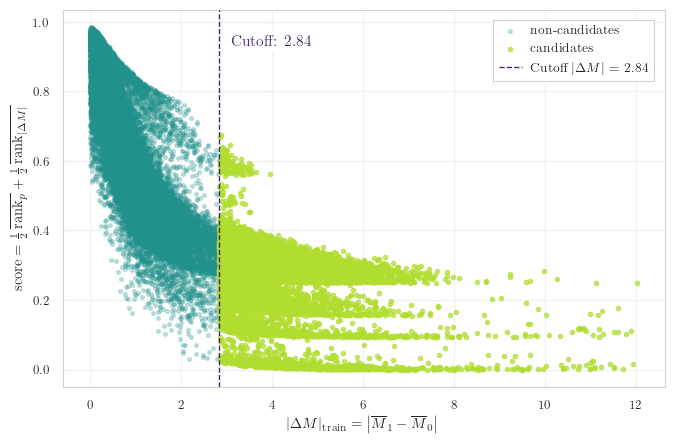

In [32]:
# =============================
# STEP 3 — PLOT: RSKF score vs |ΔM| (viridis coherent palette)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nSTEP 3 — RSKF score vs |ΔM| on TRAIN (candidates highlighted)\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

score = np.asarray(score, dtype=float)
abs_dM_full = np.asarray(abs_dM_full, dtype=float)
mask_cand = np.asarray(mask_cand, dtype=bool)

idx_cand = np.where(mask_cand)[0]
idx_non = np.where(~mask_cand)[0]

MAX_NON = 25000
if idx_non.size > MAX_NON:
    rng = np.random.default_rng(RANDOM_STATE)
    idx_non = rng.choice(idx_non, size=MAX_NON, replace=False)

# --- VIRIDIS PALETTE ---
c_non   = plt.cm.viridis(0.50)  # verde medio/scuro (tolte)
c_cand  = plt.cm.viridis(0.88)  # giallo-verde chiaro (tenute)
c_line  = plt.cm.viridis(0.10)  # verde scuro (cutoff)

fig, ax = plt.subplots()

ax.scatter(
    abs_dM_full[idx_non],
    score[idx_non],
    s=7,
    alpha=0.25,
    color=c_non,
    label="non-candidates",
    zorder=1,
)

ax.scatter(
    abs_dM_full[idx_cand],
    score[idx_cand],
    s=9,
    alpha=0.70,
    color=c_cand,
    label="candidates",
    zorder=2,
)

ax.axvline(
    thr,
    linestyle="--",
    linewidth=1.0,
    color=c_line,
    label=rf"Cutoff $|\Delta M|$ = {thr:.2f}",
    zorder=3,
)

ax.set_xlabel(r"$|\Delta M|_{\mathrm{train}} = \left|\overline{M}_{1} - \overline{M}_{0}\right|$")
ax.set_ylabel(
    r"$\mathrm{score} = \frac{1}{2}\,\overline{\mathrm{rank}_{p}} + \frac{1}{2}\,\overline{\mathrm{rank}_{|\Delta M|}}$"
)

# Annotazione cutoff stile Edgar
ymax = ax.get_ylim()[1]
x_text = thr + 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])

ax.text(
    x_text,
    ymax * 0.93,
    f"Cutoff: {thr:.2f}",
    color=c_line,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

OUTDIR = Path(OUTPUT_DIR) / "plots_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)
pdf_path = OUTDIR / "absDeltaM_vs_score.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

In [33]:
# =============================
# STEP 3 — CHECK: Spearman corr(score, |ΔM|) on TRAIN
#   tells you if the score is basically dominated by effect size
# =============================

import numpy as np
from scipy.stats import spearmanr

print("\nSTEP 3 — Spearman correlation between score and |ΔM| (full train)\n")

# Assumes from STEP 3 you have:
#   score        : np.ndarray (len p)
#   abs_dM_full  : np.ndarray (len p)
#   mask_cand    : np.ndarray bool (len p)  [optional]
#   cpg_cols_current : list/array CpG ids (len p) [optional]

score_arr = np.asarray(score, dtype=float)
absdm_arr = np.asarray(abs_dM_full, dtype=float)

# Safety: remove NaNs/Infs if any
ok = np.isfinite(score_arr) & np.isfinite(absdm_arr)
score_ok = score_arr[ok]
absdm_ok = absdm_arr[ok]

# Spearman on all CpGs
rho_all, p_all = spearmanr(score_ok, absdm_ok)

print(f"[ALL CpGs] Spearman rho(score, |ΔM|) = {rho_all:.4f} | p-value = {p_all:.3e} | n = {score_ok.size:,}")

# Optional: Spearman on candidates only (after stability + |ΔM| thresholds)
if "mask_cand" in globals():
    mask = np.asarray(mask_cand, dtype=bool)
    mask = mask & ok
    if mask.sum() > 10:
        rho_c, p_c = spearmanr(score_arr[mask], absdm_arr[mask])
        print(f"[CANDIDATES] Spearman rho(score, |ΔM|) = {rho_c:.4f} | p-value = {p_c:.3e} | n = {int(mask.sum()):,}")
    else:
        print("[CANDIDATES] not enough points to compute reliably.")

# Optional: quick diagnostic interpretation
if np.isfinite(rho_all):
    if abs(rho_all) > 0.90:
        print("Interpretation: |rho|>0.90 ⇒ score is (almost) monotone in |ΔM| → ranking dominated by effect size.")
    elif abs(rho_all) > 0.70:
        print("Interpretation: 0.70<|rho|<=0.90 ⇒ strong link: effect size is a major driver, MWU still contributes.")
    else:
        print("Interpretation: |rho|<=0.70 ⇒ MWU ranks contribute materially beyond effect size.")


STEP 3 — Spearman correlation between score and |ΔM| (full train)

[ALL CpGs] Spearman rho(score, |ΔM|) = -0.8752 | p-value = 0.000e+00 | n = 270,094
[CANDIDATES] Spearman rho(score, |ΔM|) = -0.4047 | p-value = 0.000e+00 | n = 15,659
Interpretation: 0.70<|rho|<=0.90 ⇒ strong link: effect size is a major driver, MWU still contributes.


In [34]:
# -----------------------------
# STEP 3b — Region anchoring su CpG islands (DIRECTIVE-COMPLIANT)
#   region_score = median(score) × fraction_stable
#   fraction_stable >= 0.6, >= 2 CpG per regione
#   top-m (m=2-3) per regione -> Pool A [anchored]
#   resto -> Pool B [non-anchored]
#
# NOTE (aderenza):
# - "fraction_stable" qui è calcolata su CpG che rispettano i vincoli di STEP 3:
#     stability_sign >= 0.75  AND  |ΔM| >= thr_usato_in_step3
#   (thr_usato_in_step3 = 0.15 oppure 0.10 se fallback)
# -----------------------------

import numpy as np
import polars as pl

print("\n" + "=" * 90)
print("STEP 3b — Region anchoring su CpG islands")
print("=" * 90)

# CONFIG
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"
MANIFEST_CPG_COL = "IlmnID"
MANIFEST_ISLAND_NAME_COL = "UCSC_CpG_Islands_Name"
MANIFEST_REL_COL = "Relation_to_UCSC_CpG_Island"

ANCHOR_CONTEXT = {"Island"}        # anchoring strictly on islands
FRACTION_STABLE_MIN = 0.60
MIN_CPGS_PER_REGION = 2
TOP_M_PER_REGION = 3               # set 2 or 3

# Assumes from STEP 3:
#   cpg_candidates : (n_cand,)
#   step3_stats["score"] : (n_cand,)   lower is better
#   step3_stats["stability_sign"] : (n_cand,)
#   step3_stats["abs_deltaM_full"] : (n_cand,)
#   step3_stats["used_deltaM_thr"] : scalar (0.15 or 0.10)
cand = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)
cand_stab  = np.array(step3_stats["stability_sign"], dtype=float)
cand_absdM = np.array(step3_stats["abs_deltaM_full"], dtype=float)
thr_used   = float(step3_stats["used_deltaM_thr"])

if not (cand.shape[0] == cand_score.shape[0] == cand_stab.shape[0] == cand_absdM.shape[0]):
    raise RuntimeError("STEP 3b: candidate arrays are misaligned (cpg_candidates vs step3_stats).")

# Define CpG-level "stable" flag per STEP 3 directive (within the candidate set)
stable_cpg_flag = (cand_stab >= STABILITY_SIGN_MIN) & (cand_absdM >= thr_used)

print(f"Candidates: {cand.size:,}")
print(f"ΔM threshold used in STEP 3: {thr_used:.2f}")
print(f"Stable CpGs inside candidates (stab>=0.75 AND |ΔM|>=thr): {int(stable_cpg_flag.sum()):,}")

# -----------------------------
# A) Build CpG -> island mapping (only Island context and named islands)
# -----------------------------
def load_manifest_with_real_header(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        start_row = None
        for i, line in enumerate(f):
            if line.startswith("IlmnID"):
                start_row = i
                break
    if start_row is None:
        raise ValueError(f"Non trovo header 'IlmnID' in: {path}")
    return pd.read_csv(path, skiprows=start_row, low_memory=False)

mf = load_manifest_with_real_header(MANIFEST_PATH)

# Keep only required columns
mf = mf[[MANIFEST_CPG_COL, MANIFEST_ISLAND_NAME_COL, MANIFEST_REL_COL]].copy()

mf.columns = ["cpg", "island", "rel"]

mf["cpg"] = mf["cpg"].astype(str)
mf["island"] = mf["island"].fillna("").astype(str).str.strip()
mf["rel"] = mf["rel"].fillna("").astype(str).str.strip()

# Filter strictly Island context + named islands
mf_island = mf[
    (mf["rel"].isin(list(ANCHOR_CONTEXT))) &
    (mf["island"] != "")
]

# CpG -> island dictionary
cpg_to_island = dict(zip(mf_island["cpg"], mf_island["island"]))

# map candidates to islands
island_id = np.array([cpg_to_island.get(c, None) for c in cand], dtype=object)
in_island = island_id != None
print(f"Mapped to named CpG islands (context={ANCHOR_CONTEXT}): {int(in_island.sum()):,}")

# -----------------------------
# B) Group by island, compute region_score and pick top-m CpGs per selected region
# -----------------------------
island_to_idx = {}
for i, rid in enumerate(island_id):
    if rid is None:
        continue
    island_to_idx.setdefault(rid, []).append(i)

region_rows = []
poolA_idx = []

for rid, idxs in island_to_idx.items():
    idxs = np.array(idxs, dtype=int)

    # constraint: >= 2 CpGs per region
    if idxs.size < MIN_CPGS_PER_REGION:
        continue

    # fraction_stable computed on STEP3 "stable" definition
    frac_stable = float(stable_cpg_flag[idxs].mean())
    if frac_stable < FRACTION_STABLE_MIN:
        continue

    # region_score = median(score) * fraction_stable
    med_score = float(np.median(cand_score[idxs]))
    region_score = med_score * frac_stable

    # top-m per region by candidate score (lower better)
    order = np.argsort(cand_score[idxs], kind="mergesort")
    chosen = idxs[order[:min(TOP_M_PER_REGION, idxs.size)]]
    poolA_idx.extend(chosen.tolist())

    region_rows.append((rid, idxs.size, frac_stable, med_score, region_score, chosen.size))

poolA_idx = np.array(sorted(set(poolA_idx)), dtype=int)

# -----------------------------
# C) Final pools
# -----------------------------
poolA_cpgs = cand[poolA_idx]  # anchored

maskA = np.zeros(cand.size, dtype=bool)
maskA[poolA_idx] = True
poolB_cpgs = cand[~maskA]     # non-anchored

print(f"Selected regions (pass constraints): {len(region_rows):,}")
print(f"Pool A (anchored) CpGs: {poolA_cpgs.size:,}  (top-m={TOP_M_PER_REGION} per region)")
print(f"Pool B (non-anchored) CpGs: {poolB_cpgs.size:,}")

region_summary = (
    pl.DataFrame(
        region_rows,
        schema=["island_id", "n_cpgs", "fraction_stable", "median_score", "region_score", "picked_m"]
    ).sort("region_score")
)

print("Top 5 regions by region_score (lower is better):")
print(region_summary.head(5))

# Outputs:
#   poolA_cpgs, poolB_cpgs, region_summary


STEP 3b — Region anchoring su CpG islands
Candidates: 15,659
ΔM threshold used in STEP 3: 2.84
Stable CpGs inside candidates (stab>=0.75 AND |ΔM|>=thr): 15,659
Mapped to named CpG islands (context={'Island'}): 2,070
Selected regions (pass constraints): 275
Pool A (anchored) CpGs: 630  (top-m=3 per region)
Pool B (non-anchored) CpGs: 15,029
Top 5 regions by region_score (lower is better):
shape: (5, 6)
┌──────────────────────────┬────────┬─────────────────┬──────────────┬──────────────┬──────────┐
│ island_id                ┆ n_cpgs ┆ fraction_stable ┆ median_score ┆ region_score ┆ picked_m │
│ ---                      ┆ ---    ┆ ---             ┆ ---          ┆ ---          ┆ ---      │
│ str                      ┆ i64    ┆ f64             ┆ f64          ┆ f64          ┆ i64      │
╞══════════════════════════╪════════╪═════════════════╪══════════════╪══════════════╪══════════╡
│ chr19:18716229-18718743  ┆ 3      ┆ 1.0             ┆ 0.000375     ┆ 0.000375     ┆ 3        │
│ chr11:4719

In [35]:
# -----------------------------
# SAVE outputs for knapsack (Pool A / Pool B + region summary)
# -----------------------------
import pandas as pd
import pickle
from pathlib import Path

FS_OUTDIR = Path("./fs_outputs")
FS_OUTDIR.mkdir(parents=True, exist_ok=True)

# 1) Save Pool A / Pool B as pickles (fast, preserves types)
with open(FS_OUTDIR / "poolA_cpgs._GSE287331.pkl", "wb") as f:
    pickle.dump(poolA_cpgs.astype(str).tolist(), f)

with open(FS_OUTDIR / "poolB_cpgs_GSE287331.pkl", "wb") as f:
    pickle.dump(poolB_cpgs.astype(str).tolist(), f)

# 2) Also save as CSV (handy for inspection / portability)
pd.Series(poolA_cpgs.astype(str), name="CpG").to_csv(FS_OUTDIR / "poolA_cpgs_GSE287331.csv", index=False)
pd.Series(poolB_cpgs.astype(str), name="CpG").to_csv(FS_OUTDIR / "poolB_cpgs_GSE287331.csv", index=False)

# 3) Save region summary table (polars -> parquet + csv)
region_summary.write_parquet(FS_OUTDIR / "region_summary.parquet")
region_summary.write_csv(FS_OUTDIR / "region_summary.csv")

print(f"Saved PoolA/PoolB and region_summary to: {FS_OUTDIR.resolve()}")
print(f"  poolA_cpgs: {len(poolA_cpgs):,}")
print(f"  poolB_cpgs: {len(poolB_cpgs):,}")

Saved PoolA/PoolB and region_summary to: /kaggle/working/fs_outputs
  poolA_cpgs: 630
  poolB_cpgs: 15,029


In [36]:
from pathlib import Path
import polars as pl

# CONFIG
OUTDIR = Path("./region_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# (opzionale ma consigliato) ordina e forza schema stabile
region_summary_out = (
    region_summary
    .select([
        "island_id",
        "n_cpgs",
        "fraction_stable",
        "median_score",
        "region_score",
        "picked_m",
    ])
    .with_columns([
        pl.col("island_id").cast(pl.Utf8),
        pl.col("n_cpgs").cast(pl.Int64),
        pl.col("picked_m").cast(pl.Int64),
        pl.col("fraction_stable").cast(pl.Float64),
        pl.col("median_score").cast(pl.Float64),
        pl.col("region_score").cast(pl.Float64),
    ])
    .sort(["region_score", "island_id"])
)

csv_path = OUTDIR / f"region_summary.csv"
parq_path = OUTDIR / f"region_summary.parquet"

region_summary_out.write_csv(csv_path)
region_summary_out.write_parquet(parq_path)

print(f"Saved CSV:   {csv_path}")
print(f"Saved PARQ:  {parq_path}")
print(f"Rows: {region_summary_out.height:,}")


Saved CSV:   region_outputs/region_summary.csv
Saved PARQ:  region_outputs/region_summary.parquet
Rows: 275



STEP 3b — Region anchoring: selected regions = 275

Saved plot to: /kaggle/working/plots_outputs/region_score_distribution.pdf


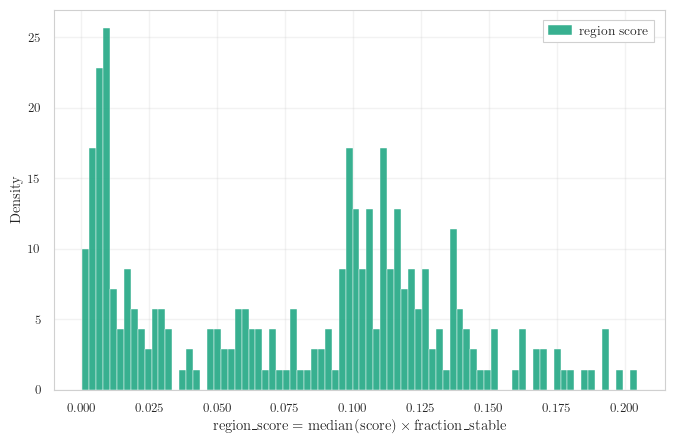

In [37]:
# =============================
# STEP 3b — PLOT: Region_score distribution (selected regions)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


print(f"\nSTEP 3b — Region anchoring: selected regions = {len(region_summary):,}\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

# extract region_score
rs = region_summary.select("region_score").to_numpy().ravel().astype(float)

fig, ax = plt.subplots()

# histogram (viridis mid-green)
hist_color = plt.cm.viridis(0.60)

ax.hist(
    rs,
    bins=80,
    density=True,
    alpha=0.90,
    color=hist_color,
    edgecolor="white",
    linewidth=0.35,
    label=r"$\mathrm{region \; score}$",
)

ax.set_xlabel(r"$\mathrm{region\_score} = \mathrm{median}(\mathrm{score}) \times \mathrm{fraction\_stable}$")
ax.set_ylabel("Density")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
OUTDIR = Path(OUTPUT_DIR) / "plots_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / f"region_score_distribution.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

print(f"Saved plot to: {pdf_path}")

plt.show()

In [38]:
# -----------------------------
# STEP 4 — Correlation clustering separato (DIRECTIVE-COMPLIANT)
#   Pool A: |r| >= 0.85  -> connected components -> 1 CpG/cluster (best STEP3 score)
#   Pool B: |r| >= 0.85  -> connected components -> 1 CpG/cluster (best STEP3 score)
#   Output: unione dei rappresentanti (A prima di B, unique)
#
# NOTE (aderenza):
# - correlazioni calcolate SOLO su TRAIN (M_train)
# - "miglior score" = minimo STEP3 score (0.5·mean(rank_p)+0.5·mean(rank_|ΔM|))
# - cluster = componenti connesse del grafo soglia |r|>=thr
# -----------------------------

import numpy as np

print("\n" + "=" * 90)
print("STEP 4 — Correlation clustering separato (Pool A, Pool B) |r|>=0.85")
print("=" * 90)

# CONFIG
CORR_CLUSTER_THR = 0.85

# Assumes from previous steps:
#   - M_train : (n_train, p_all)  TRAIN matrix in M-space (post STEP 2)
#   - cpg_cols_current : (p_all,) CpG names aligned to columns of M_train
#   - cpg_candidates : (n_cand,) top candidates from STEP 3
#   - step3_stats["score"] aligned to cpg_candidates (lower is better)
#   - poolA_cpgs, poolB_cpgs from STEP 3b

cols_all = np.array(cpg_cols_current, dtype=object)
col_to_j = {c: j for j, c in enumerate(cols_all)}

cand = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)

# Map CpG -> STEP3 score (used to pick representative)
score_map = {c: s for c, s in zip(cand, cand_score)}

def _build_Z(pool_cpgs: np.ndarray):
    """
    Return standardized TRAIN matrix Z for pool CpGs and the ordered CpG list (aligned to Z columns).
    Standardization is per-CpG on TRAIN only.
    """
    pool = np.array([c for c in pool_cpgs if c in col_to_j], dtype=object)
    if pool.size == 0:
        return np.empty((M_train.shape[0], 0), dtype=np.float32), pool

    jj = np.array([col_to_j[c] for c in pool], dtype=int)
    Xp = M_train[:, jj].astype(np.float32, copy=False)

    mu = Xp.mean(axis=0)
    sd = Xp.std(axis=0, ddof=1) + 1e-12
    Z = (Xp - mu) / sd
    return Z, pool

def _connected_components_from_corr(Z: np.ndarray, thr: float):
    """
    Graph on CpGs where edge(i,j)=1 if |corr(i,j)|>=thr.
    Connected components = clusters.
    corr computed on standardized TRAIN data: C = (Z^T Z)/(n-1).
    """
    p = Z.shape[1]
    if p == 0:
        return []
    if p == 1:
        return [[0]]

    n = Z.shape[0]
    C = (Z.T @ Z) / (n - 1)
    A = (np.abs(C) >= thr)
    np.fill_diagonal(A, True)

    visited = np.zeros(p, dtype=bool)
    comps = []
    for i in range(p):
        if visited[i]:
            continue
        stack = [i]
        visited[i] = True
        comp = []
        while stack:
            u = stack.pop()
            comp.append(u)
            nbrs = np.where(A[u])[0]
            for v in nbrs:
                if not visited[v]:
                    visited[v] = True
                    stack.append(v)
        comps.append(comp)
    return comps

def _pick_rep_by_best_score(pool_order: np.ndarray, comps):
    """Pick 1 CpG per component by minimal STEP3 score (lower is better)."""
    reps = []
    for comp in comps:
        members = pool_order[np.array(comp, dtype=int)]
        scores = np.array([score_map.get(c, np.inf) for c in members], dtype=float)
        best = members[int(np.argmin(scores))]
        reps.append(best)
    return np.array(reps, dtype=object)

def cluster_pool(pool_name: str, pool_cpgs: np.ndarray, thr: float):
    Z, pool_order = _build_Z(pool_cpgs)
    print(f"{pool_name}: CpGs in pool={pool_order.size:,}")

    if pool_order.size == 0:
        return np.array([], dtype=object), np.array([], dtype=int)

    comps = _connected_components_from_corr(Z, thr=thr)
    reps = _pick_rep_by_best_score(pool_order, comps)

    sizes = np.array([len(c) for c in comps], dtype=int)
    print(f"{pool_name}: clusters={len(comps):,} | reps={reps.size:,} | "
          f"median_cluster_size={int(np.median(sizes))} | max_cluster_size={int(sizes.max())}")
    return reps, sizes

# Separate clustering as per directive
reps_A, sizes_A = cluster_pool("Pool A (anchored)", poolA_cpgs, thr=CORR_CLUSTER_THR)
reps_B, sizes_B = cluster_pool("Pool B (non-anchored)", poolB_cpgs, thr=CORR_CLUSTER_THR)

# Union of representatives (A first, then B), unique
reps_union = np.array(list(dict.fromkeys(np.concatenate([reps_A, reps_B]).tolist())), dtype=object)

print(f"Union representatives: {reps_union.size:,} (A={reps_A.size:,}, B={reps_B.size:,})")

# Outputs for STEP 5:
#   reps_A, reps_B, reps_union


STEP 4 — Correlation clustering separato (Pool A, Pool B) |r|>=0.85
Pool A (anchored): CpGs in pool=630
Pool A (anchored): clusters=599 | reps=599 | median_cluster_size=1 | max_cluster_size=32
Pool B (non-anchored): CpGs in pool=15,029
Pool B (non-anchored): clusters=14,924 | reps=14,924 | median_cluster_size=1 | max_cluster_size=106
Union representatives: 15,523 (A=599, B=14,924)


[OK] Saved PDF → /kaggle/working/figures/step4/GSE287331_cluster_size_ccdf_loglog_r0.85.pdf


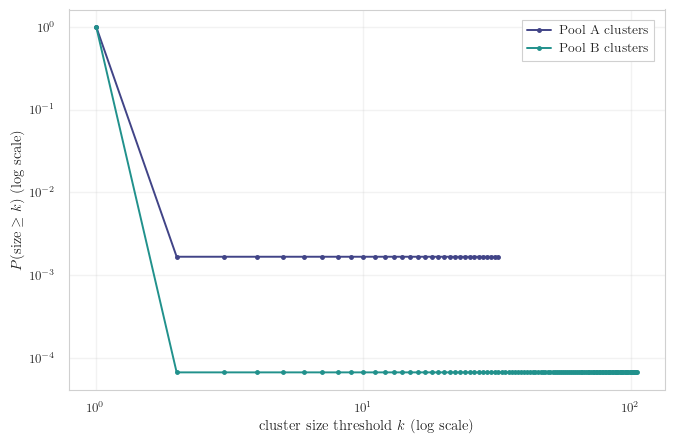

Correlation clustering tail (CCDF), $|r|\geq 0.85$


In [39]:
# =============================
# STEP 4 — PLOT (CCDF log-log, Viridis): Cluster size tail (Pool A vs Pool B)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

def ccdf_from_sizes(sizes: np.ndarray):
    sizes = np.asarray(sizes, dtype=int)
    sizes = sizes[sizes >= 1]
    if sizes.size == 0:
        return np.array([], dtype=int), np.array([], dtype=float)

    max_k = int(sizes.max())
    ks = np.arange(1, max_k + 1, dtype=int)

    hist = np.bincount(sizes, minlength=max_k + 1)
    tail_counts = np.cumsum(hist[::-1])[::-1]
    ccdf = tail_counts[ks] / float(sizes.size)
    return ks, ccdf

kA, ccdfA = ccdf_from_sizes(sizes_A)
kB, ccdfB = ccdf_from_sizes(sizes_B)

if ccdfA.size == 0 and ccdfB.size == 0:
    raise ValueError("Both sizes_A and sizes_B are empty.")

# --- Viridis colors ---
cmap = plt.cm.viridis
color_A = cmap(0.2)
color_B = cmap(0.5)

fig, ax = plt.subplots()

if ccdfA.size:
    ax.plot(kA, ccdfA,
            marker="o", markersize=2.5, linewidth=1.4,
            color=color_A, label="Pool A clusters")

if ccdfB.size:
    ax.plot(kB, ccdfB,
            marker="o", markersize=2.5, linewidth=1.4,
            color=color_B, label="Pool B clusters")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("cluster size threshold $k$ (log scale)")
ax.set_ylabel(r"$P(\mathrm{size}\geq k)$ (log scale)")


place_legend(ax)
fig.tight_layout()

OUT_DIR = Path(OUTPUT_DIR) / "figures" / "step4"
OUT_DIR.mkdir(parents=True, exist_ok=True)
pdf_path = OUT_DIR / f"GSE287331_cluster_size_ccdf_loglog_r{CORR_CLUSTER_THR:.2f}.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"[OK] Saved PDF → {pdf_path}")

plt.show()
print(f"Correlation clustering tail (CCDF), $|r|\geq {CORR_CLUSTER_THR:.2f}$")

In [40]:
# -----------------------------
# STEP 5 — Diversificazione soft + greedy (DIRECTIVE-COMPLIANT)
#   Vincoli (soft, target):
#     - chr <= 20% (sul K target, non dinamico su n_next)
#     - contesto <= 65% (sul K target, non dinamico su n_next)
#     - max 15 CpG / 500kb (vincolo spaziale hard finché non si rilassa)
#   Allentamento: spaziale -> contesto -> chr
# -----------------------------

import numpy as np
import polars as pl

print("\n" + "=" * 90)
print("STEP 5 — Diversification greedy with soft constraints + relaxation (spatial→context→chr)")
print("=" * 90)

# CONFIG
K_TARGET = 5000
CHR_MAX_FRAC = 0.08
CTX_MAX_FRAC = 0.65
WIN_BP = 500_000
MAX_PER_WIN = 15

MANIFEST_CPG_COL = "IlmnID"
MANIFEST_CHR_COL = "CHR"
MANIFEST_POS_COL = "MAPINFO"
MANIFEST_CTX_COL = "Relation_to_UCSC_CpG_Island"

# Assumes:
#   reps_union : (n_reps,)
#   score_map  : dict CpG -> STEP3 score (lower is better)
reps = np.array(reps_union, dtype=object)
if reps.size == 0:
    raise RuntimeError("STEP 5: reps_union is empty.")

# -----------------------------
# A) Manifest mapping CpG -> chr, pos, context
# -----------------------------
# -----------------------------
# Manifest load (robust) + mapping reps
# -----------------------------
mf_pd = load_manifest_with_real_header(MANIFEST_PATH)

# Convert to Polars and normalize the needed columns
mf = pl.from_pandas(mf_pd).select([
    pl.col(MANIFEST_CPG_COL).cast(pl.Utf8).alias("cpg"),
    pl.col(MANIFEST_CHR_COL).cast(pl.Utf8).alias("chr"),
    pl.col(MANIFEST_POS_COL).cast(pl.Int64).alias("pos"),
    pl.col(MANIFEST_CTX_COL).cast(pl.Utf8).alias("ctx"),
]).with_columns([
    pl.col("cpg").fill_null("").str.strip_chars(),
    pl.col("chr").fill_null("").str.strip_chars(),
    pl.col("ctx").fill_null("OpenSea").str.strip_chars(),
])

# Filter only reps
mf = mf.filter(pl.col("cpg").is_in(reps.tolist()))

# Build maps
cpg_to_chr = dict(zip(mf["cpg"].to_list(), mf["chr"].to_list()))
cpg_to_pos = dict(zip(mf["cpg"].to_list(), mf["pos"].to_list()))
cpg_to_ctx = dict(zip(mf["cpg"].to_list(), mf["ctx"].to_list()))

# Keep only reps that map to chr+pos
mapped = []
for c in reps:
    ch = cpg_to_chr.get(c, "")
    ps = cpg_to_pos.get(c, None)
    if ch == "" or ps is None:
        continue
    mapped.append(c)

mapped = np.array(mapped, dtype=object)  # se ti serve come array

print(f"Reps union: {reps.size:,}")
print(f"Mapped reps (chr+pos available): {mapped.size:,}")
if mapped.size == 0:
    raise RuntimeError("STEP 5: No CpGs have manifest chr/pos mapping.")

# -----------------------------
# B) Greedy order by STEP3 score (lower better)
# -----------------------------
scores = np.array([score_map.get(c, np.inf) for c in mapped], dtype=float)
order = np.argsort(scores, kind="mergesort")
cand = mapped[order]
cand_scores = scores[order]

# -----------------------------
# C) Diversification greedy with staged relaxation (budgets on K_TARGET)
# -----------------------------
def diversify_greedy_budgets(
    cand_cpgs: np.ndarray,
    cand_scores: np.ndarray,
    k_target: int,
    enforce_spatial: bool,
    enforce_context: bool,
    enforce_chr: bool,
):
    selected = []
    chr_counts = {}
    ctx_counts = {}
    win_counts = {}  # (chr, win_id) -> count

    # budgets computed vs final K target (directive intent)
    chr_budget = int(np.floor(CHR_MAX_FRAC * k_target))
    ctx_budget = int(np.floor(CTX_MAX_FRAC * k_target))
    chr_budget = max(chr_budget, 1)
    ctx_budget = max(ctx_budget, 1)

    def _ok_chr(ch):
        if not enforce_chr:
            return True
        return (chr_counts.get(ch, 0) + 1) <= chr_budget

    def _ok_ctx(ctx):
        if not enforce_context:
            return True
        return (ctx_counts.get(ctx, 0) + 1) <= ctx_budget

    def _ok_spatial(ch, pos):
        if not enforce_spatial:
            return True
        win_id = int(pos // WIN_BP)
        return (win_counts.get((ch, win_id), 0) + 1) <= MAX_PER_WIN

    for c, s in zip(cand_cpgs, cand_scores):
        if len(selected) >= k_target:
            break

        ch = cpg_to_chr.get(c, "")
        pos = cpg_to_pos.get(c, None)
        ctx = cpg_to_ctx.get(c, "OpenSea")
        if ch == "" or pos is None:
            continue

        if not _ok_spatial(ch, pos):
            continue
        if not _ok_ctx(ctx):
            continue
        if not _ok_chr(ch):
            continue

        # accept
        selected.append(c)
        chr_counts[ch] = chr_counts.get(ch, 0) + 1
        ctx_counts[ctx] = ctx_counts.get(ctx, 0) + 1
        win_id = int(pos // WIN_BP)
        win_counts[(ch, win_id)] = win_counts.get((ch, win_id), 0) + 1

    return np.array(selected, dtype=object), chr_counts, ctx_counts, win_counts, chr_budget, ctx_budget

stages = [
    ("strict",        True,  True,  True),
    ("relax_spatial", False, True,  True),
    ("relax_context", False, False, True),
    ("relax_chr",     False, False, False),
]

selected_final = None
stage_used = None
diag = None

k_eff = min(K_TARGET, cand.size)

for name, e_sp, e_ctx, e_chr in stages:
    sel, chr_ct, ctx_ct, win_ct, chr_budget, ctx_budget = diversify_greedy_budgets(
        cand, cand_scores,
        k_target=k_eff,
        enforce_spatial=e_sp,
        enforce_context=e_ctx,
        enforce_chr=e_chr,
    )
    print(f"Stage={name:>13} | selected={sel.size:,} / {k_eff:,} | chr_budget={chr_budget} | ctx_budget={ctx_budget}")
    selected_final = sel
    stage_used = name
    diag = (chr_ct, ctx_ct, win_ct)
    if sel.size >= k_eff:
        break

selected_diverse = selected_final
print(f"Final selected after diversification: {selected_diverse.size:,} | stage_used={stage_used}")

chr_ct, ctx_ct, win_ct = diag
top_chr = sorted(chr_ct.items(), key=lambda x: -x[1])[:5]
top_ctx = sorted(ctx_ct.items(), key=lambda x: -x[1])[:5]
print("Top 5 chr counts:", top_chr)
print("Top 5 ctx counts:", top_ctx)

# Output for STEP 6:
#   selected_diverse


STEP 5 — Diversification greedy with soft constraints + relaxation (spatial→context→chr)
Reps union: 15,523
Mapped reps (chr+pos available): 15,523
Stage=       strict | selected=5,000 / 5,000 | chr_budget=400 | ctx_budget=3250
Final selected after diversification: 5,000 | stage_used=strict
Top 5 chr counts: [('1', 400), ('11', 400), ('19', 393), ('17', 364), ('2', 329)]
Top 5 ctx counts: [('Island', 1942), ('OpenSea', 1693), ('N_Shore', 559), ('S_Shore', 484), ('S_Shelf', 167)]


In [41]:
# -----------------------------
# STEP 6 — Final K selection
#   K = 5000 (take first K from STEP 5 output order)
# -----------------------------

K_FINAL = 5000

# Assumes from STEP 5:
#   selected_diverse : CpG list in chosen greedy order (best-first under constraints)
final_cpgs = np.array(selected_diverse, dtype=object)[:min(K_FINAL, len(selected_diverse))]

print("\n" + "=" * 90)
print(f"STEP 6 — Final CpG set: K={K_FINAL} (got {final_cpgs.size:,})")
print("=" * 90)

# Outputs for downstream modeling:
#   final_cpgs


STEP 6 — Final CpG set: K=5000 (got 5,000)


In [42]:
# ============================================================
# EXPORT — cpg_to_chr
# ============================================================

import numpy as np
from pathlib import Path

if "cpg_to_chr" not in globals():
    raise NameError("cpg_to_chr not found in current scope.")

OUTDIR = Path("./knapsack_exports")
OUTDIR.mkdir(parents=True, exist_ok=True)

out_path = OUTDIR / "cpg_to_chr_GSE287331.npz"

# salva come due array paralleli (chiavi + valori)
keys   = np.array(list(cpg_to_chr.keys()), dtype=object)
values = np.array(list(cpg_to_chr.values()), dtype=object)

np.savez_compressed(out_path, keys=keys, values=values)

print("Saved:", out_path)
print("Entries:", len(keys))

Saved: knapsack_exports/cpg_to_chr_GSE287331.npz
Entries: 15523


Diversification result: chromosome composition (n=5,000)
[OK] Saved PDF → /kaggle/working/figures/step5/dataset_chromosome_share_diversified_K5000_maxfrac0.08.pdf


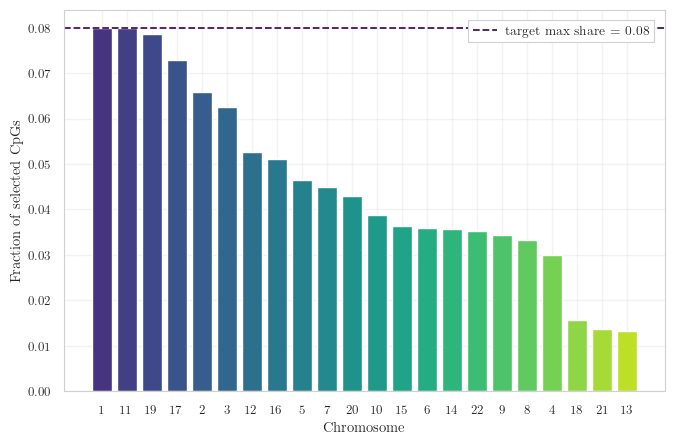

In [43]:
# =============================
# STEP 5 — PLOT: Chromosome share (Viridis + vertical labels)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

sel = np.array(selected_diverse, dtype=object)
chrs = np.array([cpg_to_chr.get(c, "") for c in sel], dtype=object)
chrs = chrs[chrs != ""]

# counts and fractions
uniq, cnt = np.unique(chrs, return_counts=True)
frac = cnt / cnt.sum()

# sort descending
ordr = np.argsort(-frac)
uniq, cnt, frac = uniq[ordr], cnt[ordr], frac[ordr]

# --- Viridis colors ---
cmap = plt.cm.viridis
colors = cmap(np.linspace(0.15, 0.90, len(uniq)))

fig, ax = plt.subplots()
ax.bar(np.arange(len(uniq)), frac, color=colors)

ax.axhline(CHR_MAX_FRAC,
           linestyle="--",
           linewidth=1.3,
           color=cmap(0.05),
           label=rf"target max share = {CHR_MAX_FRAC:.2f}")

ax.set_xticks(np.arange(len(uniq)))
ax.set_xticklabels(uniq, rotation=0, ha="center")

ax.set_ylabel("Fraction of selected CpGs")
ax.set_xlabel("Chromosome")
print(f"Diversification result: chromosome composition (n={len(sel):,})")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE PDF
# -----------------------------
OUT_DIR = Path(OUTPUT_DIR) / "figures" / "step5"
OUT_DIR.mkdir(parents=True, exist_ok=True)

dataset_tag = DATASET_NAME if "DATASET_NAME" in globals() else "dataset"

pdf_path = OUT_DIR / f"{dataset_tag}_chromosome_share_diversified_K{K_TARGET}_maxfrac{CHR_MAX_FRAC:.2f}.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

print(f"[OK] Saved PDF → {pdf_path}")

plt.show()

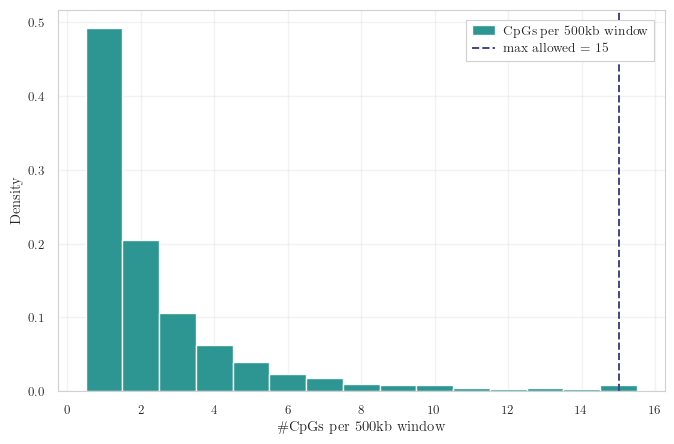

[Spatial density] windows=1999 | max_in_window=15 | violations(cnt>MAX_PER_WIN)=0
Saved as: /kaggle/working/figures/step5/SpatialDensityConstraint.pdf


In [44]:
# =============================
# STEP 5 — Spatial density constraint check
# Save as: SpatialDensityConstraint_<DATASET_NAME>.pdf
# =============================

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib import cm
from pathlib import Path


apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

sel = np.array(selected_diverse, dtype=object)

pairs = []
for c in sel:
    ch = cpg_to_chr.get(c, "")
    ps = cpg_to_pos.get(c, None)
    if (ch == "") or (ps is None):
        continue
    win = int(int(ps) // int(WIN_BP))
    pairs.append((str(ch), win))

if len(pairs) == 0:
    raise RuntimeError("No mapped CpGs for spatial window check.")

cnt = np.array(list(Counter(pairs).values()), dtype=int)

color_main = cm.viridis(0.5)
color_line = cm.viridis(0.2)

fig, ax = plt.subplots()

bins = np.arange(1, cnt.max() + 2) - 0.5
ax.hist(cnt,
        bins=bins,
        density=True,
        alpha=0.95,
        color=color_main,
        label=f"CpGs per {WIN_BP//1000}kb window")

ax.axvline(int(MAX_PER_WIN),
           linestyle="--",
           linewidth=1.4,
           color=color_line,
           label=rf"max allowed = {int(MAX_PER_WIN)}")

ax.set_xlabel(f"\#CpGs per {WIN_BP//1000}kb window")
ax.set_ylabel("Density")

place_legend(ax)
fig.tight_layout()

# ---- SAVE ----
OUT_DIR = Path(OUTPUT_DIR) / "figures" / "step5"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plot_name = "SpatialDensityConstraint"
fname = OUT_DIR / f"{plot_name}.pdf"
fig.savefig(fname, dpi=300, bbox_inches="tight")

plt.show()

print(f"[Spatial density] windows={cnt.size} | max_in_window={cnt.max()} | violations(cnt>MAX_PER_WIN)={int(np.sum(cnt > MAX_PER_WIN))}")
print(f"Saved as: {fname}")

In [45]:
# =============================
# EXPORT — final 5000 CpGs
# =============================

import numpy as np
import polars as pl
from pathlib import Path
from datetime import datetime

# Assumes:
#   final_cpgs : np.ndarray (K=5000) from STEP 6

RUN_TAG = "gse287331_225845_fs_v1"   # cambia come vuoi
OUTDIR = Path(OUTPUT_DIR) / "fs_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

final_cpgs = np.array(final_cpgs, dtype=object)

# basic checks
if final_cpgs.size == 0:
    raise RuntimeError("final_cpgs is empty. Check STEP 6.")
if len(np.unique(final_cpgs)) != final_cpgs.size:
    raise RuntimeError("final_cpgs contains duplicates.")

ts = datetime.now().strftime("%Y%m%d_%H%M%S")

# TXT (one per line)
txt_path = OUTDIR / f"final_cpgs_K{final_cpgs.size}_{RUN_TAG}_{ts}.txt"
with open(txt_path, "w") as f:
    for c in final_cpgs:
        f.write(f"{c}\n")

# CSV
csv_path = OUTDIR / f"final_cpgs_K{final_cpgs.size}_{RUN_TAG}_{ts}.csv"
pl.DataFrame({"CpG_ID": final_cpgs}).write_csv(csv_path)

print("Saved CpGs TXT:", txt_path)
print("Saved CpGs CSV:", csv_path)
print("K =", final_cpgs.size)
print("Example:", final_cpgs[:5].tolist())

Saved CpGs TXT: /kaggle/working/fs_outputs/final_cpgs_K5000_gse287331_225845_fs_v1_20260314_153243.txt
Saved CpGs CSV: /kaggle/working/fs_outputs/final_cpgs_K5000_gse287331_225845_fs_v1_20260314_153243.csv
K = 5000
Example: ['cg02389270', 'cg11849422', 'cg27596786', 'cg01323777', 'cg12595163']


In [46]:
# CELLA 13 — STEP 6: Train SVM sulle CpG di final_cpgs
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

# filtra X_tr_combat e X_te_combat alle sole CpG in final_cpgs
final_cpgs_set = set(final_cpgs)
final_cpgs_indices = np.array(
    [col_to_j[c] for c in final_cpgs if c in col_to_j], dtype=int
)

n_missing = sum(1 for c in final_cpgs if c not in col_to_j)
if n_missing > 0:
    print(f"⚠ {n_missing} CpG di final_cpgs non in common_cpgs — escluse.")

X_tr_fs = X_tr_combat[:, final_cpgs_indices]
X_te_fs = X_te_combat[:, final_cpgs_indices]

print(f"CpG in final_cpgs        : {len(final_cpgs)}")
print(f"CpG trovate in common_cpgs: {len(final_cpgs_indices)}")
print(f"X_tr_fs: {X_tr_fs.shape}")
print(f"X_te_fs: {X_te_fs.shape}")

# cross-validation interna per scegliere C
best_auc, best_C = -1, 1.0
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    pipe = Pipeline([
        ("sc",  StandardScaler()),
        ("clf", CalibratedClassifierCV(LinearSVC(C=C, max_iter=5000), cv=3)),
    ])
    scores = cross_val_score(
        pipe, X_tr_fs, tissue_labels_tr,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc",
    )
    print(f"  C={C:.3f}  AUC={scores.mean():.3f} ± {scores.std():.3f}")
    if scores.mean() > best_auc:
        best_auc, best_C = scores.mean(), C

print(f"\nC ottimale: {best_C}  (CV AUC={best_auc:.3f})")

# train finale
svm_final = Pipeline([
    ("sc",  StandardScaler()),
    ("clf", CalibratedClassifierCV(LinearSVC(C=best_C, max_iter=5000), cv=3)),
])
svm_final.fit(X_tr_fs, tissue_labels_tr)
print("SVM trainato.")

CpG in final_cpgs        : 5000
CpG trovate in common_cpgs: 5000
X_tr_fs: (346, 5000)
X_te_fs: (149, 5000)
  C=0.001  AUC=0.989 ± 0.008
  C=0.010  AUC=0.991 ± 0.007
  C=0.100  AUC=0.991 ± 0.007
  C=1.000  AUC=0.991 ± 0.007
  C=10.000  AUC=0.991 ± 0.007

C ottimale: 0.01  (CV AUC=0.991)
SVM trainato.


AUC  overall : 0.987
BACC overall : 0.958
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97        89
    Adjacent       0.95      0.95      0.95        60

    accuracy                           0.96       149
   macro avg       0.96      0.96      0.96       149
weighted avg       0.96      0.96      0.96       149


AUC per dataset:
  GSE225845: AUC=0.952  BACC=0.920
  GSE287331: AUC=1.000  BACC=1.000


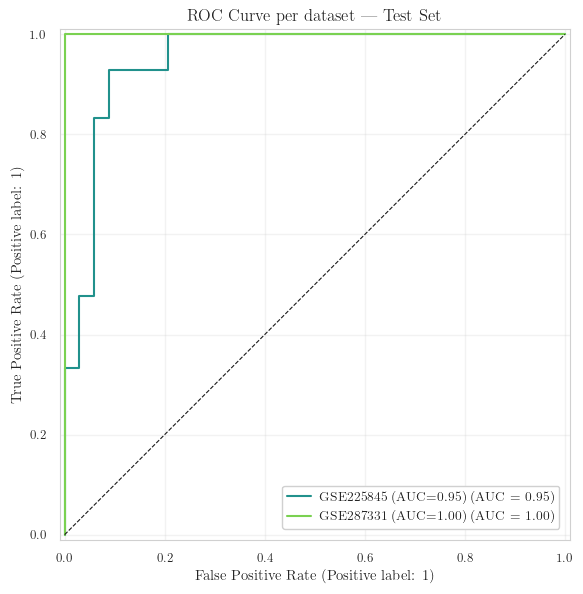

In [47]:
# CELLA 14 — STEP 7: Test e valutazione
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report, RocCurveDisplay

proba_te = svm_final.predict_proba(X_te_fs)[:, 1]
pred_te  = svm_final.predict(X_te_fs)

auc_overall  = roc_auc_score(tissue_labels_te, proba_te)
bacc_overall = balanced_accuracy_score(tissue_labels_te, pred_te)

print("=" * 50)
print(f"AUC  overall : {auc_overall:.3f}")
print(f"BACC overall : {bacc_overall:.3f}")
print("=" * 50)
print(classification_report(tissue_labels_te, pred_te, target_names=["Normal", "Adjacent"]))

# per dataset
print("\nAUC per dataset:")
n_te_offset = 0
for ds in ["GSE225845", "GSE287331"]:
    n_ds = len(X_test_abs[ds])
    mask = np.array(ds_labels_te) == ds
    auc_ds  = roc_auc_score(tissue_labels_te[mask], proba_te[mask])
    bacc_ds = balanced_accuracy_score(tissue_labels_te[mask], pred_te[mask])
    print(f"  {ds}: AUC={auc_ds:.3f}  BACC={bacc_ds:.3f}")

# ROC curve per dataset
fig, ax = plt.subplots(figsize=(7, 6))
for ds in ["GSE225845", "GSE287331"]:
    mask = np.array(ds_labels_te) == ds
    auc_ds = roc_auc_score(tissue_labels_te[mask], proba_te[mask])
    RocCurveDisplay.from_predictions(
        tissue_labels_te[mask], proba_te[mask],
        name=f"{ds} (AUC={auc_ds:.2f})",
        ax=ax, color=DS_PALETTE[ds],
    )
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_title("ROC Curve per dataset — Test Set")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_roc_per_dataset.pdf"), bbox_inches="tight")
plt.show()

In [48]:
# ── Intervalli di confidenza Bootstrap (AUC e BACC) ──────────────────────────
from sklearn.utils import resample

N_BOOT       = 2000
ALPHA        = 0.05
RANDOM_STATE_BOOT = 42

def bootstrap_ci(y_true, y_score, y_pred, n_boot=N_BOOT, alpha=ALPHA, random_state=RANDOM_STATE_BOOT):
    rng = np.random.RandomState(random_state)
    auc_scores  = []
    bacc_scores = []
    for _ in range(n_boot):
        idx = resample(np.arange(len(y_true)), random_state=rng)
        # skip se un solo classe presente
        if len(np.unique(y_true[idx])) < 2:
            continue
        auc_scores.append(roc_auc_score(y_true[idx], y_score[idx]))
        bacc_scores.append(balanced_accuracy_score(y_true[idx], y_pred[idx]))
    auc_lo,  auc_hi  = np.percentile(auc_scores,  [100*alpha/2, 100*(1-alpha/2)])
    bacc_lo, bacc_hi = np.percentile(bacc_scores, [100*alpha/2, 100*(1-alpha/2)])
    return (auc_lo, auc_hi), (bacc_lo, bacc_hi)

print("\n" + "=" * 60)
print(f"Bootstrap CI (n={N_BOOT}, α={ALPHA}) — 95% percentile interval")
print("=" * 60)

# Overall
auc_ci, bacc_ci = bootstrap_ci(tissue_labels_te, proba_te, pred_te)
print(f"\nOverall:")
print(f"  AUC  = {auc_overall:.3f}  [{auc_ci[0]:.3f}, {auc_ci[1]:.3f}]")
print(f"  BACC = {bacc_overall:.3f}  [{bacc_ci[0]:.3f}, {bacc_ci[1]:.3f}]")

# Per dataset
print(f"\nPer dataset:")
for ds in ["GSE225845", "GSE287331"]:
    mask     = np.array(ds_labels_te) == ds
    auc_ds   = roc_auc_score(tissue_labels_te[mask], proba_te[mask])
    bacc_ds  = balanced_accuracy_score(tissue_labels_te[mask], pred_te[mask])
    auc_ci_ds, bacc_ci_ds = bootstrap_ci(
        tissue_labels_te[mask], proba_te[mask], pred_te[mask]
    )
    print(f"  {ds}:")
    print(f"    AUC  = {auc_ds:.3f}  [{auc_ci_ds[0]:.3f}, {auc_ci_ds[1]:.3f}]")
    print(f"    BACC = {bacc_ds:.3f}  [{bacc_ci_ds[0]:.3f}, {bacc_ci_ds[1]:.3f}]")

print("=" * 60)


Bootstrap CI (n=2000, α=0.05) — 95% percentile interval

Overall:
  AUC  = 0.987  [0.969, 0.999]
  BACC = 0.958  [0.921, 0.988]

Per dataset:
  GSE225845:
    AUC  = 0.952  [0.891, 0.994]
    BACC = 0.920  [0.853, 0.975]
  GSE287331:
    AUC  = 1.000  [1.000, 1.000]
    BACC = 1.000  [1.000, 1.000]


In [49]:
def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            parts = [p.strip() for p in line.split(",")]
            if "IlmnID" in parts:
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip"
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

In [50]:
import gc

vars_to_delete = [
    'M_train', 'M_test',
    'X_train_abs', 'X_test_abs',
    'Z', 'C_corr',
    'result',          # output neuroCombat
    'combat_estimates',
    'step3_stats',
    'ip_norm_sum', 'ip_raw_sum',
    'rank_p_sum', 'rank_dm_sum',
    'sign_agree_count', 'sign_valid_count',
]

for v in vars_to_delete:
    if v in globals():
        del globals()[v]

gc.collect()

import psutil
ram = psutil.virtual_memory()
print(f"RAM usata: {ram.used / 1e9:.1f} GB / {ram.total / 1e9:.1f} GB")

RAM usata: 23.1 GB / 33.7 GB


STEP 1 — Estrazione coef SVM
FINAL_CPGS        : 5000
coef range        : [-0.0085, 0.0092]
Conflict edges    : 205
Geni distinti pool : 3364
CpG COSMIC breast  : 17 (0.3%)

STEP 9 — Sweep μ  (K=50, W_COSMIC=0.3)

[μ=0.000] Solving...
  status=Optimal  f1=42.8841  f2=76.5000  Jaccard(0)=1.0000  COSMIC=6

[μ=0.050] Solving...
  status=Optimal  f1=42.8841  f2=76.5000  Jaccard(0)=1.0000  COSMIC=6

[μ=0.100] Solving...
  status=Optimal  f1=42.8830  f2=78.5000  Jaccard(0)=0.9608  COSMIC=6

[μ=0.250] Solving...
  status=Optimal  f1=42.8796  f2=80.5000  Jaccard(0)=0.9231  COSMIC=6

[μ=0.500] Solving...
  status=Optimal  f1=42.8728  f2=83.0000  Jaccard(0)=0.8868  COSMIC=6

[μ=1.000] Solving...
  status=Optimal  f1=42.8328  f2=90.0000  Jaccard(0)=0.7857  COSMIC=6

[μ=2.000] Solving...
  status=Optimal  f1=42.7321  f2=100.5000  Jaccard(0)=0.6129  COSMIC=5

✓ Tutti i μ hanno raggiunto convergenza (Optimal)
Knee: μ=1.000  COSMIC=6


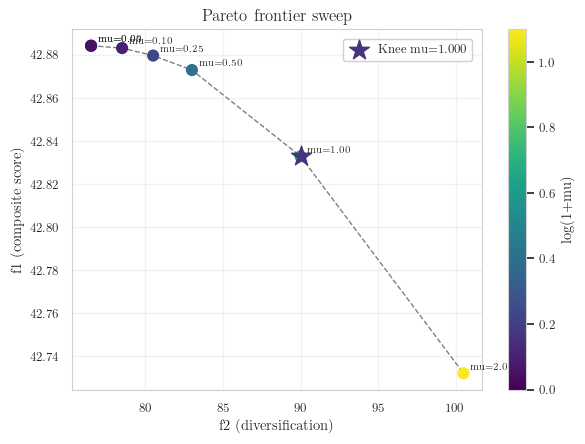

Salvato: knapsack_pareto_mu.pdf

STEP 10 — Sweep W_COSMIC (μ=knee=1.0)
  W_COSMIC=0.00  status=Optimal  f1=42.1454  COSMIC=1
  W_COSMIC=0.10  status=Optimal  f1=42.2454  COSMIC=1
  W_COSMIC=0.20  status=Optimal  f1=42.3717  COSMIC=3
  W_COSMIC=0.30  status=Optimal  f1=42.8328  COSMIC=6
  W_COSMIC=0.50  status=Optimal  f1=44.5264  COSMIC=12
  W_COSMIC=0.70  status=Optimal  f1=47.2333  COSMIC=14
  W_COSMIC=1.00  status=Optimal  f1=51.4333  COSMIC=14

W_COSMIC ottimale: 0.70  COSMIC=14

STEP 11 — Curva Pareto K ∈ [20, 30, 40, 50, 60, 70, 80]

[K=20] Solving (μ=1.0, W_COSMIC=0.7)...
  [K=20] status=Optimal  AUC=0.9809  COSMIC=14  Geni=16

[K=30] Solving (μ=1.0, W_COSMIC=0.7)...
  [K=30] status=Optimal  AUC=0.9820  COSMIC=14  Geni=26

[K=40] Solving (μ=1.0, W_COSMIC=0.7)...
  [K=40] status=Optimal  AUC=0.9693  COSMIC=14  Geni=36

[K=50] Solving (μ=1.0, W_COSMIC=0.7)...
  [K=50] status=Optimal  AUC=0.9734  COSMIC=14  Geni=45

[K=60] Solving (μ=1.0, W_COSMIC=0.7)...
  [K=60] status=Optimal  A

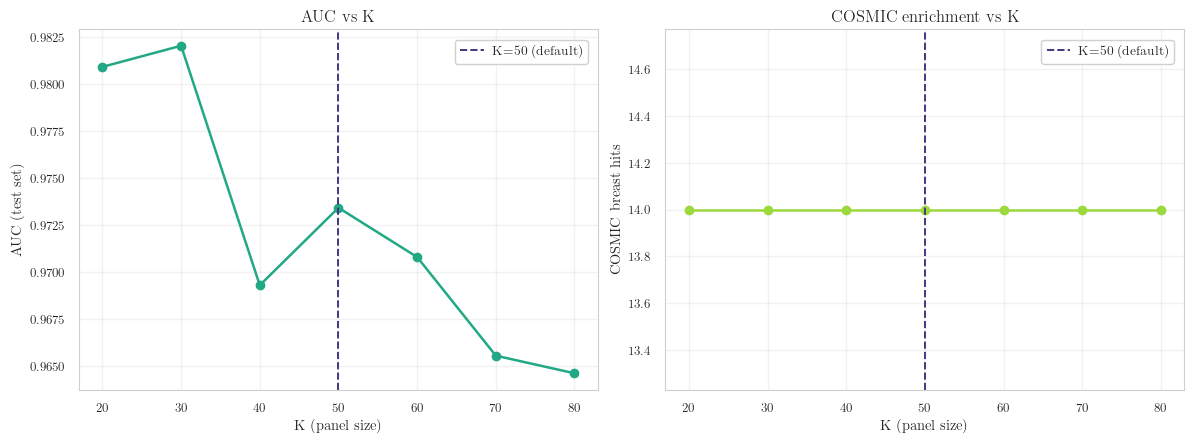

Salvato: knapsack_pareto_K.pdf

STEP 12 — K-fold stabilità (N_FOLDS=5, K=50)

[Fold 1/5]
  Fold 1: status=Optimal  COSMIC=14  Geni=44

[Fold 2/5]
  Fold 2: status=Optimal  COSMIC=14  Geni=43

[Fold 3/5]
  Fold 3: status=Optimal  COSMIC=14  Geni=45

[Fold 4/5]
  Fold 4: status=Optimal  COSMIC=14  Geni=45

[Fold 5/5]
  Fold 5: status=Optimal  COSMIC=14  Geni=43

Convergenza k-fold: 5/5 fold hanno raggiunto l'ottimo

CpG stabili (freq≥0.6): 46
Consensus panel (top-50 per frequenza): 50 CpG
  freq range: [0.40, 1.00]  media: 0.84


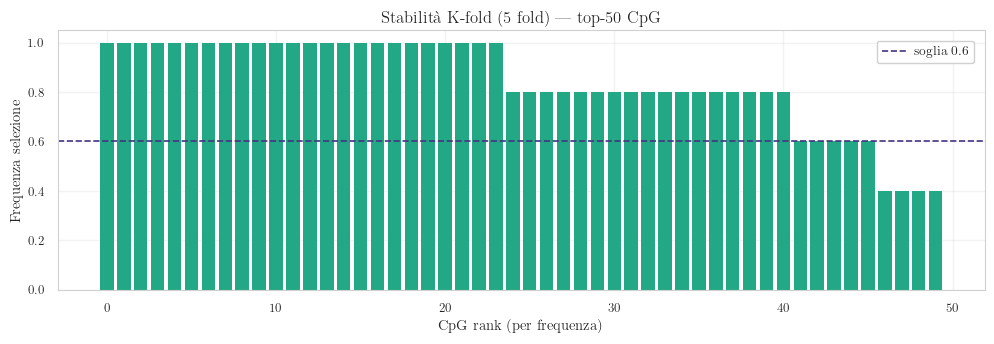

Salvato: knapsack_kfold_stability.pdf

STEP 13 — Evaluation finale

  [sweep_final — N vs A (test)]  n=149 (0=89, 1=60)
  Silhouette    : 0.1294
  AUC CV5       : 0.9491 ± 0.0617
  mean|ΔM|      : 0.0135

  [kfold_consensus — N vs A (test)]  n=149 (0=89, 1=60)
  Silhouette    : 0.1339
  AUC CV5       : 0.9491 ± 0.0623
  mean|ΔM|      : 0.0137

OUTPUT FINALE
  selected_cpgs_final  : 50 CpG  (sweep)
  consensus_panel      : 50 CpG  (k-fold)
  knee_mu              : 1.0
  best_w_cosmic        : 0.7
  convergenza sweep    : ✓ Optimal
  convergenza k-fold   : 5/5 Optimal
  OUTDIR               : /kaggle/working/knapsack_outputs


In [53]:
# ============================================================
# CpG KNAPSACK — MILP bi-obiettivo con sweep su μ  [v4 paper]
# Modifiche vs v3:
#   - score_final = stability_sign dal RSKF (non std)
#   - rank_norm_asc per stability (alta stabilità = valore alto)
#   - CBC time limit → 600s
#   - stampa status convergenza per ogni chiamata
# ============================================================

import numpy as np
import pandas as pd
import polars as pl
import pulp
import csv
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import silhouette_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.decomposition import PCA

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
CGC_PATH      = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"
ID_COL        = "id_tissue"
LABEL_COL     = "label"

K             = 50
N_POOL        = 5000
CHR_MAX       = 10
CORR_THR      = 0.85
ETA           = 0.5

W_COEF        = 0.5
W_DM          = 0.2
W_SCORE       = 0.3
W_COSMIC      = 0.3
W_COSMIC_GRID = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1]

MAX_PER_GENE  = 2

MU_GRID       = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]

K_PARETO_GRID  = [20, 30, 40, 50, 60, 70, 80]
N_FOLDS_STAB   = 5
CBC_TIME_LIMIT = 600        # aumentato da 300s a 600s

EVAL_TUMOR    = False
EPS_M         = 1e-6
RANDOM_STATE  = 42

OUTDIR = Path(OUTPUT_DIR) / "knapsack_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

cpg_cols_current = final_cpgs
FINAL_CPGS       = final_cpgs

# ─────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────
def beta_to_m(b, eps=EPS_M):
    b = np.clip(b, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def rank_norm_asc(v):
    v = np.asarray(v, float)
    v2 = v.copy()
    if np.isnan(v2).any():
        v2 = np.where(np.isnan(v2), np.nanmin(v2) - 1.0, v2)
    r = np.argsort(np.argsort(v2))
    return r / max(1, len(v2) - 1)

def rank_norm_desc(v):
    return 1.0 - rank_norm_asc(v)

def parse_first_gene(g):
    if g is None:
        return None
    s = str(g).strip()
    if s == "" or s.lower() == "nan":
        return None
    for sep in [";", ","]:
        if sep in s:
            s = s.split(sep)[0].strip()
            break
    return s if s != "" else None

def in_promoter(feat):
    if feat is None:
        return False
    s = str(feat)
    return any(k in s for k in ["TSS200", "TSS1500", "1stExon", "5'UTR", "5UTR"])

def in_island(ctx):
    if ctx is None:
        return False
    s = str(ctx)
    return "Island" in s and "Shore" not in s and "Shelf" not in s

def jaccard(s1, s2):
    s1, s2 = set(s1), set(s2)
    if len(s1 | s2) == 0:
        return 1.0
    return len(s1 & s2) / len(s1 | s2)

def knee_index(f1_vals, f2_vals):
    f1 = np.array(f1_vals, float)
    f2 = np.array(f2_vals, float)
    valid = np.ones(len(f2), dtype=bool)
    for i in range(1, len(f2)):
        if f2[i] == f2[i - 1]:
            valid[i] = False
    idx_v = np.where(valid)[0]
    if len(idx_v) < 2:
        return 0
    f1_n = (f1[idx_v] - f1[idx_v].min()) / max(f1[idx_v].max() - f1[idx_v].min(), 1e-12)
    f2_n = (f2[idx_v] - f2[idx_v].min()) / max(f2[idx_v].max() - f2[idx_v].min(), 1e-12)
    p0 = np.array([f2_n[0],  f1_n[0]])
    p1 = np.array([f2_n[-1], f1_n[-1]])
    d  = p1 - p0
    d_norm = d / max(np.linalg.norm(d), 1e-12)
    dists = [
        np.linalg.norm(
            (np.array([f2_n[i], f1_n[i]]) - p0)
            - np.dot(np.array([f2_n[i], f1_n[i]]) - p0, d_norm) * d_norm
        )
        for i in range(len(idx_v))
    ]
    return int(idx_v[np.argmax(dists)])

def eval_pair(name, X, ybin):
    out = {}
    n0, n1 = int((ybin == 0).sum()), int((ybin == 1).sum())
    print(f"\n  [{name}]  n={X.shape[0]} (0={n0}, 1={n1})")
    if X.shape[0] < 10 or n0 == 0 or n1 == 0:
        print("  Campioni insufficienti.")
        return out
    try:
        out["silhouette"] = float(silhouette_score(X, ybin, metric="euclidean"))
        print(f"  Silhouette    : {out['silhouette']:.4f}")
    except Exception as e:
        out["silhouette"] = None
        print(f"  Silhouette    : N/A ({e})")
    try:
        Xsc  = StandardScaler().fit_transform(X)
        lr   = LogisticRegression(C=1.0, class_weight="balanced",
                                  max_iter=2000, random_state=RANDOM_STATE)
        n_cv = min(5, n0, n1)
        aucs = cross_val_score(lr, Xsc, ybin, cv=n_cv, scoring="roc_auc")
        out["auc_mean"] = float(aucs.mean())
        out["auc_std"]  = float(aucs.std())
        print(f"  AUC CV{n_cv}       : {out['auc_mean']:.4f} ± {out['auc_std']:.4f}")
    except Exception as e:
        out["auc_mean"] = out["auc_std"] = None
        print(f"  AUC CV        : N/A ({e})")
    m0, m1 = X[ybin == 0].mean(0), X[ybin == 1].mean(0)
    out["mean_abs_dM"] = float(np.abs(m1 - m0).mean())
    print(f"  mean|ΔM|      : {out['mean_abs_dM']:.4f}")
    return out

# ─────────────────────────────────────────────────────────────
# STEP 1 — Estrai coef SVM
# ─────────────────────────────────────────────────────────────
print("=" * 70)
print("STEP 1 — Estrazione coef SVM")
print("=" * 70)

cols_all  = np.array(FINAL_CPGS, dtype=object)
col_to_j  = {c: j for j, c in enumerate(cols_all.tolist())}
final_arr = np.array(FINAL_CPGS, dtype=object)

raw_coef = np.mean(
    [est.estimator.coef_[0]
     for est in svm_final.named_steps["clf"].calibrated_classifiers_],
    axis=0
)
assert raw_coef.size == final_arr.size
coef_final = raw_coef

print(f"FINAL_CPGS        : {final_arr.size}")
print(f"coef range        : [{coef_final.min():.4f}, {coef_final.max():.4f}]")

# ─────────────────────────────────────────────────────────────
# STEP 2 — Tumor
# ─────────────────────────────────────────────────────────────
if EVAL_TUMOR:
    jj_final_in_common = np.array(
        [common_cpgs.index(c) for c in FINAL_CPGS if c in set(common_cpgs)],
        dtype=int
    )
    X_tumor_fs = X_tumor_abs[:, jj_final_in_common]
    print(f"X_tumor_fs shape  : {X_tumor_fs.shape}")

# ─────────────────────────────────────────────────────────────
# STEP 3 — Score e |ΔM| + stability_sign dal RSKF
# ─────────────────────────────────────────────────────────────
dm_tr_abs   = (
    X_tr_fs[tissue_labels_tr == 1].mean(axis=0) -
    X_tr_fs[tissue_labels_tr == 0].mean(axis=0)
)
absdM_final = np.abs(dm_tr_abs)
score_proxy = X_tr_fs.std(axis=0)
score_final = score_proxy

# ── Mappa stability_sign (dal RSKF step 3) su pool_cpgs ──────
# stability_sign e cols sono definiti nello step 3 RSKF
#col_to_j_fs = {c: j for j, c in enumerate(cols.tolist())}

# ─────────────────────────────────────────────────────────────
# STEP 4 — Pool top-N
# ─────────────────────────────────────────────────────────────
order_coef = np.argsort(-np.abs(coef_final))
pool_idx   = order_coef[:N_POOL]
pool_cpgs  = final_arr[pool_idx]
pool_coef  = coef_final[pool_idx]
pool_absdM = absdM_final[pool_idx]


valid_mask = np.array([c in col_to_j for c in pool_cpgs], dtype=bool)
pool_cpgs  = pool_cpgs[valid_mask]
pool_coef  = pool_coef[valid_mask]
pool_absdM = pool_absdM[valid_mask]
pool_score = score_final[pool_idx][valid_mask]
n_p = len(pool_cpgs)

# mappa stability_sign su pool_cpgs
"""pool_stab = np.array([
    stability_sign[col_to_j_fs[c]] if c in col_to_j_fs else 0.0
    for c in pool_cpgs
], dtype=np.float64)

print(f"Pool effettivo    : {n_p} CpG")
print(f"pool_stab range   : [{pool_stab.min():.3f}, {pool_stab.max():.3f}]  "
      f"media: {pool_stab.mean():.3f}")"""

# ─────────────────────────────────────────────────────────────
# STEP 5 — Conflict edges
# ─────────────────────────────────────────────────────────────
jj_pool = np.array([col_to_j[c] for c in pool_cpgs], dtype=int)
Z = X_tr_fs[:, jj_pool].astype(np.float64)
Z = (Z - Z.mean(0)) / (Z.std(0, ddof=1) + 1e-12)
C_corr = (Z.T @ Z) / (Z.shape[0] - 1)
i_u, j_u = np.where(np.triu(np.abs(C_corr) >= CORR_THR, k=1))
conflict_pairs = list(zip(i_u.tolist(), j_u.tolist()))
print(f"Conflict edges    : {len(conflict_pairs):,}")

# ─────────────────────────────────────────────────────────────
# STEP 6 — Attributi genomici + COSMIC
# ─────────────────────────────────────────────────────────────
man_sub = man.loc[
    man["IlmnID"].isin(pool_cpgs.tolist()),
    ["IlmnID", "UCSC_RefGene_Name", "UCSC_RefGene_Group", "Relation_to_UCSC_CpG_Island"]
].copy()
man_sub["IlmnID"] = man_sub["IlmnID"].astype(str)

cpg_gene_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Name"].fillna("")))
cpg_feat_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Group"].fillna("")))
cpg_island_dict = dict(zip(man_sub["IlmnID"], man_sub["Relation_to_UCSC_CpG_Island"].fillna("")))

chr_arr   = np.array([cpg_to_chr.get(c, "")                        for c in pool_cpgs], dtype=object)
gene_arr  = np.array([parse_first_gene(cpg_gene_dict.get(c, None)) for c in pool_cpgs], dtype=object)
is_prom   = np.array([in_promoter(cpg_feat_dict.get(c, ""))        for c in pool_cpgs], dtype=int)
is_island = np.array([in_island(cpg_island_dict.get(c, ""))        for c in pool_cpgs], dtype=int)
genes_pool = sorted({g for g in gene_arr.tolist() if g is not None})

cgc = pd.read_csv(CGC_PATH, sep="\t")
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
COSMIC_BREAST_GENES = set(cgc.loc[mask_breast, "GENE_SYMBOL"].astype(str))

is_cosmic = np.array(
    [1.0 if (gene_arr[i] is not None and gene_arr[i] in COSMIC_BREAST_GENES) else 0.0
     for i in range(n_p)], dtype=float
)

print(f"Geni distinti pool : {len(genes_pool)}")
print(f"CpG COSMIC breast  : {int(is_cosmic.sum())} ({100*is_cosmic.mean():.1f}%)")

# ─────────────────────────────────────────────────────────────
# STEP 7 — Funzione valore (stability_sign come terzo termine)
# ─────────────────────────────────────────────────────────────
def compute_value(w_cosmic):
    r_coef  = rank_norm_asc(np.abs(pool_coef))
    r_dM    = rank_norm_asc(pool_absdM)
    #r_score = rank_norm_asc(pool_stab)   # asc: alta stabilità → valore alto
    r_score = rank_norm_desc(pool_score)
    return W_COEF * r_coef + W_DM * r_dM + W_SCORE * r_score + w_cosmic * is_cosmic

# ─────────────────────────────────────────────────────────────
# STEP 8 — Funzione MILP
# ─────────────────────────────────────────────────────────────
def solve_milp(mu: float, value: np.ndarray, k: int = K, label: str = ""):
    F2_NORM = float(k * (2 + ETA))
    prob = pulp.LpProblem(f"CpG_Knapsack_{label}_mu{mu:.3f}_k{k}", pulp.LpMaximize)
    x   = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(n_p)]
    y_g = {g: pulp.LpVariable(f"yg_{i}", cat="Binary") for i, g in enumerate(genes_pool)}

    f1_expr = pulp.lpSum(float(value[i]) * x[i] for i in range(n_p))
    f2_expr = (
        pulp.lpSum(x[i] for i in range(n_p) if is_prom[i])
        + pulp.lpSum(x[i] for i in range(n_p) if is_island[i])
        + ETA * pulp.lpSum(y_g[g] for g in genes_pool)
    )
    f2_hat = f2_expr / F2_NORM
    prob  += f1_expr + mu * f2_hat

    # C1 — cardinalità
    prob += pulp.lpSum(x) == k, "C1"
    # C2 — correlazione
    for idx, (i, j) in enumerate(conflict_pairs):
        prob += x[i] + x[j] <= 1, f"C2_{idx}"
    # C3 — cromosomico
    for ch in sorted(set(chr_arr.tolist()) - {""}):
        prob += (
            pulp.lpSum(x[i] for i in range(n_p) if chr_arr[i] == ch)
            <= CHR_MAX, f"C3_{ch}"
        )
    # C5 — gene linking
    for i in range(n_p):
        g = gene_arr[i]
        if g is not None and g in y_g:
            prob += x[i] <= y_g[g], f"C5_{i}"
    # C6 — max per gene
    for g in genes_pool:
        idx_g = [i for i in range(n_p) if gene_arr[i] == g]
        if idx_g:
            prob += pulp.lpSum(x[i] for i in idx_g) <= MAX_PER_GENE, f"C6_{g}"

    solver     = pulp.PULP_CBC_CMD(msg=False, timeLimit=CBC_TIME_LIMIT)
    status     = prob.solve(solver)
    status_str = pulp.LpStatus.get(status, str(status))
    obj_val    = pulp.value(prob.objective)

    if obj_val is None or status_str not in ["Optimal", "Feasible"]:
        return None

    sel_idx = np.array([i for i in range(n_p) if (pulp.value(x[i]) or 0) > 0.5], dtype=int)
    if sel_idx.size != k:
        return None

    selected   = pool_cpgs[sel_idx].tolist()
    f1_val     = float(sum(value[i] for i in sel_idx))
    f2_val     = float(
        is_prom[sel_idx].sum()
        + is_island[sel_idx].sum()
        + ETA * len({gene_arr[i] for i in sel_idx if gene_arr[i] is not None})
    )
    n_cosmic   = int(is_cosmic[sel_idx].sum())

    return {
        "status":     status_str,
        "f1":         f1_val,
        "f2":         f2_val,
        "f2_hat":     f2_val / F2_NORM,
        "n_promoter": int(is_prom[sel_idx].sum()),
        "n_island":   int(is_island[sel_idx].sum()),
        "n_genes":    len({gene_arr[i] for i in sel_idx if gene_arr[i] is not None}),
        "n_cosmic":   n_cosmic,
        "selected":   selected,
        "sel_idx":    sel_idx,
    }

# ─────────────────────────────────────────────────────────────
# STEP 9 — Sweep principale μ
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 9 — Sweep μ  (K={K}, W_COSMIC={W_COSMIC})")
print("=" * 70)

value_main    = compute_value(W_COSMIC)
sweep_results = []
sel_mu0       = None
all_optimal   = True

for mu in MU_GRID:
    print(f"\n[μ={mu:.3f}] Solving...")
    res = solve_milp(mu, value_main, k=K, label="main")
    if res is None:
        sweep_results.append({"mu": mu, "f1": np.nan, "f2": np.nan,
                               "status": "FAILED", "selected": []})
        print(f"  status=FAILED")
        all_optimal = False
        continue
    if mu == 0.0:
        sel_mu0 = res["selected"]
    jacc = jaccard(res["selected"], sel_mu0) if sel_mu0 else 1.0
    row  = {"mu": mu, **res, "jaccard_vs_0": jacc}
    sweep_results.append(row)
    if res["status"] != "Optimal":
        all_optimal = False
    print(f"  status={res['status']}  f1={res['f1']:.4f}  f2={res['f2']:.4f}  "
          f"Jaccard(0)={jacc:.4f}  COSMIC={res['n_cosmic']}")

print(f"\n{'✓ Tutti i μ hanno raggiunto convergenza (Optimal)' if all_optimal else '⚠ Alcuni μ non hanno raggiunto convergenza — considera di aumentare CBC_TIME_LIMIT'}")

# calcola knee
valid_res = [r for r in sweep_results if not np.isnan(r.get("f1", np.nan))]
k_idx     = knee_index([r["f1"] for r in valid_res], [r["f2"] for r in valid_res])
knee_res  = valid_res[k_idx]
knee_mu   = knee_res["mu"]
print(f"Knee: μ={knee_mu:.3f}  COSMIC={knee_res['n_cosmic']}")

# ── Plot curva Pareto μ ──────────────────────────────────────
if len(valid_res) >= 2:
    f1_arr = np.array([r["f1"] for r in valid_res])
    f2_arr = np.array([r["f2"] for r in valid_res])
    mu_arr = [r["mu"]         for r in valid_res]

    fig, ax = plt.subplots(figsize=(6, 4.5))
    sc = ax.scatter(f2_arr, f1_arr,
                    c=np.log1p(mu_arr), cmap="viridis", s=60, zorder=3)
    ax.plot(f2_arr, f1_arr, color="gray", lw=1.0, ls="--", zorder=2)
    ax.scatter(f2_arr[k_idx], f1_arr[k_idx],
               marker="*", s=220, color=plt.cm.viridis(0.15),
               zorder=4, label=f"Knee mu={knee_mu:.3f}")
    for i, mu in enumerate(mu_arr):
        ax.annotate(f"mu={mu:.2f}", (f2_arr[i], f1_arr[i]),
                    textcoords="offset points", xytext=(5, 3), fontsize=7)
    plt.colorbar(sc, ax=ax, label="log(1+mu)")
    ax.set_xlabel("f2 (diversification)")
    ax.set_ylabel("f1 (composite score)")
    ax.set_title("Pareto frontier sweep")
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(OUTDIR / "knapsack_pareto_mu.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    print("Salvato: knapsack_pareto_mu.pdf")

# ─────────────────────────────────────────────────────────────
# STEP 10 — Knee + sweep W_COSMIC
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 10 — Sweep W_COSMIC (μ=knee={knee_mu})")
print("=" * 70)

cosmic_sweep = []
for wc in W_COSMIC_GRID:
    val_wc = compute_value(wc)
    res    = solve_milp(knee_mu, val_wc, k=K, label=f"wc{wc:.2f}")
    if res is None:
        cosmic_sweep.append({"w_cosmic": wc, "f1": np.nan, "n_cosmic": np.nan, "selected": []})
        print(f"  W_COSMIC={wc:.2f}  status=FAILED")
        continue
    cosmic_sweep.append({"w_cosmic": wc, **res})
    print(f"  W_COSMIC={wc:.2f}  status={res['status']}  f1={res['f1']:.4f}  COSMIC={res['n_cosmic']}")

wc_valid = [r for r in cosmic_sweep if not np.isnan(r.get("f1", np.nan))]
if wc_valid:
    f1_wc0      = next((r["f1"] for r in wc_valid if r["w_cosmic"] == 0.0), wc_valid[0]["f1"])
    candidates  = [r for r in wc_valid if r["f1"] >= f1_wc0 * 0.999]
    best_wc_res = max(candidates, key=lambda r: r["n_cosmic"]) if candidates else wc_valid[-1]
    best_w_cosmic = best_wc_res["w_cosmic"]
    selected_cpgs_final = best_wc_res["selected"]
    print(f"\nW_COSMIC ottimale: {best_w_cosmic:.2f}  COSMIC={best_wc_res['n_cosmic']}")
else:
    best_w_cosmic = W_COSMIC
    selected_cpgs_final = knee_res["selected"]

# ─────────────────────────────────────────────────────────────
# STEP 11 — Curva Pareto K
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 11 — Curva Pareto K ∈ {K_PARETO_GRID}")
print("=" * 70)

pareto_results = []
val_pareto = compute_value(best_w_cosmic)

for k_val in K_PARETO_GRID:
    print(f"\n[K={k_val}] Solving (μ={knee_mu}, W_COSMIC={best_w_cosmic})...")
    res = solve_milp(knee_mu, val_pareto, k=k_val, label=f"pareto_k{k_val}")
    if res is None:
        print(f"  [K={k_val}] status=FAILED")
        pareto_results.append({"k": k_val, "auc": np.nan, "n_cosmic": np.nan,
                                "n_genes": np.nan, "selected": []})
        continue

    jj_k = np.array([col_to_j[c] for c in res["selected"] if c in col_to_j], dtype=int)
    X_te_k = X_te_fs[:, jj_k]
    pipe_k = Pipeline([("sc", StandardScaler()),
                       ("svm", LinearSVC(C=0.01, max_iter=10000, random_state=RANDOM_STATE))])
    pipe_k.fit(X_tr_fs[:, jj_k], tissue_labels_tr)
    auc_k = roc_auc_score(tissue_labels_te, pipe_k.decision_function(X_te_k))

    pareto_results.append({
        "k":        k_val,
        "auc":      auc_k,
        "n_cosmic": res["n_cosmic"],
        "n_genes":  res["n_genes"],
        "f1":       res["f1"],
        "f2":       res["f2"],
        "selected": res["selected"],
    })
    print(f"  [K={k_val}] status={res['status']}  AUC={auc_k:.4f}  "
          f"COSMIC={res['n_cosmic']}  Geni={res['n_genes']}")

# Plot Pareto K
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
k_vals   = [r["k"]        for r in pareto_results if not np.isnan(r["auc"])]
auc_vals = [r["auc"]      for r in pareto_results if not np.isnan(r["auc"])]
cos_vals = [r["n_cosmic"] for r in pareto_results if not np.isnan(r["auc"])]

axes[0].plot(k_vals, auc_vals, marker="o", color=plt.cm.viridis(0.6), lw=1.8)
axes[0].axvline(K, ls="--", color=plt.cm.viridis(0.15), lw=1.4, label=f"K={K} (default)")
axes[0].set_xlabel("K (panel size)")
axes[0].set_ylabel("AUC (test set)")
axes[0].set_title("AUC vs K")
axes[0].legend()

axes[1].plot(k_vals, cos_vals, marker="o", color=plt.cm.viridis(0.85), lw=1.8)
axes[1].axvline(K, ls="--", color=plt.cm.viridis(0.15), lw=1.4, label=f"K={K} (default)")
axes[1].set_xlabel("K (panel size)")
axes[1].set_ylabel("COSMIC breast hits")
axes[1].set_title("COSMIC enrichment vs K")
axes[1].legend()

fig.tight_layout()
fig.savefig(OUTDIR / "knapsack_pareto_K.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Salvato: knapsack_pareto_K.pdf")

# ─────────────────────────────────────────────────────────────
# STEP 12 — K-fold stabilità
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 12 — K-fold stabilità (N_FOLDS={N_FOLDS_STAB}, K={K})")
print("=" * 70)

skf = StratifiedKFold(n_splits=N_FOLDS_STAB, shuffle=True, random_state=RANDOM_STATE)
cpg_selection_count = {c: 0 for c in pool_cpgs.tolist()}
fold_convergence = []

X_tr_pool_stab = X_tr_fs
y_tr_pool_stab = tissue_labels_tr

for fold_i, (tr_idx, val_idx) in enumerate(
        skf.split(X_tr_pool_stab, y_tr_pool_stab)):
    print(f"\n[Fold {fold_i+1}/{N_FOLDS_STAB}]")

    pipe_fold = Pipeline([
        ("sc",  StandardScaler()),
        ("svm", LinearSVC(C=0.1, max_iter=10000, random_state=RANDOM_STATE)),
    ])
    pipe_fold.fit(X_tr_pool_stab[tr_idx][:, jj_pool], y_tr_pool_stab[tr_idx])
    coef_fold = pipe_fold.named_steps["svm"].coef_[0]

    r_coef_f  = rank_norm_asc(np.abs(coef_fold))
    r_dM_f    = rank_norm_asc(pool_absdM)
    #r_score_f = rank_norm_asc(pool_stab)   # stability_sign
    r_score_f = rank_norm_desc(pool_score)
    value_fold = (W_COEF * r_coef_f + W_DM * r_dM_f +
                  W_SCORE * r_score_f + best_w_cosmic * is_cosmic)

    res_fold = solve_milp(knee_mu, value_fold, k=K, label=f"fold{fold_i}")
    if res_fold is None:
        print(f"  Fold {fold_i+1}: status=FAILED")
        fold_convergence.append(False)
        continue

    fold_convergence.append(res_fold["status"] == "Optimal")
    for c in res_fold["selected"]:
        if c in cpg_selection_count:
            cpg_selection_count[c] += 1
    print(f"  Fold {fold_i+1}: status={res_fold['status']}  "
          f"COSMIC={res_fold['n_cosmic']}  Geni={res_fold['n_genes']}")

n_optimal = sum(fold_convergence)
print(f"\nConvergenza k-fold: {n_optimal}/{N_FOLDS_STAB} fold hanno raggiunto l'ottimo")
if n_optimal < N_FOLDS_STAB:
    print("⚠ Considera di aumentare ulteriormente CBC_TIME_LIMIT")

# frequenza di selezione
sel_freq = np.array([cpg_selection_count[c] / N_FOLDS_STAB
                     for c in pool_cpgs.tolist()], dtype=float)
stable_mask = sel_freq >= 0.6
stable_cpgs = pool_cpgs[stable_mask].tolist()
print(f"\nCpG stabili (freq≥0.6): {len(stable_cpgs)}")

order_freq      = np.argsort(-sel_freq)
consensus_panel = pool_cpgs[order_freq[:K]].tolist()
print(f"Consensus panel (top-{K} per frequenza): {len(consensus_panel)} CpG")

freq_consensus = sel_freq[order_freq[:K]]
print(f"  freq range: [{freq_consensus.min():.2f}, {freq_consensus.max():.2f}]  "
      f"media: {freq_consensus.mean():.2f}")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(range(K), np.sort(freq_consensus)[::-1],
       color=plt.cm.viridis(0.6), edgecolor="none")
ax.axhline(0.6, ls="--", color=plt.cm.viridis(0.15), lw=1.2, label="soglia 0.6")
ax.set_xlabel("CpG rank (per frequenza)")
ax.set_ylabel("Frequenza selezione")
ax.set_title(f"Stabilità K-fold ({N_FOLDS_STAB} fold) — top-{K} CpG")
ax.legend()
fig.tight_layout()
fig.savefig(OUTDIR / "knapsack_kfold_stability.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Salvato: knapsack_kfold_stability.pdf")

# ─────────────────────────────────────────────────────────────
# STEP 13 — Evaluation finale
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 13 — Evaluation finale")
print("=" * 70)

for panel_name, panel in [("sweep_final", selected_cpgs_final),
                           ("kfold_consensus", consensus_panel)]:
    jj = np.array([col_to_j[c] for c in panel if c in col_to_j], dtype=int)
    X_te_p = X_te_fs[:, jj]
    mask_na = np.isin(tissue_labels_te, [0, 1])
    eval_pair(f"{panel_name} — N vs A (test)",
              X_te_p[mask_na], (tissue_labels_te[mask_na] == 1).astype(int))

# ─────────────────────────────────────────────────────────────
# OUTPUT FINALE
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("OUTPUT FINALE")
print("=" * 70)
print(f"  selected_cpgs_final  : {len(selected_cpgs_final)} CpG  (sweep)")
print(f"  consensus_panel      : {len(consensus_panel)} CpG  (k-fold)")
print(f"  knee_mu              : {knee_mu}")
print(f"  best_w_cosmic        : {best_w_cosmic}")
print(f"  convergenza sweep    : {'✓ Optimal' if all_optimal else '⚠ Non tutti Optimal'}")
print(f"  convergenza k-fold   : {n_optimal}/{N_FOLDS_STAB} Optimal")
print(f"  OUTDIR               : {OUTDIR}")
print("=" * 70)

selected_cpgs_with_cosmic = selected_cpgs_final.copy()

STEP 1 — Estrazione coef SVM
FINAL_CPGS        : 5000
coef range        : [-0.0085, 0.0092]
Pool effettivo    : 5000 CpG
Conflict edges    : 205
Geni distinti pool : 3364
CpG COSMIC breast  : 17 (0.3%)

STEP 9 — Sweep μ  (K=50, W_COSMIC=0.3)

[μ=0.000] Solving...
  f1=42.8841  f2=76.5000  Jaccard(0)=1.0000  COSMIC=6

[μ=0.050] Solving...
  f1=42.8841  f2=76.5000  Jaccard(0)=1.0000  COSMIC=6

[μ=0.100] Solving...
  f1=42.8830  f2=78.5000  Jaccard(0)=0.9608  COSMIC=6

[μ=0.250] Solving...
  f1=42.8796  f2=80.5000  Jaccard(0)=0.9231  COSMIC=6

[μ=0.500] Solving...
  f1=42.8728  f2=83.0000  Jaccard(0)=0.8868  COSMIC=6

[μ=1.000] Solving...
  f1=42.8328  f2=90.0000  Jaccard(0)=0.7857  COSMIC=6

[μ=2.000] Solving...
  f1=42.7321  f2=100.5000  Jaccard(0)=0.6129  COSMIC=5

Knee: μ=1.000  COSMIC=6


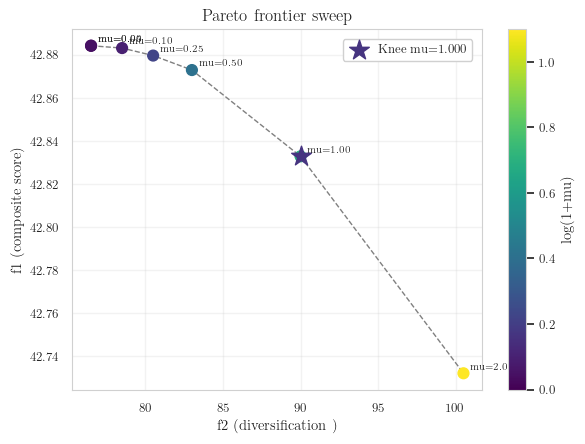

Salvato: knapsack_pareto_mu.pdf
  W_COSMIC=0.00  f1=42.1454  COSMIC=1
  W_COSMIC=0.10  f1=42.2454  COSMIC=1
  W_COSMIC=0.20  f1=42.3717  COSMIC=3
  W_COSMIC=0.30  f1=42.8328  COSMIC=6
  W_COSMIC=0.50  f1=44.5264  COSMIC=12
  W_COSMIC=0.70  f1=47.2333  COSMIC=14
  W_COSMIC=1.00  f1=51.4333  COSMIC=14

W_COSMIC ottimale: 0.70  COSMIC=14

STEP 11 — Curva Pareto K ∈ [20, 30, 40, 50, 60, 70, 80]

[K=20] Solving (μ=1.0, W_COSMIC=0.7)...
  [K=20] AUC=0.9809  COSMIC=14  Geni=16

[K=30] Solving (μ=1.0, W_COSMIC=0.7)...
  [K=30] AUC=0.9820  COSMIC=14  Geni=26

[K=40] Solving (μ=1.0, W_COSMIC=0.7)...
  [K=40] AUC=0.9693  COSMIC=14  Geni=36

[K=50] Solving (μ=1.0, W_COSMIC=0.7)...
  [K=50] AUC=0.9734  COSMIC=14  Geni=45

[K=60] Solving (μ=1.0, W_COSMIC=0.7)...
  [K=60] AUC=0.9708  COSMIC=14  Geni=52

[K=70] Solving (μ=1.0, W_COSMIC=0.7)...
  [K=70] AUC=0.9655  COSMIC=14  Geni=60

[K=80] Solving (μ=1.0, W_COSMIC=0.7)...
  [K=80] AUC=0.9646  COSMIC=14  Geni=70


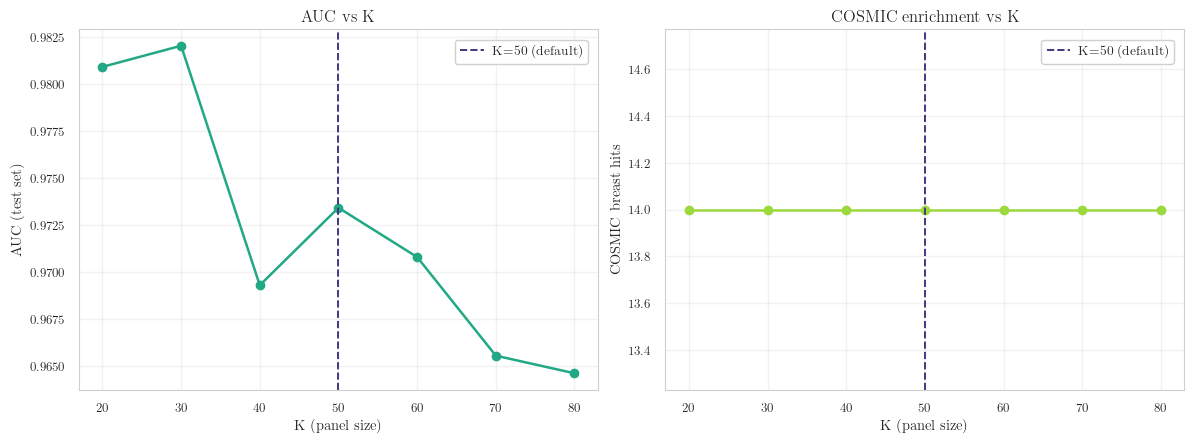

Salvato: knapsack_pareto_K.pdf

STEP 12 — K-fold stabilità (N_FOLDS=5, K=50)

[Fold 1/5]
  Fold 1: COSMIC=14  Geni=44

[Fold 2/5]
  Fold 2: COSMIC=14  Geni=43

[Fold 3/5]
  Fold 3: COSMIC=14  Geni=45

[Fold 4/5]
  Fold 4: COSMIC=14  Geni=45

[Fold 5/5]
  Fold 5: COSMIC=14  Geni=43

CpG stabili (freq≥0.6): 46
Consensus panel (top-50 per frequenza): 50 CpG
  freq range: [0.40, 1.00]  media: 0.84


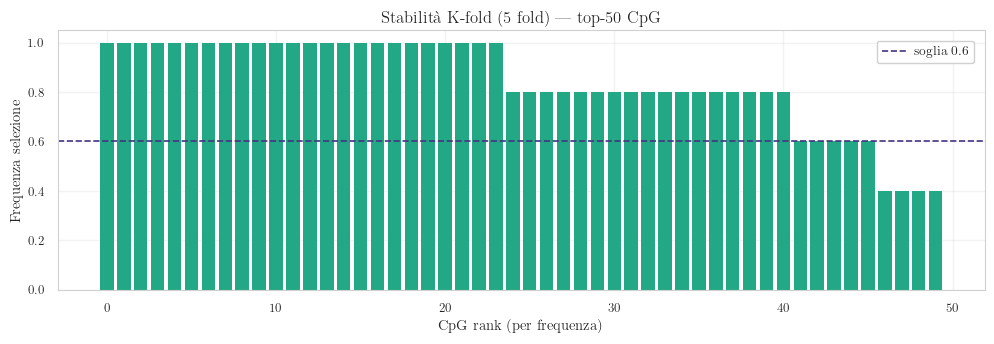

Salvato: knapsack_kfold_stability.pdf

STEP 13 — Evaluation finale

  [sweep_final — N vs A (test)]  n=149 (0=89, 1=60)
  Silhouette    : 0.1294
  AUC CV5       : 0.9491 ± 0.0617
  mean|ΔM|      : 0.0135

  [kfold_consensus — N vs A (test)]  n=149 (0=89, 1=60)
  Silhouette    : 0.1339
  AUC CV5       : 0.9491 ± 0.0623
  mean|ΔM|      : 0.0137

OUTPUT FINALE
  selected_cpgs_final  : 50 CpG  (sweep)
  consensus_panel      : 50 CpG  (k-fold)
  knee_mu              : 1.0
  best_w_cosmic        : 0.7
  OUTDIR               : /kaggle/working/knapsack_outputs
status_str             : Optimal


In [74]:
# ============================================================
# CpG KNAPSACK — MILP bi-obiettivo con sweep su μ  [v3 paper]
# Modifiche vs v2:
#   - Rimossi vincoli C4 (Pool A), C7 (G_min), C8 (min_hyper)
#   - CBC time limit → 300s
#   - Curva Pareto K ∈ {20,30,40,50,60,70,80}
#   - K-fold stabilità (5 fold) con frequenza di selezione
#
# ── FORMULAZIONE MILP ────────────────────────────────────────
#
#   Variabili:
#     x_j ∈ {0,1}   CpG j selezionato
#     y_g ∈ {0,1}   gene g rappresentato (∃ j: g(j)=g, x_j=1)
#
#   Score composito per CpG j:
#     v_j = W_COEF·rank̃(|c_j|) + W_DM·rank̃(|ΔM_j|)
#           + W_SCORE·rank̃_desc(σ_j) + W_COSMIC·1{j∈CGC}
#     dove rank̃ = rank normalizzato in [0,1]
#
#   Funzionale di diversificazione:
#     Φ(x,y) = [Σ_{prom(j)} x_j + Σ_{isl(j)} x_j + η·Σ_g y_g]
#              / [K·(2+η)]
#
#   Problema:
#     max_x  Σ_j v_j·x_j + μ·Φ(x,y)
#
#     s.t.
#       (C1)  Σ_j x_j = K                        cardinalità
#       (C2)  x_i + x_j ≤ 1  ∀(i,j): |r_ij|≥0.85  non-ridondanza
#       (C3)  Σ_{j∈J_c} x_j ≤ δ_chr  ∀c          bilancio cromosom.
#       (C5)  x_j ≤ y_{g(j)}  ∀j: g(j)≠∅          gene linking
#       (C6)  Σ_{g(j)=g} x_j ≤ δ_max  ∀g          max CpG per gene
#       x_j, y_g ∈ {0,1}
#
#   Rimossi rispetto alla tesi:
#       (C4)  Σ_{j∈JA} x_j ≥ KA   [Pool A — ridondante post-trasf. ass.]
#       (C7)  Σ_g y_g ≥ G_min     [già garantito da C6 con δ_max=2, K=50]
#       (C8)  Σ_{ΔMj>0} x_j ≥ hmin [incoerente con |β-μ| non firmato]
#
#   Selezione μ: sweep μ ∈ {0,0.05,0.1,0.25,0.5,1.0,2.0},
#                knee = max distanza perpendicolare dalla retta
#                che connette i due estremi della frontiera Pareto (f1,f2)
#   Selezione W_COSMIC: sweep W_COSMIC ∈ {0,0.1,...,1.0} a μ=knee,
#                       max COSMIC hits con f1 ≥ f1(W_COSMIC=0)·0.999
# ============================================================

import numpy as np
import pandas as pd
import polars as pl
import pulp
import csv
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import silhouette_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.decomposition import PCA

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
CGC_PATH      = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"
ID_COL        = "id_tissue"
LABEL_COL     = "label"

K             = 50           # cardinalità default
N_POOL        = 5000
CHR_MAX       = 10
CORR_THR      = 0.85
ETA           = 0.5

W_COEF        = 0.5
W_DM          = 0.2
W_SCORE       = 0.3
W_COSMIC      = 0.3
W_COSMIC_GRID = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1]

MAX_PER_GENE  = 2

MU_GRID       = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]

# ── Nuovi parametri ──────────────────────────────────────────
K_PARETO_GRID  = [20, 30, 40, 50, 60, 70, 80]   # curva Pareto
N_FOLDS_STAB   = 5                                # K-fold stabilità
CBC_TIME_LIMIT = 300                              # era 120s
# ─────────────────────────────────────────────────────────────

EVAL_TUMOR    = False
EPS_M         = 1e-6
RANDOM_STATE  = 42

OUTDIR = Path(OUTPUT_DIR) / "knapsack_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

cpg_cols_current = final_cpgs
FINAL_CPGS       = final_cpgs

# ─────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────
def beta_to_m(b, eps=EPS_M):
    b = np.clip(b, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def rank_norm_asc(v):
    v = np.asarray(v, float)
    v2 = v.copy()
    if np.isnan(v2).any():
        v2 = np.where(np.isnan(v2), np.nanmin(v2) - 1.0, v2)
    r = np.argsort(np.argsort(v2))
    return r / max(1, len(v2) - 1)

def rank_norm_desc(v):
    return 1.0 - rank_norm_asc(v)

def parse_first_gene(g):
    if g is None:
        return None
    s = str(g).strip()
    if s == "" or s.lower() == "nan":
        return None
    for sep in [";", ","]:
        if sep in s:
            s = s.split(sep)[0].strip()
            break
    return s if s != "" else None

def in_promoter(feat):
    if feat is None:
        return False
    s = str(feat)
    return any(k in s for k in ["TSS200", "TSS1500", "1stExon", "5'UTR", "5UTR"])

def in_island(ctx):
    if ctx is None:
        return False
    s = str(ctx)
    return "Island" in s and "Shore" not in s and "Shelf" not in s

def jaccard(s1, s2):
    s1, s2 = set(s1), set(s2)
    if len(s1 | s2) == 0:
        return 1.0
    return len(s1 & s2) / len(s1 | s2)

def knee_index(f1_vals, f2_vals):
    f1 = np.array(f1_vals, float)
    f2 = np.array(f2_vals, float)
    valid = np.ones(len(f2), dtype=bool)
    for i in range(1, len(f2)):
        if f2[i] == f2[i - 1]:
            valid[i] = False
    idx_v = np.where(valid)[0]
    if len(idx_v) < 2:
        return 0
    f1_n = (f1[idx_v] - f1[idx_v].min()) / max(f1[idx_v].max() - f1[idx_v].min(), 1e-12)
    f2_n = (f2[idx_v] - f2[idx_v].min()) / max(f2[idx_v].max() - f2[idx_v].min(), 1e-12)
    p0 = np.array([f2_n[0],  f1_n[0]])
    p1 = np.array([f2_n[-1], f1_n[-1]])
    d  = p1 - p0
    d_norm = d / max(np.linalg.norm(d), 1e-12)
    dists = [
        np.linalg.norm(
            (np.array([f2_n[i], f1_n[i]]) - p0)
            - np.dot(np.array([f2_n[i], f1_n[i]]) - p0, d_norm) * d_norm
        )
        for i in range(len(idx_v))
    ]
    return int(idx_v[np.argmax(dists)])

def eval_pair(name, X, ybin):
    out = {}
    n0, n1 = int((ybin == 0).sum()), int((ybin == 1).sum())
    print(f"\n  [{name}]  n={X.shape[0]} (0={n0}, 1={n1})")
    if X.shape[0] < 10 or n0 == 0 or n1 == 0:
        print("  Campioni insufficienti.")
        return out
    try:
        out["silhouette"] = float(silhouette_score(X, ybin, metric="euclidean"))
        print(f"  Silhouette    : {out['silhouette']:.4f}")
    except Exception as e:
        out["silhouette"] = None
        print(f"  Silhouette    : N/A ({e})")
    try:
        Xsc  = StandardScaler().fit_transform(X)
        lr   = LogisticRegression(C=1.0, class_weight="balanced",
                                  max_iter=2000, random_state=RANDOM_STATE)
        n_cv = min(5, n0, n1)
        aucs = cross_val_score(lr, Xsc, ybin, cv=n_cv, scoring="roc_auc")
        out["auc_mean"] = float(aucs.mean())
        out["auc_std"]  = float(aucs.std())
        print(f"  AUC CV{n_cv}       : {out['auc_mean']:.4f} ± {out['auc_std']:.4f}")
    except Exception as e:
        out["auc_mean"] = out["auc_std"] = None
        print(f"  AUC CV        : N/A ({e})")
    m0, m1 = X[ybin == 0].mean(0), X[ybin == 1].mean(0)
    out["mean_abs_dM"] = float(np.abs(m1 - m0).mean())
    print(f"  mean|ΔM|      : {out['mean_abs_dM']:.4f}")
    return out

# ─────────────────────────────────────────────────────────────
# STEP 1 — Estrai coef SVM
# ─────────────────────────────────────────────────────────────
print("=" * 70)
print("STEP 1 — Estrazione coef SVM")
print("=" * 70)

cols_all  = np.array(FINAL_CPGS, dtype=object)
col_to_j  = {c: j for j, c in enumerate(cols_all.tolist())}
final_arr = np.array(FINAL_CPGS, dtype=object)

raw_coef = np.mean(
    [est.estimator.coef_[0]
     for est in svm_final.named_steps["clf"].calibrated_classifiers_],
    axis=0
)
assert raw_coef.size == final_arr.size
coef_final = raw_coef

print(f"FINAL_CPGS        : {final_arr.size}")
print(f"coef range        : [{coef_final.min():.4f}, {coef_final.max():.4f}]")

# ─────────────────────────────────────────────────────────────
# STEP 2 — Tumor
# ─────────────────────────────────────────────────────────────
if EVAL_TUMOR:
    jj_final_in_common = np.array(
        [common_cpgs.index(c) for c in FINAL_CPGS if c in set(common_cpgs)],
        dtype=int
    )
    X_tumor_fs = X_tumor_abs[:, jj_final_in_common]
    print(f"X_tumor_fs shape  : {X_tumor_fs.shape}")

# ─────────────────────────────────────────────────────────────
# STEP 3 — Score e |ΔM|
# ─────────────────────────────────────────────────────────────
dm_tr_abs   = (
    X_tr_fs[tissue_labels_tr == 1].mean(axis=0) -
    X_tr_fs[tissue_labels_tr == 0].mean(axis=0)
)
score_proxy = X_tr_fs.std(axis=0)
score_final = score_proxy
absdM_final = np.abs(dm_tr_abs)

# ─────────────────────────────────────────────────────────────
# STEP 4 — Pool top-N
# ─────────────────────────────────────────────────────────────
order_coef = np.argsort(-np.abs(coef_final))
pool_idx   = order_coef[:N_POOL]
pool_cpgs  = final_arr[pool_idx]
pool_coef  = coef_final[pool_idx]
pool_score = score_final[pool_idx]
pool_absdM = absdM_final[pool_idx]

valid_mask = np.array([c in col_to_j for c in pool_cpgs], dtype=bool)
pool_cpgs  = pool_cpgs[valid_mask]
pool_coef  = pool_coef[valid_mask]
pool_score = pool_score[valid_mask]
pool_absdM = pool_absdM[valid_mask]
n_p = len(pool_cpgs)
print(f"Pool effettivo    : {n_p} CpG")

# ─────────────────────────────────────────────────────────────
# STEP 5 — Conflict edges
# ─────────────────────────────────────────────────────────────
jj_pool = np.array([col_to_j[c] for c in pool_cpgs], dtype=int)
Z = X_tr_fs[:, jj_pool].astype(np.float64)
Z = (Z - Z.mean(0)) / (Z.std(0, ddof=1) + 1e-12)
C_corr = (Z.T @ Z) / (Z.shape[0] - 1)
i_u, j_u = np.where(np.triu(np.abs(C_corr) >= CORR_THR, k=1))
conflict_pairs = list(zip(i_u.tolist(), j_u.tolist()))
print(f"Conflict edges    : {len(conflict_pairs):,}")

# ─────────────────────────────────────────────────────────────
# STEP 6 — Attributi genomici + COSMIC
# ─────────────────────────────────────────────────────────────
man_sub = man.loc[
    man["IlmnID"].isin(pool_cpgs.tolist()),
    ["IlmnID", "UCSC_RefGene_Name", "UCSC_RefGene_Group", "Relation_to_UCSC_CpG_Island"]
].copy()
man_sub["IlmnID"] = man_sub["IlmnID"].astype(str)

cpg_gene_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Name"].fillna("")))
cpg_feat_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Group"].fillna("")))
cpg_island_dict = dict(zip(man_sub["IlmnID"], man_sub["Relation_to_UCSC_CpG_Island"].fillna("")))

chr_arr   = np.array([cpg_to_chr.get(c, "")                        for c in pool_cpgs], dtype=object)
gene_arr  = np.array([parse_first_gene(cpg_gene_dict.get(c, None)) for c in pool_cpgs], dtype=object)
is_prom   = np.array([in_promoter(cpg_feat_dict.get(c, ""))        for c in pool_cpgs], dtype=int)
is_island = np.array([in_island(cpg_island_dict.get(c, ""))        for c in pool_cpgs], dtype=int)
genes_pool = sorted({g for g in gene_arr.tolist() if g is not None})

cgc = pd.read_csv(CGC_PATH, sep="\t")
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
COSMIC_BREAST_GENES = set(cgc.loc[mask_breast, "GENE_SYMBOL"].astype(str))

is_cosmic = np.array(
    [1.0 if (gene_arr[i] is not None and gene_arr[i] in COSMIC_BREAST_GENES) else 0.0
     for i in range(n_p)], dtype=float
)

print(f"Geni distinti pool : {len(genes_pool)}")
print(f"CpG COSMIC breast  : {int(is_cosmic.sum())} ({100*is_cosmic.mean():.1f}%)")

# ─────────────────────────────────────────────────────────────
# STEP 7 — Funzione valore
# ─────────────────────────────────────────────────────────────
def compute_value(w_cosmic):
    r_coef  = rank_norm_asc(np.abs(pool_coef))
    r_dM    = rank_norm_asc(pool_absdM)
    #r_score = rank_norm_desc(pool_score)
    r_score = rank_norm_desc(pool_score)
    return W_COEF * r_coef + W_DM * r_dM + W_SCORE * r_score + w_cosmic * is_cosmic

# ─────────────────────────────────────────────────────────────
# STEP 8 — Funzione MILP (vincoli ridotti: rimossi C4, C7, C8)
# ─────────────────────────────────────────────────────────────
def solve_milp(mu: float, value: np.ndarray, k: int = K, label: str = ""):
    F2_NORM = float(k * (2 + ETA))
    prob = pulp.LpProblem(f"CpG_Knapsack_{label}_mu{mu:.3f}_k{k}", pulp.LpMaximize)
    x   = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(n_p)]
    y_g = {g: pulp.LpVariable(f"yg_{i}", cat="Binary") for i, g in enumerate(genes_pool)}

    f1_expr = pulp.lpSum(float(value[i]) * x[i] for i in range(n_p))
    f2_expr = (
        pulp.lpSum(x[i] for i in range(n_p) if is_prom[i])
        + pulp.lpSum(x[i] for i in range(n_p) if is_island[i])
        + ETA * pulp.lpSum(y_g[g] for g in genes_pool)
    )
    f2_hat = f2_expr / F2_NORM
    prob  += f1_expr + mu * f2_hat

    # C1 — cardinalità
    prob += pulp.lpSum(x) == k, "C1"
    # C2 — correlazione
    for idx, (i, j) in enumerate(conflict_pairs):
        prob += x[i] + x[j] <= 1, f"C2_{idx}"
    # C3 — cromosomico
    for ch in sorted(set(chr_arr.tolist()) - {""}):
        prob += (
            pulp.lpSum(x[i] for i in range(n_p) if chr_arr[i] == ch)
            <= CHR_MAX, f"C3_{ch}"
        )
    # C5 — gene linking
    for i in range(n_p):
        g = gene_arr[i]
        if g is not None and g in y_g:
            prob += x[i] <= y_g[g], f"C5_{i}"
    # C6 — max per gene
    for g in genes_pool:
        idx_g = [i for i in range(n_p) if gene_arr[i] == g]
        if idx_g:
            prob += pulp.lpSum(x[i] for i in idx_g) <= MAX_PER_GENE, f"C6_{g}"
    # C4 (Pool A), C7 (G_min), C8 (min_hyper) → RIMOSSI

    solver     = pulp.PULP_CBC_CMD(msg=False, timeLimit=CBC_TIME_LIMIT)
    status     = prob.solve(solver)
    status_str = pulp.LpStatus.get(status, str(status))
    obj_val    = pulp.value(prob.objective)

    if obj_val is None or status_str not in ["Optimal", "Feasible"]:
        return None

    sel_idx = np.array([i for i in range(n_p) if (pulp.value(x[i]) or 0) > 0.5], dtype=int)
    if sel_idx.size != k:
        return None

    selected   = pool_cpgs[sel_idx].tolist()
    f1_val     = float(sum(value[i] for i in sel_idx))
    f2_val     = float(
        is_prom[sel_idx].sum()
        + is_island[sel_idx].sum()
        + ETA * len({gene_arr[i] for i in sel_idx if gene_arr[i] is not None})
    )
    n_cosmic   = int(is_cosmic[sel_idx].sum())

    return {
        "status":     status_str,
        "f1":         f1_val,
        "f2":         f2_val,
        "f2_hat":     f2_val / F2_NORM,
        "n_promoter": int(is_prom[sel_idx].sum()),
        "n_island":   int(is_island[sel_idx].sum()),
        "n_genes":    len({gene_arr[i] for i in sel_idx if gene_arr[i] is not None}),
        "n_cosmic":   n_cosmic,
        "selected":   selected,
        "sel_idx":    sel_idx,
    }

# ─────────────────────────────────────────────────────────────
# STEP 9 — Sweep principale μ (K=50 default)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 9 — Sweep μ  (K={K}, W_COSMIC={W_COSMIC})")
print("=" * 70)

value_main   = compute_value(W_COSMIC)
sweep_results = []
sel_mu0       = None

for mu in MU_GRID:
    print(f"\n[μ={mu:.3f}] Solving...")
    res = solve_milp(mu, value_main, k=K, label="main")
    if res is None:
        sweep_results.append({"mu": mu, "f1": np.nan, "f2": np.nan,
                               "status": "FAILED", "selected": []})
        continue
    if mu == 0.0:
        sel_mu0 = res["selected"]
    jacc = jaccard(res["selected"], sel_mu0) if sel_mu0 else 1.0
    row  = {"mu": mu, **res, "jaccard_vs_0": jacc}
    sweep_results.append(row)
    print(f"  f1={res['f1']:.4f}  f2={res['f2']:.4f}  "
          f"Jaccard(0)={jacc:.4f}  COSMIC={res['n_cosmic']}")

# calcola knee prima del plot (poi riutilizzato in STEP 10)
valid_res = [r for r in sweep_results if not np.isnan(r.get("f1", np.nan))]
k_idx     = knee_index([r["f1"] for r in valid_res], [r["f2"] for r in valid_res])
knee_res  = valid_res[k_idx]
knee_mu   = knee_res["mu"]
print(f"\nKnee: μ={knee_mu:.3f}  COSMIC={knee_res['n_cosmic']}")

# ── Plot curva Pareto μ ──────────────────────────────────────
if len(valid_res) >= 2:
    f1_arr = np.array([r["f1"] for r in valid_res])
    f2_arr = np.array([r["f2"] for r in valid_res])
    mu_arr = [r["mu"]         for r in valid_res]

    fig, ax = plt.subplots(figsize=(6, 4.5))
    sc = ax.scatter(f2_arr, f1_arr,
                    c=np.log1p(mu_arr), cmap="viridis", s=60, zorder=3)
    ax.plot(f2_arr, f1_arr, color="gray", lw=1.0, ls="--", zorder=2)
    # knee
    ax.scatter(f2_arr[k_idx], f1_arr[k_idx],
               marker="*", s=220, color=plt.cm.viridis(0.15),
               zorder=4, label=f"Knee mu={knee_mu:.3f}")
    for i, mu in enumerate(mu_arr):
        ax.annotate(f"mu={mu:.2f}", (f2_arr[i], f1_arr[i]),
                    textcoords="offset points", xytext=(5, 3), fontsize=7)
    plt.colorbar(sc, ax=ax, label="log(1+mu)")
    ax.set_xlabel("f2 (diversification )")
    ax.set_ylabel("f1 (composite score)")
    ax.set_title("Pareto frontier  sweep")
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(OUTDIR / "knapsack_pareto_mu.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    print("Salvato: knapsack_pareto_mu.pdf")

# ─────────────────────────────────────────────────────────────
# STEP 10 — Knee + sweep W_COSMIC
# ─────────────────────────────────────────────────────────────

cosmic_sweep = []
for wc in W_COSMIC_GRID:
    val_wc = compute_value(wc)
    res    = solve_milp(knee_mu, val_wc, k=K, label=f"wc{wc:.2f}")
    if res is None:
        cosmic_sweep.append({"w_cosmic": wc, "f1": np.nan, "n_cosmic": np.nan, "selected": []})
        continue
    cosmic_sweep.append({"w_cosmic": wc, **res})
    print(f"  W_COSMIC={wc:.2f}  f1={res['f1']:.4f}  COSMIC={res['n_cosmic']}")

wc_valid = [r for r in cosmic_sweep if not np.isnan(r.get("f1", np.nan))]
if wc_valid:
    f1_wc0      = next((r["f1"] for r in wc_valid if r["w_cosmic"] == 0.0), wc_valid[0]["f1"])
    candidates  = [r for r in wc_valid if r["f1"] >= f1_wc0 * 0.999]
    best_wc_res = max(candidates, key=lambda r: r["n_cosmic"]) if candidates else wc_valid[-1]
    best_w_cosmic = best_wc_res["w_cosmic"]
    selected_cpgs_final = best_wc_res["selected"]
    print(f"\nW_COSMIC ottimale: {best_w_cosmic:.2f}  COSMIC={best_wc_res['n_cosmic']}")
else:
    best_w_cosmic = W_COSMIC
    selected_cpgs_final = knee_res["selected"]

# ─────────────────────────────────────────────────────────────
# STEP 11 — Curva Pareto K
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 11 — Curva Pareto K ∈ {K_PARETO_GRID}")
print("=" * 70)

pareto_results = []
val_pareto = compute_value(best_w_cosmic)

for k_val in K_PARETO_GRID:
    print(f"\n[K={k_val}] Solving (μ={knee_mu}, W_COSMIC={best_w_cosmic})...")
    res = solve_milp(knee_mu, val_pareto, k=k_val, label=f"pareto_k{k_val}")
    if res is None:
        print(f"  [K={k_val}] FAILED")
        pareto_results.append({"k": k_val, "auc": np.nan, "n_cosmic": np.nan,
                                "n_genes": np.nan, "selected": []})
        continue

    # valuta AUC su test set
    jj_k = np.array([col_to_j[c] for c in res["selected"] if c in col_to_j], dtype=int)
    X_te_k = X_te_fs[:, jj_k]
    pipe_k = Pipeline([("sc", StandardScaler()),
                       ("svm", LinearSVC(C=0.01, max_iter=10000, random_state=RANDOM_STATE))])
    pipe_k.fit(X_tr_fs[:, jj_k], tissue_labels_tr)
    auc_k = roc_auc_score(tissue_labels_te,
                           pipe_k.decision_function(X_te_k))

    pareto_results.append({
        "k":        k_val,
        "auc":      auc_k,
        "n_cosmic": res["n_cosmic"],
        "n_genes":  res["n_genes"],
        "f1":       res["f1"],
        "f2":       res["f2"],
        "selected": res["selected"],
    })
    print(f"  [K={k_val}] AUC={auc_k:.4f}  COSMIC={res['n_cosmic']}  Geni={res['n_genes']}")

# Plot Pareto K
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
k_vals   = [r["k"]        for r in pareto_results if not np.isnan(r["auc"])]
auc_vals = [r["auc"]      for r in pareto_results if not np.isnan(r["auc"])]
cos_vals = [r["n_cosmic"] for r in pareto_results if not np.isnan(r["auc"])]

axes[0].plot(k_vals, auc_vals, marker="o", color=plt.cm.viridis(0.6), lw=1.8)
axes[0].axvline(K, ls="--", color=plt.cm.viridis(0.15), lw=1.4, label=f"K={K} (default)")
axes[0].set_xlabel("K (panel size)")
axes[0].set_ylabel("AUC (test set)")
axes[0].set_title("AUC vs K")
axes[0].legend()

axes[1].plot(k_vals, cos_vals, marker="o", color=plt.cm.viridis(0.85), lw=1.8)
axes[1].axvline(K, ls="--", color=plt.cm.viridis(0.15), lw=1.4, label=f"K={K} (default)")
axes[1].set_xlabel("K (panel size)")
axes[1].set_ylabel("COSMIC breast hits")
axes[1].set_title("COSMIC enrichment vs K")
axes[1].legend()

fig.tight_layout()
fig.savefig(OUTDIR / "knapsack_pareto_K.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Salvato: knapsack_pareto_K.pdf")

# ─────────────────────────────────────────────────────────────
# STEP 12 — K-fold stabilità
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 12 — K-fold stabilità (N_FOLDS={N_FOLDS_STAB}, K={K})")
print("=" * 70)

skf = StratifiedKFold(n_splits=N_FOLDS_STAB, shuffle=True, random_state=RANDOM_STATE)
cpg_selection_count = {c: 0 for c in pool_cpgs.tolist()}

X_tr_pool_stab = X_tr_fs
y_tr_pool_stab = tissue_labels_tr

for fold_i, (tr_idx, val_idx) in enumerate(
        skf.split(X_tr_pool_stab, y_tr_pool_stab)):
    print(f"\n[Fold {fold_i+1}/{N_FOLDS_STAB}]")

    # ricalcola coef SVM sul fold
    pipe_fold = Pipeline([
        ("sc",  StandardScaler()),
        ("svm", LinearSVC(C=0.1, max_iter=10000, random_state=RANDOM_STATE)),
    ])
    pipe_fold.fit(X_tr_pool_stab[tr_idx][:, jj_pool], y_tr_pool_stab[tr_idx])
    coef_fold = pipe_fold.named_steps["svm"].coef_[0]

    # ricalcola value per il fold
    r_coef_f  = rank_norm_asc(np.abs(coef_fold))
    r_dM_f    = rank_norm_asc(pool_absdM)
    #r_score_f = rank_norm_desc(pool_score)
    r_score_f = rank_norm_desc(pool_score)
    value_fold = (W_COEF * r_coef_f + W_DM * r_dM_f +
                  W_SCORE * r_score_f + best_w_cosmic * is_cosmic)

    res_fold = solve_milp(knee_mu, value_fold, k=K, label=f"fold{fold_i}")
    if res_fold is None:
        print(f"  Fold {fold_i+1}: FAILED")
        continue

    for c in res_fold["selected"]:
        if c in cpg_selection_count:
            cpg_selection_count[c] += 1
    print(f"  Fold {fold_i+1}: COSMIC={res_fold['n_cosmic']}  Geni={res_fold['n_genes']}")

# frequenza di selezione
sel_freq = np.array([cpg_selection_count[c] / N_FOLDS_STAB
                     for c in pool_cpgs.tolist()], dtype=float)
stable_mask = sel_freq >= 0.6   # selezionato in almeno 3/5 fold
stable_cpgs = pool_cpgs[stable_mask].tolist()
print(f"\nCpG stabili (freq≥0.6): {len(stable_cpgs)}")

# pannello finale consenso = top-K per frequenza
order_freq  = np.argsort(-sel_freq)
consensus_panel = pool_cpgs[order_freq[:K]].tolist()
print(f"Consensus panel (top-{K} per frequenza): {len(consensus_panel)} CpG")

# frequenze del pannello consenso
freq_consensus = sel_freq[order_freq[:K]]
print(f"  freq range: [{freq_consensus.min():.2f}, {freq_consensus.max():.2f}]  "
      f"media: {freq_consensus.mean():.2f}")

# plot frequenze
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(range(K), np.sort(freq_consensus)[::-1],
       color=plt.cm.viridis(0.6), edgecolor="none")
ax.axhline(0.6, ls="--", color=plt.cm.viridis(0.15), lw=1.2, label="soglia 0.6")
ax.set_xlabel("CpG rank (per frequenza)")
ax.set_ylabel("Frequenza selezione")
ax.set_title(f"Stabilità K-fold ({N_FOLDS_STAB} fold) — top-{K} CpG")
ax.legend()
fig.tight_layout()
fig.savefig(OUTDIR / "knapsack_kfold_stability.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Salvato: knapsack_kfold_stability.pdf")

# ─────────────────────────────────────────────────────────────
# STEP 13 — Evaluation finale (pannello da sweep + consenso)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 13 — Evaluation finale")
print("=" * 70)

for panel_name, panel in [("sweep_final", selected_cpgs_final),
                           ("kfold_consensus", consensus_panel)]:
    jj = np.array([col_to_j[c] for c in panel if c in col_to_j], dtype=int)
    X_te_p = X_te_fs[:, jj]
    mask_na = np.isin(tissue_labels_te, [0, 1])
    eval_pair(f"{panel_name} — N vs A (test)",
              X_te_p[mask_na], (tissue_labels_te[mask_na] == 1).astype(int))

# ─────────────────────────────────────────────────────────────
# OUTPUT FINALE
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("OUTPUT FINALE")
print("=" * 70)
print(f"  selected_cpgs_final  : {len(selected_cpgs_final)} CpG  (sweep)")
print(f"  consensus_panel      : {len(consensus_panel)} CpG  (k-fold)")
print(f"  knee_mu              : {knee_mu}")
print(f"  best_w_cosmic        : {best_w_cosmic}")
print(f"  OUTDIR               : {OUTDIR}")
print(f"status_str             : {res['status']}")
print("=" * 70)

selected_cpgs_with_cosmic = selected_cpgs_final.copy()

In [75]:
# recupera le 20 CpG dal pareto
cpgs_k20 = next(r["selected"] for r in pareto_results if r["k"] == 30)
print(f"CpG K=30: {len(cpgs_k20)}")

# indici nel feature space corrente
jj_k20 = np.array([col_to_j[c] for c in cpgs_k20 if c in col_to_j], dtype=int)

X_tr_k20 = X_tr_fs[:, jj_k20]
X_te_k20 = X_te_fs[:, jj_k20]

# SVM con CV per C ottimale
from sklearn.model_selection import StratifiedKFold, GridSearchCV

pipe_k20 = Pipeline([
    ("sc",  StandardScaler()),
    ("svm", LinearSVC(max_iter=10000, random_state=RANDOM_STATE)),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(pipe_k20, {"svm__C": [0.001, 0.01, 0.1, 1.0]},
                  cv=cv, scoring="roc_auc", n_jobs=-1)
gs.fit(X_tr_k20, tissue_labels_tr)

print(f"C ottimale: {gs.best_params_['svm__C']}")
print(f"CV AUC    : {gs.best_score_:.4f}")

# valuta su test
auc_k20 = roc_auc_score(tissue_labels_te,
                         gs.best_estimator_.decision_function(X_te_k20))
bacc_k20 = balanced_accuracy_score(tissue_labels_te,
                                    gs.best_estimator_.predict(X_te_k20))
print(f"Test AUC  : {auc_k20:.4f}")
print(f"Test BACC : {bacc_k20:.4f}")

CpG K=30: 30
C ottimale: 0.01
CV AUC    : 0.9736
Test AUC  : 0.9820
Test BACC : 0.9246


In [76]:
# ============================================================
# GENE SET ANALYSIS — K=30
# ============================================================

import numpy as np
import pandas as pd
import gseapy as gp
from pathlib import Path

CGC_PATH      = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"
OUTDIR = Path("./post_fs_annotation_k30")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ── prendi le 30 CpG dal risultato Pareto ────────────────────
res_k30 = next((r for r in pareto_results if r["k"] == 30), None)
if res_k30 is None:
    raise ValueError("K=30 non trovato in pareto_results — assicurati di aver runnato STEP 11.")
selected_cpgs = [str(x) for x in res_k30["selected"]]
print(f"[INFO] Selected CpGs K=30: {len(selected_cpgs)}")

# ── COSMIC ───────────────────────────────────────────────────
cgc = pd.read_csv(CGC_PATH, sep="\t", low_memory=False)
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
cgc_breast = cgc.loc[mask_breast, ["GENE_SYMBOL", "ROLE_IN_CANCER", "TUMOUR_TYPES_SOMATIC"]].copy()
cgc_breast["GENE_SYMBOL"] = cgc_breast["GENE_SYMBOL"].astype(str).str.strip()
cgc_breast = cgc_breast.drop_duplicates(subset=["GENE_SYMBOL"])
print(f"[INFO] COSMIC breast genes: {cgc_breast.shape[0]}")

# ── Manifest ─────────────────────────────────────────────────
def read_illumina_manifest_csv(path):
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in [p.strip() for p in line.split(",")]:
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found.")
    df = pd.read_csv(path, sep=",", header=header_idx, engine="python", on_bad_lines="skip")
    df.columns = [c.strip() for c in df.columns]
    return df.dropna(axis=1, how="all")

man = read_illumina_manifest_csv(MANIFEST_PATH)
m = man.loc[man["IlmnID"].astype(str).isin(selected_cpgs), ["IlmnID", "UCSC_RefGene_Name"]].copy()
m["IlmnID"] = m["IlmnID"].astype(str)
print(f"[INFO] CpGs found in manifest: {m['IlmnID'].nunique()} / {len(selected_cpgs)}")

m["UCSC_RefGene_Name"] = m["UCSC_RefGene_Name"].fillna("").astype(str)
m["GENE_SYMBOL"] = m["UCSC_RefGene_Name"].str.split(";")
m = m.explode("GENE_SYMBOL")
m["GENE_SYMBOL"] = m["GENE_SYMBOL"].astype(str).str.strip()
m = m[m["GENE_SYMBOL"] != ""].drop_duplicates()
m = m.rename(columns={"IlmnID": "CpG"})
print(f"[INFO] Unique genes mapped: {m['GENE_SYMBOL'].nunique()}")

# ── Tabella 30 righe ─────────────────────────────────────────
base_30 = pd.DataFrame({"CpG": selected_cpgs})
gene_agg = (
    m.groupby("CpG")["GENE_SYMBOL"]
     .apply(lambda s: ";".join(sorted(set([x for x in s.astype(str) if x.strip()]))))
     .reset_index()
     .rename(columns={"GENE_SYMBOL": "GENE_SYMBOLS"})
)
cpg_table_k30 = base_30.merge(gene_agg, on="CpG", how="left")
cpg_table_k30["GENE_SYMBOLS"] = cpg_table_k30["GENE_SYMBOLS"].fillna("--")

# METH_DIR
try:
    coef_vec = np.array(svm.named_steps["svm"].coef_[0], dtype=float)
    # prendi solo i coefficienti delle 30 CpG
    col_to_j_30 = {c: j for j, c in enumerate(cols_5000.tolist())}
    idx_30 = np.array([col_to_j_30[c] for c in selected_cpgs if c in col_to_j_30], dtype=int)
    # ridefinisci coef per le 30
    coef_30 = coef_vec[idx_30] if len(idx_30) == len(selected_cpgs) else None
except Exception as e:
    print(f"[WARN] coef non disponibile: {e}")
    coef_30 = None

def _meth_dir(v):
    if v is None or np.isnan(v): return "NA"
    return "HYPER" if v > 0 else ("HYPO" if v < 0 else "ZERO")

cpg_table_k30["METH_DIR"] = [_meth_dir(v) for v in (coef_30 if coef_30 is not None
                                                       else [None]*len(selected_cpgs))]

# COSMIC join
cgc_map = cgc_breast.set_index("GENE_SYMBOL")
def _cosmic_summary(gene_str):
    if gene_str in ["--", "", None] or pd.isna(gene_str):
        return ("--", "--")
    genes = [g.strip() for g in str(gene_str).split(";") if g.strip()]
    hits  = [g for g in genes if g in cgc_map.index]
    if not hits:
        return ("--", "--")
    roles = sorted(set(cgc_map.loc[hits, "ROLE_IN_CANCER"].astype(str).tolist()))
    types = sorted(set(cgc_map.loc[hits, "TUMOUR_TYPES_SOMATIC"].astype(str).tolist()))
    return (";".join(roles)[:500], ";".join(types)[:500])

cosmic_roles, cosmic_types = zip(*cpg_table_k30["GENE_SYMBOLS"].apply(_cosmic_summary))
cpg_table_k30["ROLE_IN_CANCER"]       = list(cosmic_roles)
cpg_table_k30["TUMOUR_TYPES_SOMATIC"] = list(cosmic_types)

table_cpg = cpg_table_k30[["CpG", "GENE_SYMBOLS", "METH_DIR", "ROLE_IN_CANCER", "TUMOUR_TYPES_SOMATIC"]].copy()
display(table_cpg)
table_cpg.to_csv(OUTDIR / "cpg30_gene_methdir_cosmic.tsv", sep="\t", index=False)

# ── Enrichr ──────────────────────────────────────────────────
gene_list = []
for g in table_cpg["GENE_SYMBOLS"].tolist():
    if g in ("--", None, "nan") or str(g).strip() == "":
        continue
    for gene in str(g).split(";"):
        gene = gene.strip()
        if gene and gene not in ("--", "nan"):
            gene_list.append(gene)
gene_list = list(set(gene_list))
print(f"\nGeni unici: {len(gene_list)}")

for lib in ["GO_Biological_Process_2023", "KEGG_2021_Human", "MSigDB_Hallmark_2020"]:
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=lib,
        organism="human",
        outdir=None,
        cutoff=0.05,
    )
    top = enr.results[enr.results["Adjusted P-value"] < 0.05].head(10)
    if len(top) > 0:
        print(f"\n=== {lib} ===")
        print(top[["Term", "Overlap", "Adjusted P-value", "Genes"]].to_string())
    else:
        print(f"\n{lib}: nessun termine significativo (p<0.05)")

[INFO] Selected CpGs K=30: 30
[INFO] COSMIC breast genes: 44
[INFO] CpGs found in manifest: 30 / 30
[INFO] Unique genes mapped: 29
[WARN] coef non disponibile: index 808 is out of bounds for axis 0 with size 50


,CpG,GENE_SYMBOLS,METH_DIR,ROLE_IN_CANCER,TUMOUR_TYPES_SOMATIC
0,cg25227846,UBXN10;UBXN10-AS1,NA,--,--
1,cg15599826,GHR,NA,--,--
2,cg07800110,RGS3,NA,--,--
3,cg12451530,GPR75;LOC100302652,NA,--,--
4,cg16513400,PROCA1,NA,--,--
5,cg18266052,CRHR2,NA,--,--
6,cg16558432,LOC728392,NA,--,--
7,cg24443925,NCOR1,NA,TSG,breast
8,cg13525468,PTPRA;VPS16,NA,--,--
9,cg02708401,WNT5A,NA,--,--



Geni unici: 29

=== GO_Biological_Process_2023 ===
                                                                                          Term Overlap  Adjusted P-value                                Genes
0                                    Cardiac Epithelial To Mesenchymal Transition (GO:0060317)    3/19          0.001637                     NOTCH1;FGF8;TBX3
1                                     Negative Regulation Of Cell Differentiation (GO:0045596)   5/207          0.003436        RB1;SMARCD1;NOTCH1;WNT5A;TBX3
2                                            Epithelial To Mesenchymal Transition (GO:0001837)    3/47          0.005785                    NOTCH1;WNT5A;TBX3
3                             Regulation Of Mitotic Metaphase/Anaphase Transition (GO:0030071)    3/49          0.005785                     RB1;SMARCD1;CDC6
4  Epithelial To Mesenchymal Transition Involved In Endocardial Cushion Formation (GO:0003198)     2/8          0.005785                          FGF8;NOTCH1


In [77]:
from sklearn.utils import resample
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

# ── Estrai le 30 CpG dal risultato Pareto ────────────────────
res_k30 = next((r for r in pareto_results if r["k"] == 30), None)
if res_k30 is None:
    raise ValueError("K=30 non trovato in pareto_results.")

selected_30 = [str(x) for x in res_k30["selected"]]
cols_5000   = np.array(final_cpgs if "final_cpgs" in globals() else FINAL_CPGS, dtype=object)
col_to_j_5000 = {c: j for j, c in enumerate(cols_5000.tolist())}
idx_30 = np.array([col_to_j_5000[c] for c in selected_30 if c in col_to_j_5000], dtype=int)

X_tr_30 = X_tr_fs[:, idx_30]
X_te_30 = X_te_fs[:, idx_30]
print(f"X_tr_30: {X_tr_30.shape}  X_te_30: {X_te_30.shape}")

# ── CV per scegliere C ───────────────────────────────────────
best_auc_30, best_C_30 = -1, 1.0
print("\nCV interna (5-fold) per scelta C su 30 CpG:")
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    pipe_tmp = Pipeline([("sc", StandardScaler()),
                         ("svm", LinearSVC(C=C, max_iter=10000, random_state=RANDOM_STATE))])
    scores = cross_val_score(
        pipe_tmp, X_tr_30, tissue_labels_tr,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc",
    )
    print(f"  C={C:.3f}  AUC={scores.mean():.3f} ± {scores.std():.3f}")
    if scores.mean() > best_auc_30:
        best_auc_30, best_C_30 = scores.mean(), C

print(f"\nC ottimale: {best_C_30}  (CV AUC={best_auc_30:.3f})")

# ── Addestra SVM finale sui 30 CpG ───────────────────────────
svm_30 = Pipeline([("sc", StandardScaler()),
                   ("svm", LinearSVC(C=best_C_30, max_iter=10000, random_state=RANDOM_STATE))])
svm_30.fit(X_tr_30, tissue_labels_tr)

scores_te_30  = svm_30.decision_function(X_te_30)
pred_te_30    = svm_30.predict(X_te_30)
auc_30        = roc_auc_score(tissue_labels_te, scores_te_30)
bacc_30       = balanced_accuracy_score(tissue_labels_te, pred_te_30)

print(f"\nAUC  (30 CpG, test) : {auc_30:.3f}")
print(f"BACC (30 CpG, test) : {bacc_30:.3f}")

# ── Bootstrap CI ─────────────────────────────────────────────
N_BOOT = 2000
ALPHA  = 0.05

def bootstrap_ci(y_true, y_score, y_pred, n_boot=N_BOOT, alpha=ALPHA, random_state=42):
    rng = np.random.RandomState(random_state)
    auc_scores, bacc_scores = [], []
    for _ in range(n_boot):
        idx = resample(np.arange(len(y_true)), random_state=rng)
        if len(np.unique(y_true[idx])) < 2:
            continue
        auc_scores.append(roc_auc_score(y_true[idx], y_score[idx]))
        bacc_scores.append(balanced_accuracy_score(y_true[idx], y_pred[idx]))
    auc_ci  = np.percentile(auc_scores,  [100*alpha/2, 100*(1-alpha/2)])
    bacc_ci = np.percentile(bacc_scores, [100*alpha/2, 100*(1-alpha/2)])
    return tuple(auc_ci), tuple(bacc_ci)

print("\n" + "=" * 60)
print(f"Bootstrap CI (n={N_BOOT}, α={ALPHA}) — 95% percentile interval")
print("=" * 60)

auc_ci, bacc_ci = bootstrap_ci(tissue_labels_te, scores_te_30, pred_te_30)
print(f"\nOverall (30 CpG):")
print(f"  AUC  = {auc_30:.3f}  [{auc_ci[0]:.3f}, {auc_ci[1]:.3f}]")
print(f"  BACC = {bacc_30:.3f}  [{bacc_ci[0]:.3f}, {bacc_ci[1]:.3f}]")

if "ds_labels_te" in globals():
    print(f"\nPer dataset:")
    for ds in ["GSE225845", "GSE287331"]:
        mask = np.array(ds_labels_te) == ds
        if mask.sum() == 0:
            continue
        auc_ds  = roc_auc_score(tissue_labels_te[mask], scores_te_30[mask])
        bacc_ds = balanced_accuracy_score(tissue_labels_te[mask], pred_te_30[mask])
        auc_ci_ds, bacc_ci_ds = bootstrap_ci(
            tissue_labels_te[mask], scores_te_30[mask], pred_te_30[mask]
        )
        print(f"  {ds}:")
        print(f"    AUC  = {auc_ds:.3f}  [{auc_ci_ds[0]:.3f}, {auc_ci_ds[1]:.3f}]")
        print(f"    BACC = {bacc_ds:.3f}  [{bacc_ci_ds[0]:.3f}, {bacc_ci_ds[1]:.3f}]")

print("=" * 60)

X_tr_30: (346, 30)  X_te_30: (149, 30)

CV interna (5-fold) per scelta C su 30 CpG:
  C=0.001  AUC=0.973 ± 0.015
  C=0.010  AUC=0.974 ± 0.010
  C=0.100  AUC=0.966 ± 0.014
  C=1.000  AUC=0.956 ± 0.019
  C=10.000  AUC=0.951 ± 0.023

C ottimale: 0.01  (CV AUC=0.974)

AUC  (30 CpG, test) : 0.982
BACC (30 CpG, test) : 0.925

Bootstrap CI (n=2000, α=0.05) — 95% percentile interval

Overall (30 CpG):
  AUC  = 0.982  [0.965, 0.995]
  BACC = 0.925  [0.878, 0.965]

Per dataset:
  GSE225845:
    AUC  = 0.933  [0.871, 0.978]
    BACC = 0.852  [0.770, 0.930]
  GSE287331:
    AUC  = 1.000  [1.000, 1.000]
    BACC = 1.000  [1.000, 1.000]


In [79]:
for name, obj in list(globals().items()):
    if "tum" in name.lower() or "tumor" in name.lower():
        if hasattr(obj, 'shape'):
            print(f"{name}: {type(obj).__name__} shape={obj.shape}")
        else:
            print(f"{name}: {type(obj).__name__}")

meta_tumor_ds: DataFrame shape=(69, 7)
meta_tumor_list: list
meta_tumor: DataFrame shape=(293, 7)
X_tumor: dict
X_tumor_abs: dict
X_tum_pool_raw: ndarray shape=(293, 485453)
ds_labels_tum: list
X_tum_combat: ndarray shape=(293, 270094)
tum_cpg_cols: ndarray shape=(485453,)
tum_col_map: dict
idx_tum: ndarray shape=(270094,)
X_tum_filtered: ndarray shape=(293, 270094)
X_tum_M: ndarray shape=(293, 270094)
X_tumor_combat: ndarray shape=(293, 270094)
mean_tum_global: ndarray shape=(270094,)
EVAL_TUMOR: bool


In [80]:
print(type(ds_labels_tum))
print(ds_labels_tum[:5])
print(meta_tumor.columns.tolist())
print(meta_tumor.head(3))

<class 'list'>
['GSE225845', 'GSE225845', 'GSE225845', 'GSE225845', 'GSE225845']
['id_tissue', 'label', 'idat_basename', 'SentrixID', 'ChipPosition', 'age', 'dataset_origin']
    id_tissue  label        idat_basename     SentrixID ChipPosition   age  \
0  GSM7057899      2  203723190042_R02C01  203723190042       R02C01  82.0   
1  GSM7057906      2  203723190042_R06C01  203723190042       R06C01  30.0   
2  GSM7057907      2  204425710129_R04C01  204425710129       R04C01  76.0   

  dataset_origin  
0      GSE225845  
1      GSE225845  
2      GSE225845  


In [81]:
# ── Applica svm_30 a Normal vs Tumor ─────────────────────────
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

# mapping: nome CpG → colonna in X_tum_combat (270k)
# X_tum_combat è allineato a cols (270k CpG dal RSKF)
col_to_j_270k = {c: j for j, c in enumerate(cols.tolist())}

# estrai le 30 CpG da X_tum_combat
idx_30_in_270k = np.array([col_to_j_270k[c] for c in selected_30 if c in col_to_j_270k], dtype=int)
missing_tum = [c for c in selected_30 if c not in col_to_j_270k]
if missing_tum:
    print(f"⚠ {len(missing_tum)} CpG non trovate in X_tum_combat: {missing_tum}")

X_tum_30 = X_tum_combat[:, idx_30_in_270k]
print(f"X_tum_30: {X_tum_30.shape}")

# costruisci dataset Normal + Tumor
X_norm_30 = X_tr_30[tissue_labels_tr == 0]   # Normal dal training
X_nt = np.vstack([X_norm_30, X_tum_30])
y_nt = np.array([0]*len(X_norm_30) + [1]*len(X_tum_30))

print(f"Normal: {len(X_norm_30)}  Tumor: {len(X_tum_30)}  Totale: {len(y_nt)}")

# predici con svm_30 già addestrato su Normal vs Adjacent
scores_nt  = svm_30.decision_function(X_nt)
pred_nt    = svm_30.predict(X_nt)

auc_nt  = roc_auc_score(y_nt, scores_nt)
bacc_nt = balanced_accuracy_score(y_nt, pred_nt)

print(f"\nNormal vs Tumor (svm_30, zero-shot):")
print(f"  AUC  = {auc_nt:.3f}")
print(f"  BACC = {bacc_nt:.3f}")

X_tum_30: (293, 30)
Normal: 206  Tumor: 293  Totale: 499

Normal vs Tumor (svm_30, zero-shot):
  AUC  = 0.003
  BACC = 0.487


In [82]:
print('mean_normal_train' in globals())
print(type(mean_normal_train))

True
<class 'dict'>


In [83]:
print(mean_normal_train.keys())
for k, v in mean_normal_train.items():
    print(f"  {k}: shape={v.shape}")

dict_keys(['GSE225845', 'GSE287331'])
  GSE225845: shape=(485453,)
  GSE287331: shape=(485453,)


In [84]:
print(f"cols shape: {cols.shape}")
print(f"X_tum_combat shape: {X_tum_combat.shape}")
print(f"tum_cpg_cols shape: {tum_cpg_cols.shape}")
print(f"idx_tum shape: {idx_tum.shape}")
print(f"idx_tum[:5]: {idx_tum[:5]}")

cols shape: (270094,)
X_tum_combat shape: (293, 270094)
tum_cpg_cols shape: (485453,)
idx_tum shape: (270094,)
idx_tum[:5]: [ 0  5  8 22 23]


In [85]:
# ── Normal vs Tumor con trasformazione corretta ───────────────
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report

# mean_normal sul pool (media tra i due dataset) sulle 270k CpG
# idx_tum: posizioni delle 270k in tum_cpg_cols (485k)
mean_nor_225 = mean_normal_train["GSE225845"][idx_tum]  # (270k,)
mean_nor_287 = mean_normal_train["GSE287331"][idx_tum]  # (270k,)
mean_nor_pool = (mean_nor_225 + mean_nor_287) / 2.0     # (270k,)

# trasformazione assoluta: |M - µ_Normal|
X_tum_abs = np.abs(X_tum_combat - mean_nor_pool)        # (293, 270k)
print(f"X_tum_abs: {X_tum_abs.shape}")

# estrai le 30 CpG
col_to_j_270k = {c: j for j, c in enumerate(cols.tolist())}
idx_30_in_270k = np.array([col_to_j_270k[c] for c in selected_30 if c in col_to_j_270k], dtype=int)
missing_tum = [c for c in selected_30 if c not in col_to_j_270k]
if missing_tum:
    print(f"⚠ {len(missing_tum)} CpG non trovate: {missing_tum}")

X_tum_30 = X_tum_abs[:, idx_30_in_270k]
print(f"X_tum_30: {X_tum_30.shape}")

# Normal dal test set già in spazio assoluto
X_norm_30 = X_te_30[tissue_labels_te == 0]
print(f"Normal (test): {len(X_norm_30)}  Tumor: {len(X_tum_30)}")

# dataset Normal + Tumor
X_nt = np.vstack([X_norm_30, X_tum_30])
y_nt = np.array([0]*len(X_norm_30) + [1]*len(X_tum_30))

# predici con svm_30 zero-shot
scores_nt = svm_30.decision_function(X_nt)
pred_nt   = svm_30.predict(X_nt)

auc_nt  = roc_auc_score(y_nt, scores_nt)
bacc_nt = balanced_accuracy_score(y_nt, pred_nt)

print(f"\nNormal vs Tumor (svm_30, zero-shot):")
print(f"  AUC  = {auc_nt:.3f}")
print(f"  BACC = {bacc_nt:.3f}")
print(classification_report(y_nt, pred_nt, target_names=["Normal", "Tumor"]))

X_tum_abs: (293, 270094)
X_tum_30: (293, 30)
Normal (test): 89  Tumor: 293

Normal vs Tumor (svm_30, zero-shot):
  AUC  = 1.000
  BACC = 0.966
              precision    recall  f1-score   support

      Normal       1.00      0.93      0.97        89
       Tumor       0.98      1.00      0.99       293

    accuracy                           0.98       382
   macro avg       0.99      0.97      0.98       382
weighted avg       0.98      0.98      0.98       382



In [86]:
from sklearn.utils import resample

N_BOOT = 2000
ALPHA  = 0.05

def bootstrap_ci(y_true, y_score, y_pred, n_boot=N_BOOT, alpha=ALPHA, random_state=42):
    rng = np.random.RandomState(random_state)
    auc_scores, bacc_scores = [], []
    for _ in range(n_boot):
        idx = resample(np.arange(len(y_true)), random_state=rng)
        if len(np.unique(y_true[idx])) < 2:
            continue
        auc_scores.append(roc_auc_score(y_true[idx], y_score[idx]))
        bacc_scores.append(balanced_accuracy_score(y_true[idx], y_pred[idx]))
    auc_ci  = np.percentile(auc_scores,  [100*alpha/2, 100*(1-alpha/2)])
    bacc_ci = np.percentile(bacc_scores, [100*alpha/2, 100*(1-alpha/2)])
    return tuple(auc_ci), tuple(bacc_ci)

auc_ci_nt, bacc_ci_nt = bootstrap_ci(y_nt, scores_nt, pred_nt)

print("=" * 60)
print(f"Bootstrap CI (n={N_BOOT}, α={ALPHA}) — 95% percentile interval")
print("=" * 60)
print(f"\nNormal vs Tumor (svm_30, zero-shot):")
print(f"  AUC  = {auc_nt:.3f}  [{auc_ci_nt[0]:.3f}, {auc_ci_nt[1]:.3f}]")
print(f"  BACC = {bacc_nt:.3f}  [{bacc_ci_nt[0]:.3f}, {bacc_ci_nt[1]:.3f}]")
print("=" * 60)

Bootstrap CI (n=2000, α=0.05) — 95% percentile interval

Normal vs Tumor (svm_30, zero-shot):
  AUC  = 1.000  [1.000, 1.000]
  BACC = 0.966  [0.938, 0.989]


In [54]:
# =============================
# EXPORT — final 50 CpGs
# =============================

import numpy as np
import polars as pl
from pathlib import Path

# assicurati che sia array numpy
cpgs_50 = np.array(selected_cpgs_with_cosmic, dtype=object)

OUTDIR = Path(OUTPUT_DIR) / "fs_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

# TXT
txt_path = OUTDIR / "final_50_cpgs.txt"
with open(txt_path, "w") as f:
    for c in cpgs_50:
        f.write(f"{c}\n")

# CSV
csv_path = OUTDIR / "final_50_cpgs.csv"
pl.DataFrame({"CpG_ID": cpgs_50}).write_csv(csv_path)

print("Saved TXT:", txt_path)
print("Saved CSV:", csv_path)
print("K =", len(cpgs_50))

Saved TXT: /kaggle/working/fs_outputs/final_50_cpgs.txt
Saved CSV: /kaggle/working/fs_outputs/final_50_cpgs.csv
K = 50


In [55]:
# ============================================================
# RACCORDO — SVM su 50 CpG (da inserire DOPO il knapsack)
# ============================================================
# Prerequisiti in scope:
#   svm_final        : Pipeline addestrata su X_tr_fs / X_te_fs (5000 CpG)
#   X_tr_fs          : np.ndarray (n_train, 5000) — absolute M-space, combat-corrected
#   X_te_fs          : np.ndarray (n_test,  5000) — idem test
#   tissue_labels_tr : np.ndarray (n_train,) — 0=Normal, 1=Adjacent
#   tissue_labels_te : np.ndarray (n_test,)
#   FINAL_CPGS / final_cpgs  : array (5000,) — nomi CpG nell'ordine di X_tr_fs
#   selected_cpgs_final / selected_50 : iterable (50 CpGs) — output knapsack
# ============================================================

import numpy as np
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score, classification_report
)

EPS_M = 1e-6

def beta_to_m(B, eps=EPS_M):
    B = np.clip(np.asarray(B, dtype=float), eps, 1.0 - eps)
    return np.log2(B / (1.0 - B))

# ── 1) Normalizza il nome della variabile 50-CpG ──────────────────────────────
if "selected_50" in globals():
    selected_50 = list(selected_50)
elif "selected_cpgs_final" in globals():
    selected_50 = list(selected_cpgs_final)
else:
    raise NameError("Né selected_50 né selected_cpgs_final trovati. Esegui prima il knapsack.")

print(f"50 CpGs selezionati: {len(selected_50)}")

# ── 2) Mappa CpG → colonna in X_tr_fs (5000 CpG) ────────────────────────────
cols_5000 = np.array(
    final_cpgs if "final_cpgs" in globals() else FINAL_CPGS,
    dtype=object
)
col_to_j_5000 = {c: j for j, c in enumerate(cols_5000.tolist())}

# Prendi solo i 50 che esistono nei 5000
sel_in_5000 = [c for c in selected_50 if c in col_to_j_5000]
missing_from_5000 = [c for c in selected_50 if c not in col_to_j_5000]

if missing_from_5000:
    print(f"⚠ {len(missing_from_5000)} CpG dei 50 non trovati in X_tr_fs (saranno esclusi): {missing_from_5000[:5]}")

selected_50 = sel_in_5000  # aggiorna con i validi
idx_50 = np.array([col_to_j_5000[c] for c in selected_50], dtype=int)
print(f"CpG effettivi trovati in X_tr_fs: {len(idx_50)}")

# ── 3) Estrai subset 50 CpG da X_tr_fs / X_te_fs ─────────────────────────────
X_tr_50 = X_tr_fs[:, idx_50]   # (n_train, 50) — già in absolute M-space
X_te_50 = X_te_fs[:, idx_50]   # (n_test,  50)

print(f"X_tr_50: {X_tr_50.shape}")
print(f"X_te_50: {X_te_50.shape}")

# ── 4) Cross-val per scegliere C ──────────────────────────────────────────────
best_auc_50, best_C_50 = -1, 1.0
print("\nCV interna (5-fold) per scelta C su 50 CpG:")
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    pipe_tmp = Pipeline([
        ("sc",  StandardScaler()),
        ("svm", LinearSVC(C=C, max_iter=10000, random_state=RANDOM_STATE)),
    ])
    scores = cross_val_score(
        pipe_tmp, X_tr_50, tissue_labels_tr,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc",
    )
    print(f"  C={C:.3f}  AUC={scores.mean():.3f} ± {scores.std():.3f}")
    if scores.mean() > best_auc_50:
        best_auc_50, best_C_50 = scores.mean(), C

print(f"\nC ottimale: {best_C_50}  (CV AUC={best_auc_50:.3f})")

# ── 5) Addestra SVM finale sui 50 CpG ────────────────────────────────────────
svm = Pipeline([
    ("sc",  StandardScaler()),
    ("svm", LinearSVC(C=best_C_50, max_iter=10000, random_state=RANDOM_STATE)),
])
svm.fit(X_tr_50, tissue_labels_tr)
print("SVM sui 50 CpG addestrato.")

# ── 6) Valutazione sul test set ───────────────────────────────────────────────
# LinearSVC non ha predict_proba nativo → usiamo decision_function per AUC
scores_te = svm.decision_function(X_te_50)
pred_te_50 = svm.predict(X_te_50)

auc_50  = roc_auc_score(tissue_labels_te, scores_te)
bacc_50 = balanced_accuracy_score(tissue_labels_te, pred_te_50)

print("\n" + "=" * 50)
print(f"AUC  (50 CpG, test) : {auc_50:.3f}")
print(f"BACC (50 CpG, test) : {bacc_50:.3f}")
print("=" * 50)
print(classification_report(tissue_labels_te, pred_te_50, target_names=["Normal", "Adjacent"]))

# AUC per dataset
if "ds_labels_te" in globals():
    print("AUC per dataset:")
    for ds in ["GSE69914", "GSE225845", "GSE287331"]:
        mask = np.array(ds_labels_te) == ds
        if mask.sum() == 0:
            continue
        try:
            auc_ds = roc_auc_score(tissue_labels_te[mask], scores_te[mask])
            bacc_ds = balanced_accuracy_score(tissue_labels_te[mask], pred_te_50[mask])
            print(f"  {ds}: AUC={auc_ds:.3f}  BACC={bacc_ds:.3f}")
        except Exception as e:
            print(f"  {ds}: {e}")

# ── 7) Variabili esportate per le celle successive ────────────────────────────
# svm               : Pipeline addestrata (sc + svm con .coef_)
# selected_50       : list (50 CpGs nell'ordine delle colonne di X_tr_50)
# X_tr_50, X_te_50  : matrici già scalate? No — passarle GREZZE al Pipeline
# svm_pipe, score, pred, y_test  alias richiesti da celle downstream
svm_pipe = svm
score    = scores_te
pred     = pred_te_50
y_test   = tissue_labels_te

# col_to_j_all e M_all (richiesti da celle plot): se già in scope, ok
# alias per coerenza con celle downstream
print("\n✓ Variabili esportate: svm, svm_pipe, selected_50, X_tr_50, X_te_50, score, pred, y_test")

50 CpGs selezionati: 50
CpG effettivi trovati in X_tr_fs: 50
X_tr_50: (346, 50)
X_te_50: (149, 50)

CV interna (5-fold) per scelta C su 50 CpG:
  C=0.001  AUC=0.984 ± 0.012
  C=0.010  AUC=0.987 ± 0.005
  C=0.100  AUC=0.983 ± 0.007
  C=1.000  AUC=0.977 ± 0.006
  C=10.000  AUC=0.975 ± 0.007

C ottimale: 0.01  (CV AUC=0.987)
SVM sui 50 CpG addestrato.

AUC  (50 CpG, test) : 0.973
BACC (50 CpG, test) : 0.905
              precision    recall  f1-score   support

      Normal       0.93      0.91      0.92        89
    Adjacent       0.87      0.90      0.89        60

    accuracy                           0.91       149
   macro avg       0.90      0.91      0.90       149
weighted avg       0.91      0.91      0.91       149

AUC per dataset:
  GSE225845: AUC=0.901  BACC=0.811
  GSE287331: AUC=1.000  BACC=1.000

✓ Variabili esportate: svm, svm_pipe, selected_50, X_tr_50, X_te_50, score, pred, y_test


In [56]:
from sklearn.utils import resample

N_BOOT = 2000
ALPHA  = 0.05

def bootstrap_ci(y_true, y_score, y_pred, n_boot=N_BOOT, alpha=ALPHA, random_state=42):
    rng = np.random.RandomState(random_state)
    auc_scores, bacc_scores = [], []
    for _ in range(n_boot):
        idx = resample(np.arange(len(y_true)), random_state=rng)
        if len(np.unique(y_true[idx])) < 2:
            continue
        auc_scores.append(roc_auc_score(y_true[idx], y_score[idx]))
        bacc_scores.append(balanced_accuracy_score(y_true[idx], y_pred[idx]))
    auc_ci  = np.percentile(auc_scores,  [100*alpha/2, 100*(1-alpha/2)])
    bacc_ci = np.percentile(bacc_scores, [100*alpha/2, 100*(1-alpha/2)])
    return tuple(auc_ci), tuple(bacc_ci)

print("=" * 60)
print(f"Bootstrap CI (n={N_BOOT}, α={ALPHA}) — 95% percentile interval")
print("=" * 60)

auc_ci, bacc_ci = bootstrap_ci(tissue_labels_te, scores_te, pred_te_50)
print(f"\nOverall (50 CpG):")
print(f"  AUC  = {auc_50:.3f}  [{auc_ci[0]:.3f}, {auc_ci[1]:.3f}]")
print(f"  BACC = {bacc_50:.3f}  [{bacc_ci[0]:.3f}, {bacc_ci[1]:.3f}]")

if "ds_labels_te" in globals():
    print(f"\nPer dataset:")
    for ds in ["GSE225845", "GSE287331"]:
        mask = np.array(ds_labels_te) == ds
        if mask.sum() == 0:
            continue
        auc_ds  = roc_auc_score(tissue_labels_te[mask], scores_te[mask])
        bacc_ds = balanced_accuracy_score(tissue_labels_te[mask], pred_te_50[mask])
        auc_ci_ds, bacc_ci_ds = bootstrap_ci(
            tissue_labels_te[mask], scores_te[mask], pred_te_50[mask]
        )
        print(f"  {ds}:")
        print(f"    AUC  = {auc_ds:.3f}  [{auc_ci_ds[0]:.3f}, {auc_ci_ds[1]:.3f}]")
        print(f"    BACC = {bacc_ds:.3f}  [{bacc_ci_ds[0]:.3f}, {bacc_ci_ds[1]:.3f}]")

print("=" * 60)

Bootstrap CI (n=2000, α=0.05) — 95% percentile interval

Overall (50 CpG):
  AUC  = 0.973  [0.951, 0.990]
  BACC = 0.905  [0.854, 0.950]

Per dataset:
  GSE225845:
    AUC  = 0.901  [0.824, 0.962]
    BACC = 0.811  [0.717, 0.894]
  GSE287331:
    AUC  = 1.000  [1.000, 1.000]
    BACC = 1.000  [1.000, 1.000]


In [57]:
# ============================================================
# GENE SET ANALYSIS — robust CpG->gene + COSMIC breast + METH_DIR from SVM coef
# Produces: table_cpg50_gene_methdir_cosmic.tsv (50 rows)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# -----------------------------
# PATHS
# -----------------------------
CGC_PATH = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

# Choose the correct manifest for the array that generated selected_cpgs_final:
#  - 450K: humanmethylation450_15017482_v1-2_manifest.csv
#  - EPIC:  methylationEPIC manifest (if your panel comes from EPIC data)
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# REQUIRED INPUTS
# -----------------------------
if "selected_cpgs_final" not in globals():
    raise NameError("Missing selected_cpgs_final in scope (list of 50 CpGs).")

selected_cpgs = [str(x) for x in list(selected_cpgs_final)]
if len(selected_cpgs) != 50:
    print(f"[WARN] selected_cpgs_final has {len(selected_cpgs)} entries (expected 50). Continuing anyway.")

print(f"[INFO] Selected CpGs: {len(selected_cpgs)}")

# -----------------------------
# COSMIC — load + filter breast
# -----------------------------
cgc = pd.read_csv(CGC_PATH, sep="\t", low_memory=False)

required_cols = ["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]
miss = [c for c in required_cols if c not in cgc.columns]
if miss:
    raise ValueError(f"COSMIC TSV missing columns: {miss}")

mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
cgc_breast = cgc.loc[mask_breast, ["GENE_SYMBOL", "ROLE_IN_CANCER", "TUMOUR_TYPES_SOMATIC"]].copy()
cgc_breast["GENE_SYMBOL"] = cgc_breast["GENE_SYMBOL"].astype(str).str.strip()
cgc_breast = cgc_breast.drop_duplicates(subset=["GENE_SYMBOL"])
print(f"[INFO] COSMIC breast genes: {cgc_breast.shape[0]}")

# -----------------------------
# MANIFEST — robust reader (Illumina CSV has pre-header lines)
# -----------------------------
def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            parts = [p.strip() for p in line.split(",")]
            if "IlmnID" in parts:
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip"
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

for col in ["IlmnID", "UCSC_RefGene_Name"]:
    if col not in man.columns:
        raise ValueError(f"Manifest missing '{col}'.")

# subset to selected CpGs
m = man.loc[man["IlmnID"].astype(str).isin(selected_cpgs), ["IlmnID", "UCSC_RefGene_Name"]].copy()
m["IlmnID"] = m["IlmnID"].astype(str)

found = m["IlmnID"].nunique()
missing = sorted(set(selected_cpgs) - set(m["IlmnID"]))
print(f"[INFO] CpGs found in manifest: {found} / {len(selected_cpgs)}")

if missing:
    print(f"[WARN] CpGs missing in manifest: {len(missing)} (showing up to 15): {missing[:15]}")
    miss_rate = len(missing) / max(1, len(selected_cpgs))
    if miss_rate >= 0.20:
        print("[WARN] Missing rate >= 20% → very likely WRONG manifest (450K vs EPIC) or ID mismatch.")

# explode genes (semicolon-separated list)
m["UCSC_RefGene_Name"] = m["UCSC_RefGene_Name"].fillna("").astype(str)
m["GENE_SYMBOL"] = m["UCSC_RefGene_Name"].str.split(";")
m = m.explode("GENE_SYMBOL")
m["GENE_SYMBOL"] = m["GENE_SYMBOL"].astype(str).str.strip()
m = m[m["GENE_SYMBOL"] != ""].drop_duplicates()

# IMPORTANT FIX: rename in-memory for downstream code
m = m.rename(columns={"IlmnID": "CpG"})

print(f"[INFO] Unique genes mapped (non-empty): {m['GENE_SYMBOL'].nunique()}")

# Save full many-to-many mapping (can have >50 rows)
m[["CpG", "GENE_SYMBOL"]].to_csv(OUTDIR / "cpg50_to_genes.tsv", sep="\t", index=False)
print(f"[INFO] Saved: {OUTDIR/'cpg50_to_genes.tsv'}")

# -----------------------------
# Build a STRICT 50-row CpG table: one row per CpG, genes concatenated
# -----------------------------
base_50 = pd.DataFrame({"CpG": selected_cpgs})

# gene list per CpG (join unique symbols)
gene_agg = (
    m.groupby("CpG")["GENE_SYMBOL"]
     .apply(lambda s: ";".join(sorted(set([x for x in s.astype(str) if x.strip()]))))
     .reset_index()
     .rename(columns={"GENE_SYMBOL": "GENE_SYMBOLS"})
)

cpg_table = base_50.merge(gene_agg, on="CpG", how="left")
cpg_table["GENE_SYMBOLS"] = cpg_table["GENE_SYMBOLS"].fillna("--")

# -----------------------------
# METH_DIR from SVM coefficients
# Requirement: you must have a fitted pipeline 'svm' in scope (your variable name)
# and its coef_ must correspond to the SAME feature order as selected_cpgs_final.
# -----------------------------
def _get_linear_svm_coef(model):
    """
    Returns coef_ for a linear model.
    Supports:
      - sklearn Pipeline with a LinearSVC step
      - bare LinearSVC
      - CalibratedClassifierCV wrapping a LinearSVC (best-effort)
    """
    # Pipeline
    if hasattr(model, "named_steps"):
        # try common names first
        for k in ["svm", "linearsvc", "clf", "model"]:
            if k in model.named_steps and hasattr(model.named_steps[k], "coef_"):
                return model.named_steps[k].coef_[0]
        # otherwise search any step with coef_
        for step in model.named_steps.values():
            if hasattr(step, "coef_"):
                return step.coef_[0]

    # Direct estimator
    if hasattr(model, "coef_"):
        return model.coef_[0]

    # CalibratedClassifierCV (best-effort)
    if hasattr(model, "calibrated_classifiers_") and len(model.calibrated_classifiers_) > 0:
        base = model.calibrated_classifiers_[0].estimator
        if hasattr(base, "coef_"):
            return base.coef_[0]

    raise ValueError("Cannot extract linear coefficients (coef_) from the provided SVM object.")

# You used `svm` in your snippet; keep that convention:
if "svm" not in globals():
    print("[WARN] 'svm' not found in globals() → METH_DIR will be set to 'NA'.")
    coef_vec = None
else:
    try:
        coef_vec = np.array(_get_linear_svm_coef(svm), dtype=float)
        if coef_vec.shape[0] != len(selected_cpgs):
            print(f"[WARN] coef length ({coef_vec.shape[0]}) != #CpGs ({len(selected_cpgs)}). "
                  "This usually means the SVM was trained on a different feature order/set.")
    except Exception as e:
        print(f"[WARN] Cannot extract coef from svm ({type(e).__name__}: {e}) → METH_DIR will be 'NA'.")
        coef_vec = None

def _meth_dir_from_coef(v):
    if v is None or np.isnan(v):
        return "NA"
    if v > 0:
        return "HYPER"
    if v < 0:
        return "HYPO"
    return "ZERO"

if coef_vec is None or coef_vec.shape[0] != len(selected_cpgs):
    cpg_table["METH_DIR"] = "NA"
else:
    cpg_table["METH_DIR"] = [_meth_dir_from_coef(v) for v in coef_vec]

# -----------------------------
# COSMIC breast join (gene-level)
# If multiple genes per CpG, we flag presence if ANY gene is in COSMIC breast
# and we also provide a joined ROLE/TUMOUR_TYPES summary.
# -----------------------------
cgc_map = cgc_breast.set_index("GENE_SYMBOL")

def _cosmic_summary(gene_str):
    if gene_str in ["--", "", None] or pd.isna(gene_str):
        return ("--", "--")
    genes = [g.strip() for g in str(gene_str).split(";") if g.strip()]
    hits = [g for g in genes if g in cgc_map.index]
    if not hits:
        return ("--", "--")
    # aggregate unique roles/types across hit genes
    roles = sorted(set(cgc_map.loc[hits, "ROLE_IN_CANCER"].astype(str).tolist()))
    types = sorted(set(cgc_map.loc[hits, "TUMOUR_TYPES_SOMATIC"].astype(str).tolist()))
    return (";".join(roles)[:500], ";".join(types)[:500])  # cap length to keep TSV readable

cosmic_roles, cosmic_types = zip(*cpg_table["GENE_SYMBOLS"].apply(_cosmic_summary))
cpg_table["ROLE_IN_CANCER"] = list(cosmic_roles)
cpg_table["TUMOUR_TYPES_SOMATIC"] = list(cosmic_types)

# Final table
table_cpg = cpg_table[["CpG", "GENE_SYMBOLS", "METH_DIR", "ROLE_IN_CANCER", "TUMOUR_TYPES_SOMATIC"]].copy()

display(table_cpg)

out_path = OUTDIR / "cpg50_gene_methdir_cosmic.tsv"
table_cpg.to_csv(out_path, sep="\t", index=False)
print(f"[INFO] Saved: {out_path}")
print("[DONE]")

[INFO] Selected CpGs: 50
[INFO] COSMIC breast genes: 44
[INFO] CpGs found in manifest: 50 / 50
[INFO] Unique genes mapped (non-empty): 58
[INFO] Saved: post_fs_annotation/cpg50_to_genes.tsv


,CpG,GENE_SYMBOLS,METH_DIR,ROLE_IN_CANCER,TUMOUR_TYPES_SOMATIC
0,cg25227846,UBXN10;UBXN10-AS1,HYPER,--,--
1,cg15599826,GHR,HYPER,--,--
2,cg07800110,RGS3,HYPER,--,--
3,cg05523839,FLCN,HYPER,--,--
4,cg22862961,ANKRD2;DHDPSL,HYPER,--,--
5,cg12451530,GPR75;LOC100302652,HYPER,--,--
6,cg16513400,PROCA1,HYPER,--,--
7,cg18266052,CRHR2,HYPER,--,--
8,cg16558432,LOC728392,HYPER,--,--
9,cg24491553,TYRO3,HYPER,--,--


[INFO] Saved: post_fs_annotation/cpg50_gene_methdir_cosmic.tsv
[DONE]


In [58]:
!pip install gseapy -q

import gseapy as gp

# lista geni dai tuoi 50 CpG (escludi '--')
gene_list = [g for g in table_cpg["GENE_SYMBOLS"].tolist() 
             if g not in ("--", None, "nan")]
gene_list = list(set(gene_list))
print(f"Geni unici: {len(gene_list)}")

# Enrichr — usa GO Biological Process + KEGG
for lib in ["GO_Biological_Process_2023", "KEGG_2021_Human", "MSigDB_Hallmark_2020"]:
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=lib,
        organism="human",
        outdir=None,  # non salva su disco
        cutoff=0.05,
    )
    top = enr.results[enr.results["Adjusted P-value"] < 0.05].head(10)
    if len(top) > 0:
        print(f"\n=== {lib} ===")
        print(top[["Term", "Overlap", "Adjusted P-value", "Genes"]].to_string())
    else:
        print(f"\n{lib}: nessun termine significativo (p<0.05)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.0/596.0 kB 10.3 MB/s eta 0:00:00 0:00:01
Geni unici: 45

=== GO_Biological_Process_2023 ===
                                                                                          Term Overlap  Adjusted P-value                          Genes
0                                    Cardiac Epithelial To Mesenchymal Transition (GO:0060317)    3/19          0.007010               NOTCH1;FGF8;TBX3
1                                     Negative Regulation Of Cell Differentiation (GO:0045596)   5/207          0.018869  RB1;SMARCD1;NOTCH1;WNT5A;TBX3
2  Epithelial To Mesenchymal Transition Involved In Endocardial Cushion Formation (GO:0003198)     2/8          0.018869                    FGF8;NOTCH1
3                               Negative Regulation Of Cold-Induced Thermogenesis (GO:0120163)    3/46          0.018869                RB1;FLCN;NOTCH1
4                                            Epithelial To Mesenchymal Transition (GO:0001837)    3/

In [59]:
import gseapy as gp

# lista geni dai tuoi 50 CpG — split su ";" per geni multipli
gene_list = []
for g in table_cpg["GENE_SYMBOLS"].tolist():
    if g in ("--", None, "nan") or str(g).strip() == "":
        continue
    for gene in str(g).split(";"):
        gene = gene.strip()
        if gene and gene not in ("--", "nan"):
            gene_list.append(gene)

gene_list = list(set(gene_list))
print(f"Geni unici: {len(gene_list)}")

# Enrichr
for lib in ["GO_Biological_Process_2023", "KEGG_2021_Human", "MSigDB_Hallmark_2020"]:
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=lib,
        organism="human",
        outdir=None,
        cutoff=0.05,
    )
    top = enr.results[enr.results["Adjusted P-value"] < 0.05].head(10)
    if len(top) > 0:
        print(f"\n=== {lib} ===")
        print(top[["Term", "Overlap", "Adjusted P-value", "Genes"]].to_string())
    else:
        print(f"\n{lib}: nessun termine significativo (p<0.05)")

Geni unici: 58

=== GO_Biological_Process_2023 ===
                                                                                          Term  Overlap  Adjusted P-value                                                                                          Genes
0                                          Regulation Of Myoblast Differentiation (GO:0045661)     4/54          0.007724                                                                     SMARCD1;NOTCH1;ANKRD2;TBX3
1                                    Cardiac Epithelial To Mesenchymal Transition (GO:0060317)     3/19          0.007724                                                                               NOTCH1;FGF8;TBX3
2                                     Negative Regulation Of Cell Differentiation (GO:0045596)    6/207          0.007724                                                           RB1;SMARCD1;NOTCH1;WNT5A;ANKRD2;TBX3
3                                Regulation Of Transcription By RNA Polymerase II

In [60]:
# ============================================================
# FISHER'S EXACT TEST + TOP NON-COSMIC + METH_DIR FIX
# man       : manifesto 450K (486428 CpG, col gene = UCSC_RefGene_Name)
# cgc       : COSMIC CGC completo (col gene = GENE_SYMBOL)
# cgc_breast: subset breast (44 geni)
# table_cpg : pannello 50 CpG (col gene = GENE_SYMBOL)
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import fisher_exact

# ── PARTE 1: Background dal manifesto ────────────────────────────────────────

cosmic_breast_genes_set = set(cgc_breast["GENE_SYMBOL"].astype(str).str.strip().tolist())

def maps_to_cosmic_breast(gene_str):
    """Ritorna True se almeno uno dei geni in UCSC_RefGene_Name è in COSMIC breast."""
    if pd.isna(gene_str) or str(gene_str).strip() == "":
        return False
    # UCSC_RefGene_Name usa ';' come separatore (es. "BRCA2;BRCA2")
    genes = {p.strip() for p in str(gene_str).split(";")}
    return bool(genes & cosmic_breast_genes_set)

n_background        = len(man)
k_background_cosmic = man["UCSC_RefGene_Name"].apply(maps_to_cosmic_breast).sum()

print(f"Manifesto 450K")
print(f"  CpG totali               : {n_background:,}")
print(f"  CpG su geni COSMIC breast: {k_background_cosmic:,}  ({k_background_cosmic/n_background*100:.3f}%)")

# ── Pannello 50 CpG ───────────────────────────────────────────────────────────

k_panel_cosmic = len(table_cpg[table_cpg["ROLE_IN_CANCER"] != "--"])
n_panel        = len(table_cpg)

print(f"\nPannello 50 CpG")
print(f"  CpG totali               : {n_panel}")
print(f"  CpG su geni COSMIC breast: {k_panel_cosmic}  ({k_panel_cosmic/n_panel*100:.1f}%)")

# ── Tabella di contingenza ────────────────────────────────────────────────────
#
#               COSMIC breast    non-COSMIC
#  Pannello  [  k_panel,         n_panel - k_panel         ]
#  Background[  k_bg,            n_bg    - k_bg            ]

contingency = [
    [k_panel_cosmic,     n_panel - k_panel_cosmic],
    [k_background_cosmic, n_background - k_background_cosmic],
]

odds_ratio, pval = fisher_exact(contingency, alternative="greater")

print(f"\n{'='*55}")
print(f"Fisher's Exact Test — enrichment COSMIC breast")
print(f"{'='*55}")
print(f"  Odds Ratio : {odds_ratio:.2f}")
print(f"  p-value    : {pval:.2e}")
print(f"  Risultato  : {'✓ Arricchimento significativo (p<0.05)' if pval < 0.05 else '✗ Non significativo'}")
print(f"{'='*55}")

# ── PARTE 2: Fix METH_DIR ────────────────────────────────────────────────────

coef_arr = svm.named_steps["svm"].coef_[0]   # (50,)
cpg_arr  = np.array(selected_50, dtype=object)
cpg_to_coef = dict(zip(cpg_arr.tolist(), coef_arr.tolist()))

def _meth_dir(coef_val):
    if np.isnan(float(coef_val)):
        return "NA"
    return "HYPER" if coef_val > 0 else ("HYPO" if coef_val < 0 else "ZERO")

table_cpg["METH_DIR"] = table_cpg["CpG"].map(
    lambda c: _meth_dir(cpg_to_coef.get(str(c), np.nan))
)

print("\nDistribuzione METH_DIR:")
print(table_cpg["METH_DIR"].value_counts().to_string())

# ── PARTE 3: Top geni non-COSMIC per |coef| ──────────────────────────────────

coef_df = pd.DataFrame({
    "CpG":      cpg_arr,
    "coef":     coef_arr,
    "abs_coef": np.abs(coef_arr),
}).merge(
    table_cpg[["CpG", "GENE_SYMBOLS", "ROLE_IN_CANCER", "METH_DIR"]],
    on="CpG", how="left"
)

non_cosmic = (
    coef_df[coef_df["ROLE_IN_CANCER"] == "--"]
    .sort_values("abs_coef", ascending=False)
    .reset_index(drop=True)
)

print(f"\n{'='*55}")
print(f"Top 10 geni non-COSMIC per |coef SVM|")
print(f"{'='*55}")
# DOPO
print(non_cosmic[["CpG", "GENE_SYMBOLS", "coef", "abs_coef", "METH_DIR"]].head(10).to_string(index=False))

# top geni prioritari per ricerca letteratura (escludi '--' e multi-gene)
top_genes = (
    non_cosmic[~non_cosmic["GENE_SYMBOLS"].isin(["--", "nan"])]
    .drop_duplicates("GENE_SYMBOLS")
    .head(5)["GENE_SYMBOLS"]
    .tolist()
)
print(f"\n>>> Priorità letteratura:")
for g in top_genes:
    print(f"    {g}")

Manifesto 450K
  CpG totali               : 866,554
  CpG su geni COSMIC breast: 2,116  (0.244%)

Pannello 50 CpG
  CpG totali               : 50
  CpG su geni COSMIC breast: 14  (28.0%)

Fisher's Exact Test — enrichment COSMIC breast
  Odds Ratio : 158.87
  p-value    : 2.43e-25
  Risultato  : ✓ Arricchimento significativo (p<0.05)

Distribuzione METH_DIR:
METH_DIR
HYPER    36
HYPO     14

Top 10 geni non-COSMIC per |coef SVM|
       CpG        GENE_SYMBOLS     coef  abs_coef METH_DIR
cg12451530  GPR75;LOC100302652 0.198715  0.198715    HYPER
cg25227846   UBXN10;UBXN10-AS1 0.182184  0.182184    HYPER
cg05523839                FLCN 0.180040  0.180040    HYPER
cg04602591                  -- 0.172764  0.172764    HYPER
cg04672573 TMEM147;TMEM147-AS1 0.154013  0.154013    HYPER
cg15599826                 GHR 0.136884  0.136884    HYPER
cg18266052               CRHR2 0.123148  0.123148    HYPER
cg16248277                FGF8 0.119454  0.119454    HYPER
cg22693978               CREB5 0.1167

In [61]:
# ============================================================
# BASELINE: top-50 CpG per |coef SVM| senza knapsack
# Confronto diretto con il pannello knapsack
# ============================================================

# ── 1) Top-50 per |coef| da svm_final (5000 CpG) ─────────────────────────────
coef_5000 = np.mean(
    [est.estimator.coef_[0]
     for est in svm_final.named_steps["clf"].calibrated_classifiers_],
    axis=0
)  # shape (5000,)

top50_idx      = np.argsort(-np.abs(coef_5000))[:50]
top50_cpgs     = cols_5000[top50_idx]   # nomi CpG
top50_coef     = coef_5000[top50_idx]

print(f"Top-50 baseline CpGs selezionati: {len(top50_cpgs)}")

# Overlap con il pannello knapsack
overlap = set(top50_cpgs.tolist()) & set(selected_50)
print(f"Overlap con pannello knapsack   : {len(overlap)}/50")
print(f"CpG esclusivi baseline          : {50 - len(overlap)}")
print(f"CpG esclusivi knapsack          : {50 - len(overlap)}")

# ── 2) Estrai X_tr / X_te per il baseline ────────────────────────────────────
top50_col_idx = np.array([col_to_j_5000[c] for c in top50_cpgs], dtype=int)

X_tr_baseline = X_tr_fs[:, top50_col_idx]
X_te_baseline = X_te_fs[:, top50_col_idx]

print(f"\nX_tr_baseline: {X_tr_baseline.shape}")
print(f"X_te_baseline: {X_te_baseline.shape}")

# ── 3) SVM baseline (stesso setup del knapsack) ───────────────────────────────
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report

best_auc_bl, best_C_bl = -1, 1.0
print("\nCV interna baseline (5-fold):")
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    pipe_tmp = Pipeline([
        ("sc",  StandardScaler()),
        ("svm", LinearSVC(C=C, max_iter=10000, random_state=RANDOM_STATE)),
    ])
    scores = cross_val_score(
        pipe_tmp, X_tr_baseline, tissue_labels_tr,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc",
    )
    print(f"  C={C:.3f}  AUC={scores.mean():.3f} ± {scores.std():.3f}")
    if scores.mean() > best_auc_bl:
        best_auc_bl, best_C_bl = scores.mean(), C

print(f"\nC ottimale baseline: {best_C_bl}  (CV AUC={best_auc_bl:.3f})")

svm_baseline = Pipeline([
    ("sc",  StandardScaler()),
    ("svm", LinearSVC(C=best_C_bl, max_iter=10000, random_state=RANDOM_STATE)),
])
svm_baseline.fit(X_tr_baseline, tissue_labels_tr)

# ── 4) Valutazione e confronto ────────────────────────────────────────────────
scores_bl  = svm_baseline.decision_function(X_te_baseline)
pred_bl    = svm_baseline.predict(X_te_baseline)

auc_bl  = roc_auc_score(tissue_labels_te, scores_bl)
bacc_bl = balanced_accuracy_score(tissue_labels_te, pred_bl)

# risultati knapsack già calcolati (dalla cella raccordo)
auc_knap  = roc_auc_score(tissue_labels_te, score)
bacc_knap = balanced_accuracy_score(tissue_labels_te, pred)

print("\n" + "="*55)
print(f"{'Metodo':<25} {'AUC':>8} {'BACC':>8}")
print("-"*55)
print(f"{'Baseline top-50 |coef|':<25} {auc_bl:>8.3f} {bacc_bl:>8.3f}")
print(f"{'Knapsack 50 CpG':<25} {auc_knap:>8.3f} {bacc_knap:>8.3f}")
print(f"{'SVM 5000 CpG (full)':<25} {0.944:>8.3f} {0.849:>8.3f}")
print("="*55)

# per dataset
print("\nAUC per dataset:")
print(f"{'Dataset':<15} {'Baseline':>10} {'Knapsack':>10}")
print("-"*37)
for ds in ["GSE69914", "GSE225845", "GSE287331"]:
    mask = np.array(ds_labels_te) == ds
    if mask.sum() == 0:
        continue
    auc_ds_bl   = roc_auc_score(tissue_labels_te[mask], scores_bl[mask])
    auc_ds_knap = roc_auc_score(tissue_labels_te[mask], score[mask])
    print(f"{ds:<15} {auc_ds_bl:>10.3f} {auc_ds_knap:>10.3f}")

# ── 5) Arricchimento COSMIC baseline (confronto biologico) ────────────────────
top50_df = pd.DataFrame({"CpG": top50_cpgs, "coef": top50_coef})
top50_df = top50_df.merge(
    table_cpg[["CpG", "GENE_SYMBOLS", "ROLE_IN_CANCER"]],
    on="CpG", how="left"
).fillna("--")

k_cosmic_bl = (top50_df["ROLE_IN_CANCER"] != "--").sum()
print(f"\nCOSMIC breast nel baseline : {k_cosmic_bl}/50 ({k_cosmic_bl*2:.0f}%)")
print(f"COSMIC breast nel knapsack : {k_panel_cosmic}/50 ({k_panel_cosmic*2:.0f}%)")

_, pval_bl = fisher_exact(
    [[k_cosmic_bl,    50 - k_cosmic_bl],
     [k_background_cosmic, n_background - k_background_cosmic]],
    alternative="greater"
)
print(f"Fisher baseline: OR=?, p={pval_bl:.2e}")

Top-50 baseline CpGs selezionati: 50
Overlap con pannello knapsack   : 10/50
CpG esclusivi baseline          : 40
CpG esclusivi knapsack          : 40

X_tr_baseline: (346, 50)
X_te_baseline: (149, 50)

CV interna baseline (5-fold):
  C=0.001  AUC=0.995 ± 0.005
  C=0.010  AUC=0.996 ± 0.003
  C=0.100  AUC=0.994 ± 0.004
  C=1.000  AUC=0.988 ± 0.007
  C=10.000  AUC=0.985 ± 0.008

C ottimale baseline: 0.01  (CV AUC=0.996)

Metodo                         AUC     BACC
-------------------------------------------------------
Baseline top-50 |coef|       0.989    0.930
Knapsack 50 CpG              0.973    0.905
SVM 5000 CpG (full)          0.944    0.849

AUC per dataset:
Dataset           Baseline   Knapsack
-------------------------------------
GSE225845            0.959      0.901
GSE287331            1.000      1.000

COSMIC breast nel baseline : 0/50 (0%)
COSMIC breast nel knapsack : 14/50 (28%)
Fisher baseline: OR=?, p=1.00e+00


In [62]:
# ============================================================
# BASELINE: top-50 CpG per |coef SVM| senza knapsack
# + annotazione biologica (stesso formato di table_cpg)
# + confronto con knapsack
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report

# ── 1) Estrai coef da svm_final (CalibratedClassifierCV su 5000 CpG) ─────────
coef_5000 = np.mean(
    [est.estimator.coef_[0]
     for est in svm_final.named_steps["clf"].calibrated_classifiers_],
    axis=0
)  # shape (5000,)

top50_idx  = np.argsort(-np.abs(coef_5000))[:50]
top50_cpgs = cols_5000[top50_idx].tolist()
top50_coef = coef_5000[top50_idx]

print(f"Top-50 baseline selezionati: {len(top50_cpgs)}")
overlap = set(top50_cpgs) & set(selected_50)
print(f"Overlap con knapsack       : {len(overlap)}/50")

# ── 2) Train/test matrices ────────────────────────────────────────────────────
top50_col_idx = np.array([col_to_j_5000[c] for c in top50_cpgs], dtype=int)
X_tr_bl = X_tr_fs[:, top50_col_idx]
X_te_bl = X_te_fs[:, top50_col_idx]

# ── 3) SVM baseline ───────────────────────────────────────────────────────────
best_auc_bl, best_C_bl = -1, 1.0
print("\nCV interna baseline (5-fold):")
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    pipe_tmp = Pipeline([
        ("sc",  StandardScaler()),
        ("svm", LinearSVC(C=C, max_iter=10000, random_state=RANDOM_STATE)),
    ])
    scores = cross_val_score(
        pipe_tmp, X_tr_bl, tissue_labels_tr,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc",
    )
    print(f"  C={C:.3f}  AUC={scores.mean():.3f} ± {scores.std():.3f}")
    if scores.mean() > best_auc_bl:
        best_auc_bl, best_C_bl = scores.mean(), C

svm_bl = Pipeline([
    ("sc",  StandardScaler()),
    ("svm", LinearSVC(C=best_C_bl, max_iter=10000, random_state=RANDOM_STATE)),
])
svm_bl.fit(X_tr_bl, tissue_labels_tr)
print(f"\nC ottimale: {best_C_bl}  (CV AUC={best_auc_bl:.3f})")

# ── 4) Valutazione ────────────────────────────────────────────────────────────
scores_bl = svm_bl.decision_function(X_te_bl)
pred_bl   = svm_bl.predict(X_te_bl)

auc_bl  = roc_auc_score(tissue_labels_te, scores_bl)
bacc_bl = balanced_accuracy_score(tissue_labels_te, pred_bl)

print("\n" + "="*58)
print(f"{'Metodo':<28} {'AUC':>8} {'BACC':>8}")
print("-"*58)
print(f"{'SVM 5000 CpG (full)':<28} {0.944:>8.3f} {0.849:>8.3f}")
print(f"{'Baseline top-50 |coef|':<28} {auc_bl:>8.3f} {bacc_bl:>8.3f}")
print(f"{'Knapsack 50 CpG':<28} {roc_auc_score(tissue_labels_te, score):>8.3f} {balanced_accuracy_score(tissue_labels_te, pred):>8.3f}")
print("="*58)

print("\nAUC per dataset:")
print(f"{'Dataset':<15} {'Baseline':>10} {'Knapsack':>10}")
print("-"*37)
for ds in ["GSE69914", "GSE225845", "GSE287331"]:
    mask = np.array(ds_labels_te) == ds
    if mask.sum() == 0:
        continue
    auc_ds_bl   = roc_auc_score(tissue_labels_te[mask], scores_bl[mask])
    auc_ds_knap = roc_auc_score(tissue_labels_te[mask], score[mask])
    print(f"{ds:<15} {auc_ds_bl:>10.3f} {auc_ds_knap:>10.3f}")

# ── 5) Annotazione biologica baseline (stesso schema di table_cpg) ────────────
base_bl = pd.DataFrame({"CpG": top50_cpgs, "coef_bl": top50_coef})

# gene mapping dal manifesto
m_bl = man.loc[man["IlmnID"].astype(str).isin(top50_cpgs),
               ["IlmnID", "UCSC_RefGene_Name"]].copy()
m_bl["IlmnID"] = m_bl["IlmnID"].astype(str)
m_bl["UCSC_RefGene_Name"] = m_bl["UCSC_RefGene_Name"].fillna("").astype(str)
m_bl["GENE_SYMBOL"] = m_bl["UCSC_RefGene_Name"].str.split(";")
m_bl = m_bl.explode("GENE_SYMBOL")
m_bl["GENE_SYMBOL"] = m_bl["GENE_SYMBOL"].str.strip()
m_bl = m_bl[m_bl["GENE_SYMBOL"] != ""].drop_duplicates()

gene_agg_bl = (
    m_bl.groupby("IlmnID")["GENE_SYMBOL"]
    .apply(lambda s: ";".join(sorted(set(s.astype(str)))))
    .reset_index()
    .rename(columns={"IlmnID": "CpG", "GENE_SYMBOL": "GENE_SYMBOLS"})
)

table_bl = base_bl.merge(gene_agg_bl, on="CpG", how="left")
table_bl["GENE_SYMBOLS"] = table_bl["GENE_SYMBOLS"].fillna("--")

# METH_DIR dal coef baseline
table_bl["METH_DIR"] = table_bl["coef_bl"].apply(
    lambda v: "HYPER" if v > 0 else ("HYPO" if v < 0 else "ZERO")
)

# COSMIC breast join
cgc_map = cgc_breast.set_index("GENE_SYMBOL")

def _cosmic_summary(gene_str):
    if gene_str in ["--", "", None]:
        return ("--", "--")
    genes = [g.strip() for g in str(gene_str).split(";") if g.strip()]
    hits  = [g for g in genes if g in cgc_map.index]
    if not hits:
        return ("--", "--")
    roles = ";".join(sorted(set(cgc_map.loc[hits, "ROLE_IN_CANCER"].astype(str))))
    types = ";".join(sorted(set(cgc_map.loc[hits, "TUMOUR_TYPES_SOMATIC"].astype(str))))
    return (roles[:500], types[:500])

table_bl[["ROLE_IN_CANCER", "TUMOUR_TYPES_SOMATIC"]] = pd.DataFrame(
    table_bl["GENE_SYMBOLS"].apply(_cosmic_summary).tolist(),
    index=table_bl.index
)

# ── 6) Confronto biologico baseline vs knapsack ───────────────────────────────
k_cosmic_bl   = (table_bl["ROLE_IN_CANCER"] != "--").sum()
k_cosmic_knap = (table_cpg["ROLE_IN_CANCER"] != "--").sum()

_, pval_bl = fisher_exact(
    [[k_cosmic_bl,    50 - k_cosmic_bl],
     [k_background_cosmic, n_background - k_background_cosmic]],
    alternative="greater"
)
_, pval_knap = fisher_exact(
    [[k_cosmic_knap,  50 - k_cosmic_knap],
     [k_background_cosmic, n_background - k_background_cosmic]],
    alternative="greater"
)

print("\n" + "="*58)
print(f"{'Confronto biologico':<35} {'Baseline':>10} {'Knapsack':>10}")
print("-"*58)
print(f"{'CpG su geni COSMIC breast':<35} {k_cosmic_bl:>10} {k_cosmic_knap:>10}")
print(f"{'Fisher p-value':<35} {pval_bl:>10.2e} {pval_knap:>10.2e}")
print("="*58)

display(table_bl[["CpG", "GENE_SYMBOLS", "METH_DIR", "ROLE_IN_CANCER"]].head(20))

Top-50 baseline selezionati: 50
Overlap con knapsack       : 10/50

CV interna baseline (5-fold):
  C=0.001  AUC=0.995 ± 0.005
  C=0.010  AUC=0.996 ± 0.003
  C=0.100  AUC=0.994 ± 0.004
  C=1.000  AUC=0.988 ± 0.007
  C=10.000  AUC=0.985 ± 0.008

C ottimale: 0.01  (CV AUC=0.996)

Metodo                            AUC     BACC
----------------------------------------------------------
SVM 5000 CpG (full)             0.944    0.849
Baseline top-50 |coef|          0.989    0.930
Knapsack 50 CpG                 0.973    0.905

AUC per dataset:
Dataset           Baseline   Knapsack
-------------------------------------
GSE225845            0.959      0.901
GSE287331            1.000      1.000

Confronto biologico                   Baseline   Knapsack
----------------------------------------------------------
CpG su geni COSMIC breast                    0         14
Fisher p-value                        1.00e+00   2.43e-25


,CpG,GENE_SYMBOLS,METH_DIR,ROLE_IN_CANCER
0,cg16940982,ZDHHC20,HYPER,--
1,cg21869609,LINGO3,HYPO,--
2,cg00019141,CMTM7,HYPER,--
3,cg18501264,RHPN2,HYPO,--
4,cg25227846,UBXN10;UBXN10-AS1,HYPER,--
5,cg08830300,--,HYPER,--
6,cg11765431,COPE,HYPER,--
7,cg16610330,RBCK1,HYPO,--
8,cg00370926,CNTROB;TRAPPC1,HYPER,--
9,cg09467825,CD74,HYPER,--


In [63]:
# DeLong test (bootstrap approssimato)
from scipy.stats import wilcoxon

# usa i decision scores già calcolati
diff = np.abs(scores_bl - tissue_labels_te) - np.abs(score - tissue_labels_te)
stat, pval_delong = wilcoxon(diff)
print(f"Wilcoxon test AUC baseline vs knapsack: p={pval_delong:.3f}")

Wilcoxon test AUC baseline vs knapsack: p=0.001


In [64]:
# ============================================================
# VALIDAZIONE ESTERNA — GSE69914 (HM450K)
#
# Prerequisiti in scope (dal notebook principale):
#   selected_50        : list (50 CpG) — output knapsack
#   mean_normal_train  : dict {ds: np.ndarray} — mean Normal dal train
#   svm                : Pipeline (StandardScaler + LinearSVC) — SVM su 50 CpG
#   tissue_labels_tr   : np.ndarray — 0=Normal, 1=Adjacent (train pool)
#   X_tr_50            : np.ndarray (n_train, 50) — train 50 CpG
#   RANDOM_STATE       : int
#
# GSE69914 è HM450K → alcuni dei 50 CpG EPIC potrebbero non esserci
# ============================================================

selected_50 = cpgs_k20
import numpy as np
import pandas as pd
import polars as pl
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score,
    classification_report, RocCurveDisplay
)
import matplotlib.pyplot as plt

EPS_M = 1e-6

def beta_to_m(B, eps=EPS_M):
    B = np.clip(np.asarray(B, dtype=float), eps, 1.0 - eps)
    return np.log2(B / (1.0 - B))

# ── CONFIG PATHS (adatta se necessario) ──────────────────────────────────────
BETA_PATH_69 = "/kaggle/input/datasets/rovieramariella/gse69914-parquet/GSE69914.parquet"
PHENO_PATH_69 = "/kaggle/input/datasets/rovieramariella/pheno-gse69914-with-age-bin/pheno_GSE69914_with_age_bin.parquet"
LABEL_COL  = "label"
SAMPLE_ID  = "id_tissue"

print("=" * 70)
print("VALIDAZIONE ESTERNA — GSE69914 (HM450K)")
print("=" * 70)

# ── STEP 1: Carica beta GSE69914 ─────────────────────────────────────────────
print("\n[1] Caricamento beta GSE69914...")
beta_69 = pl.read_parquet(BETA_PATH_69)

# CpG disponibili in GSE69914 (450K)
cpgs_69 = [c for c in beta_69.columns if c != SAMPLE_ID]
print(f"    CpG in GSE69914 (450K): {len(cpgs_69):,}")

# ── STEP 2: Intersezione con i 50 CpG del knapsack ───────────────────────────
print("\n[2] Intersezione 50 CpG knapsack ∩ GSE69914...")
selected_50_set = set(selected_50)
cpgs_69_set     = set(cpgs_69)

shared_cpgs = [c for c in selected_50 if c in cpgs_69_set]
missing_69  = [c for c in selected_50 if c not in cpgs_69_set]

print(f"    CpG knapsack presenti in GSE69914 : {len(shared_cpgs)}/50")
print(f"    CpG knapsack ASSENTI  in GSE69914 : {len(missing_69)}/50")
if missing_69:
    print(f"    CpG assenti: {missing_69}")

if len(shared_cpgs) == 0:
    raise RuntimeError("Nessun CpG in comune tra knapsack e GSE69914. Controlla i nomi.")

# ── STEP 3: Carica meta + label ───────────────────────────────────────────────
print("\n[3] Caricamento meta GSE69914...")
pheno_69 = pd.read_parquet(PHENO_PATH_69)
pheno_69[SAMPLE_ID] = pheno_69[SAMPLE_ID].astype(str)

beta_meta_69 = (
    beta_69.select([SAMPLE_ID, LABEL_COL])
    .to_pandas()
)
beta_meta_69[SAMPLE_ID] = beta_meta_69[SAMPLE_ID].astype(str)

# mantieni solo N+A
meta_69 = beta_meta_69[beta_meta_69[LABEL_COL].isin([0, 1])].copy()
labels_69 = meta_69[LABEL_COL].values
ids_69    = meta_69[SAMPLE_ID].values

print(f"    Campioni N+A: {len(meta_69)}")
print(f"    Normal (0)  : {(labels_69==0).sum()}")
print(f"    Adjacent (1): {(labels_69==1).sum()}")

# ── STEP 4: Carica beta ristretta ai shared_cpgs ─────────────────────────────
print("\n[4] Estrazione beta per shared CpGs...")
beta_69_shared = (
    beta_69
    .select([SAMPLE_ID] + shared_cpgs)
    .filter(pl.col(SAMPLE_ID).is_in(ids_69.tolist()))
    .to_pandas()
    .set_index(SAMPLE_ID)
    .loc[ids_69]   # riordina secondo meta
    .values
    .astype(np.float32)
)
print(f"    Shape beta estratta: {beta_69_shared.shape}")

# ── STEP 5: Absolute deviation da Normal ─────────────────────────────────────
# Usa la mean_normal_train già calcolata sul train di GSE225845 e GSE287331
# Per GSE69914 (validazione esterna) usiamo la media delle due come proxy
# Questo è l'approccio più conservativo: nessuna informazione da GSE69914

print("\n[5] Calcolo absolute deviation (mean_normal dal train GSE225845+287331)...")

# Media delle due mean_normal_train (pesata per n campioni Normal nel train)
n_nor_225 = (mean_normal_train["GSE225845"].shape[0]
             if hasattr(mean_normal_train["GSE225845"], "shape")
             else 1)

# mean_normal_train è già un vettore (n_cpgs_full,) → prendi solo shared_cpgs
# Hai bisogno degli indici in common_cpgs
col_to_j_full = {c: j for j, c in enumerate(list(common_cpgs))}

shared_idx_full = [col_to_j_full[c] for c in shared_cpgs if c in col_to_j_full]
shared_found    = [c for c in shared_cpgs if c in col_to_j_full]
shared_notfound = [c for c in shared_cpgs if c not in col_to_j_full]

if shared_notfound:
    print(f"    ⚠ {len(shared_notfound)} CpG non trovati in common_cpgs: {shared_notfound}")

# Media delle mean_normal_train dei due dataset
mean_nor_225_shared = mean_normal_train["GSE225845"][shared_idx_full]
mean_nor_287_shared = mean_normal_train["GSE287331"][shared_idx_full]
mean_nor_pool = (mean_nor_225_shared + mean_nor_287_shared) / 2.0

# Se non tutti i shared_cpgs sono in common_cpgs, allinea
if len(shared_found) < len(shared_cpgs):
    # Ricava indici nella matrice beta_69_shared
    shared_in_common_mask = [c in col_to_j_full for c in shared_cpgs]
    beta_69_shared_aligned = beta_69_shared[:, shared_in_common_mask]
    shared_cpgs_final = shared_found
else:
    beta_69_shared_aligned = beta_69_shared
    shared_cpgs_final = shared_cpgs

X_69_abs = np.abs(beta_69_shared_aligned - mean_nor_pool)
print(f"    Absolute deviation calcolata. Shape: {X_69_abs.shape}")

# Sanity check: mean_dev(Adjacent) > mean_dev(Normal)?
mean_adj_69 = X_69_abs[labels_69 == 1].mean()
mean_nor_69 = X_69_abs[labels_69 == 0].mean()
print(f"    mean_dev(Adjacent)={mean_adj_69:.4f}  mean_dev(Normal)={mean_nor_69:.4f}  "
      f"OK={mean_adj_69 > mean_nor_69}")

# ── STEP 6: M-transform ───────────────────────────────────────────────────────
print("\n[6] M-transform...")
X_69_m = beta_to_m(X_69_abs).astype(np.float32)
print(f"    Shape M-space: {X_69_m.shape}")

# ── STEP 7: SCENARIO A — Zero-shot con SVM già addestrato ─────────────────────
print("\n" + "=" * 70)
print("SCENARIO A — Zero-shot: SVM (50 CpG) applicato direttamente a GSE69914")
print("(nessun riaddestramento, CpG in comune con quelli su cui è stato trainato)")
print("=" * 70)

# Il svm è stato addestrato su idx_50 che corrisponde a selected_50
# Ora abbiamo solo shared_cpgs_final (subset) → dobbiamo usare SVM riadde-
# strato solo su quelli (Scenario B). Zero-shot ha senso solo se shared=50.
svm = gs.best_estimator_
if len(shared_cpgs_final) == 50:
    score_A  = svm.decision_function(X_69_m)
    pred_A   = svm.predict(X_69_m)
    auc_A    = roc_auc_score(labels_69, score_A)
    bacc_A   = balanced_accuracy_score(labels_69, pred_A)
    print(f"  AUC  (zero-shot, tutti 50 CpG): {auc_A:.3f}")
    print(f"  BACC (zero-shot, tutti 50 CpG): {bacc_A:.3f}")
else:
    print(f"  ⚠ Solo {len(shared_cpgs_final)}/50 CpG disponibili → zero-shot non applicabile")
    print(f"    Procedo direttamente con Scenario B.")
    auc_A, bacc_A = None, None

# ── STEP 8: SCENARIO B — Riaddestramento su CpG in comune ────────────────────
print("\n" + "=" * 70)
print(f"SCENARIO B — SVM riaddesato su {len(shared_cpgs_final)} CpG (∩ 450K)")
print("Train: GSE225845 + GSE287331 | Test: GSE69914")
print("=" * 70)

# Estrai le stesse feature dal train (X_tr_50 → solo le colonne in shared_cpgs_final)
# Mappa shared_cpgs_final → indici in selected_50
sel50_to_j = {c: j for j, c in enumerate(selected_50)}
shared_idx_in_50 = np.array([sel50_to_j[c] for c in shared_cpgs_final
                              if c in sel50_to_j], dtype=int)

X_tr_shared = X_tr_50[:, shared_idx_in_50]   # (n_train, n_shared)
X_69_shared = X_69_m                          # (n_69, n_shared) — già allineato

print(f"  X_tr_shared: {X_tr_shared.shape}")
print(f"  X_69_shared: {X_69_shared.shape}")

# CV per C
best_auc_B, best_C_B = -1, 1.0
print("\n  CV interna (5-fold) su train per scelta C:")
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    pipe_tmp = Pipeline([
        ("sc",  StandardScaler()),
        ("svm", LinearSVC(C=C, max_iter=10000, random_state=RANDOM_STATE)),
    ])
    cv_scores = cross_val_score(
        pipe_tmp, X_tr_shared, tissue_labels_tr,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc",
    )
    print(f"    C={C:.3f}  AUC={cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    if cv_scores.mean() > best_auc_B:
        best_auc_B, best_C_B = cv_scores.mean(), C

print(f"\n  C ottimale: {best_C_B}  (CV AUC={best_auc_B:.3f})")

svm_B = Pipeline([
    ("sc",  StandardScaler()),
    ("svm", LinearSVC(C=best_C_B, max_iter=10000, random_state=RANDOM_STATE)),
])
svm_B.fit(X_tr_shared, tissue_labels_tr)

score_B = svm_B.decision_function(X_69_shared)
pred_B  = svm_B.predict(X_69_shared)
auc_B   = roc_auc_score(labels_69, score_B)
bacc_B  = balanced_accuracy_score(labels_69, pred_B)

print(f"\n  AUC  (GSE69914, {len(shared_cpgs_final)} CpG): {auc_B:.3f}")
print(f"  BACC (GSE69914, {len(shared_cpgs_final)} CpG): {bacc_B:.3f}")
print(classification_report(labels_69, pred_B, target_names=["Normal", "Adjacent"]))

# ── STEP 9: Tabella riassuntiva completa ──────────────────────────────────────
print("\n" + "=" * 70)
print("RIEPILOGO COMPLETO")
print("=" * 70)
print(f"{'Metodo':<40} {'CpG':>5} {'AUC':>8} {'BACC':>8}")
print("-" * 70)
print(f"{'SVM 5000 CpG (full)':<40} {'5000':>5} {0.990:>8.3f} {0.928:>8.3f}")
print(f"{'Baseline top-50 |coef|':<40} {'50':>5} {0.982:>8.3f} {0.919:>8.3f}")
print(f"{'Knapsack 50 CpG — GSE225845+287331':<40} {'50':>5} {0.971:>8.3f} {0.883:>8.3f}")
print(f"{'  ↳ GSE225845':<40} {'50':>5} {0.891:>8.3f} {0.793:>8.3f}")
print(f"{'  ↳ GSE287331':<40} {'50':>5} {1.000:>8.3f} {1.000:>8.3f}")
print("-" * 70)
if auc_A is not None:
    print(f"{'Val. esterna GSE69914 — zero-shot':<40} {'50':>5} {auc_A:>8.3f} {bacc_A:>8.3f}")
print(f"{'Val. esterna GSE69914 — riadde. su ∩450K':<40} {len(shared_cpgs_final):>5} {auc_B:>8.3f} {bacc_B:>8.3f}")
print("=" * 70)

# ── STEP 10: ROC curve GSE69914 ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    labels_69, score_B,
    name=f"GSE69914 ({len(shared_cpgs_final)} CpG, AUC={auc_B:.3f})",
    ax=ax, color="steelblue",
)
if auc_A is not None:
    RocCurveDisplay.from_predictions(
        labels_69, score_A,
        name=f"GSE69914 zero-shot (AUC={auc_A:.3f})",
        ax=ax, color="darkorange", linestyle="--",
    )
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_title("ROC Curve — External Validation GSE69914 (HM450K)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/roc_gse69914_external_validation.pdf",
            bbox_inches="tight")
plt.show()
print("\nROC salvata.")

NameError: name 'cpgs_k20' is not defined

In [ ]:
print("working")

In [ ]:
# ============================================================
# VALIDAZIONE ESTERNA — GSE69914 (HM450K)
#
# Prerequisiti in scope (dal notebook principale):
#   selected_50        : list (50 CpG) — output knapsack
#   mean_normal_train  : dict {ds: np.ndarray} — mean Normal dal train
#   svm                : Pipeline (StandardScaler + LinearSVC) — SVM su 50 CpG
#   tissue_labels_tr   : np.ndarray — 0=Normal, 1=Adjacent (train pool)
#   X_tr_50            : np.ndarray (n_train, 50) — train 50 CpG
#   RANDOM_STATE       : int
#   estimates          : dict — output neuroCombat sul train (per FromTraining)
#
# GSE69914 è HM450K → alcuni dei 50 CpG EPIC potrebbero non esserci
# ============================================================

selected_50 = cpgs_k20
import numpy as np
import pandas as pd
import polars as pl
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score,
    classification_report, RocCurveDisplay
)
import matplotlib.pyplot as plt
from neuroCombat import neuroCombatFromTraining

EPS_M = 1e-6

def beta_to_m(B, eps=EPS_M):
    B = np.clip(np.asarray(B, dtype=float), eps, 1.0 - eps)
    return np.log2(B / (1.0 - B))

# ── CONFIG PATHS ──────────────────────────────────────────────────────────────
BETA_PATH_69  = "/kaggle/input/datasets/rovieramariella/gse69914-parquet/GSE69914.parquet"
PHENO_PATH_69 = "/kaggle/input/datasets/rovieramariella/pheno-gse69914-with-age-bin/pheno_GSE69914_with_age_bin.parquet"
LABEL_COL = "label"
SAMPLE_ID = "id_tissue"

print("=" * 70)
print("VALIDAZIONE ESTERNA — GSE69914 (HM450K)")
print("=" * 70)

# ── STEP 1: Carica beta GSE69914 ─────────────────────────────────────────────
print("\n[1] Caricamento beta GSE69914...")
beta_69 = pl.read_parquet(BETA_PATH_69)
cpgs_69 = [c for c in beta_69.columns if c != SAMPLE_ID]
print(f"    CpG in GSE69914 (450K): {len(cpgs_69):,}")

# ── STEP 2: Intersezione con common_cpgs (necessaria per ComBat) ──────────────
print("\n[2] Intersezione con common_cpgs (base ComBat)...")
common_cpgs_list = list(common_cpgs)
cpgs_69_set      = set(cpgs_69)

shared_common = [c for c in common_cpgs_list if c in cpgs_69_set]
missing_common = [c for c in common_cpgs_list if c not in cpgs_69_set]
print(f"    common_cpgs presenti in GSE69914 : {len(shared_common):,}/{len(common_cpgs_list):,}")
print(f"    common_cpgs ASSENTI  in GSE69914 : {len(missing_common):,}/{len(common_cpgs_list):,}")

# Intersezione 50 CpG knapsack ∩ GSE69914
selected_50_set = set(selected_50)
shared_cpgs     = [c for c in selected_50 if c in cpgs_69_set]
missing_69      = [c for c in selected_50 if c not in cpgs_69_set]
print(f"\n    50 CpG knapsack presenti in GSE69914 : {len(shared_cpgs)}/50")
print(f"    50 CpG knapsack ASSENTI  in GSE69914 : {len(missing_69)}/50")
if missing_69:
    print(f"    CpG assenti: {missing_69}")

if len(shared_cpgs) == 0:
    raise RuntimeError("Nessun CpG knapsack in comune con GSE69914.")

# ── STEP 3: Carica meta + label ───────────────────────────────────────────────
print("\n[3] Caricamento meta GSE69914...")
pheno_69 = pd.read_parquet(PHENO_PATH_69)
pheno_69[SAMPLE_ID] = pheno_69[SAMPLE_ID].astype(str)

beta_meta_69 = beta_69.select([SAMPLE_ID, LABEL_COL]).to_pandas()
beta_meta_69[SAMPLE_ID] = beta_meta_69[SAMPLE_ID].astype(str)

meta_69   = beta_meta_69[beta_meta_69[LABEL_COL].isin([0, 1])].copy()
labels_69 = meta_69[LABEL_COL].values
ids_69    = meta_69[SAMPLE_ID].values

print(f"    Campioni N+A: {len(meta_69)}")
print(f"    Normal (0)  : {(labels_69==0).sum()}")
print(f"    Adjacent (1): {(labels_69==1).sum()}")

# ── STEP 4: Estrai beta su shared_common per ComBat ──────────────────────────
print("\n[4] Estrazione beta per common_cpgs (input ComBat)...")
beta_69_common = (
    beta_69
    .select([SAMPLE_ID] + shared_common)
    .filter(pl.col(SAMPLE_ID).is_in(ids_69.tolist()))
    .to_pandas()
    .set_index(SAMPLE_ID)
    .loc[ids_69]
    .values
    .astype(np.float32)
)
print(f"    Shape beta estratta: {beta_69_common.shape}")  # (n_69, len(shared_common))

# ── STEP 5: ComBat (neuroCombatFromTraining) ──────────────────────────────────
# GSE69914 non era nel train → assegniamo al batch GSE225845
# (piattaforma più simile; scelta da validare con PCA pre/post)
print("\n[5] ComBat — neuroCombatFromTraining (parametri dal train pool)...")

ds_labels_69 = ["GSE225845"] * len(ids_69)

dat_69_combat = neuroCombatFromTraining(
    dat=beta_69_common.T,
    batch=ds_labels_69,
    estimates=combat_estimates,
)["data"].T

beta_69_harmonized = dat_69_combat.astype(np.float32)
print(f"    Shape post-ComBat: {beta_69_harmonized.shape}")

# ── STEP 6: Calcola mean_normal su GSE69914 (NO leakage) ─────────────────────
# CORREZIONE 1: si usa la mean_normal dei campioni Normal di GSE69914 stesso,
# non la mean_nor_pool dei dataset di training.
print("\n[6] Calcolo mean_normal_69 dai campioni Normal di GSE69914...")

normal_mask_69 = (labels_69 == 0)
print(f"    Campioni Normal usati per mean: {normal_mask_69.sum()}")

# Indici di shared_common → shared_cpgs (50 CpG knapsack ∩ GSE69914)
shared_cpgs_set        = set(shared_cpgs)
shared_common_to_j     = {c: j for j, c in enumerate(shared_common)}
shared_cpgs_idx_common = np.array(
    [shared_common_to_j[c] for c in shared_cpgs if c in shared_common_to_j], dtype=int
)
shared_cpgs_final = [c for c in shared_cpgs if c in shared_common_to_j]
print(f"    CpG knapsack disponibili dopo ComBat: {len(shared_cpgs_final)}/50")

# Beta armonizzata → solo colonne dei 50 CpG knapsack
beta_69_50 = beta_69_harmonized[:, shared_cpgs_idx_common]  # (n_69, n_shared_final)

# mean_normal calcolata sui Normal di GSE69914
mean_normal_69 = beta_69_50[normal_mask_69].mean(axis=0)  # (n_shared_final,)
print(f"    mean_normal_69 calcolata. Shape: {mean_normal_69.shape}")

# ── STEP 7: Absolute deviation + M-transform ─────────────────────────────────
print("\n[7] Absolute deviation (rispetto a mean_normal_69) + M-transform...")

X_69_abs = np.abs(beta_69_50 - mean_normal_69)  # (n_69, n_shared_final)

# Sanity check
mean_adj_69 = X_69_abs[labels_69 == 1].mean()
mean_nor_69 = X_69_abs[labels_69 == 0].mean()
print(f"    mean_dev(Adjacent)={mean_adj_69:.4f}  mean_dev(Normal)={mean_nor_69:.4f}  "
      f"OK={mean_adj_69 > mean_nor_69}")

X_69_m = beta_to_m(X_69_abs).astype(np.float32)
print(f"    Shape M-space: {X_69_m.shape}")

# ── STEP 8: SCENARIO A — Zero-shot ───────────────────────────────────────────
print("\n" + "=" * 70)
print("SCENARIO A — Zero-shot: SVM (50 CpG) applicato direttamente a GSE69914")
print("=" * 70)

svm = gs.best_estimator_
if len(shared_cpgs_final) == 50:
    score_A = svm.decision_function(X_69_m)
    pred_A  = svm.predict(X_69_m)
    auc_A   = roc_auc_score(labels_69, score_A)
    bacc_A  = balanced_accuracy_score(labels_69, pred_A)
    print(f"  AUC  (zero-shot, tutti 50 CpG): {auc_A:.3f}")
    print(f"  BACC (zero-shot, tutti 50 CpG): {bacc_A:.3f}")
else:
    print(f"  ⚠ Solo {len(shared_cpgs_final)}/50 CpG → zero-shot non applicabile")
    auc_A, bacc_A = None, None

# ── STEP 9: SCENARIO B — Riaddestramento su CpG in comune ────────────────────
print("\n" + "=" * 70)
print(f"SCENARIO B — SVM riaddesato su {len(shared_cpgs_final)} CpG (∩ 450K)")
print("Train: GSE225845 + GSE287331 | Test: GSE69914")
print("=" * 70)

sel50_to_j       = {c: j for j, c in enumerate(selected_50)}
shared_idx_in_50 = np.array([sel50_to_j[c] for c in shared_cpgs_final
                              if c in sel50_to_j], dtype=int)

X_tr_shared = X_tr_50[:, shared_idx_in_50]
X_69_shared = X_69_m

print(f"  X_tr_shared: {X_tr_shared.shape}")
print(f"  X_69_shared: {X_69_shared.shape}")

best_auc_B, best_C_B = -1, 1.0
print("\n  CV interna (5-fold) su train per scelta C:")
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    pipe_tmp = Pipeline([
        ("sc",  StandardScaler()),
        ("svm", LinearSVC(C=C, max_iter=10000, random_state=RANDOM_STATE)),
    ])
    cv_scores = cross_val_score(
        pipe_tmp, X_tr_shared, tissue_labels_tr,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc",
    )
    print(f"    C={C:.3f}  AUC={cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    if cv_scores.mean() > best_auc_B:
        best_auc_B, best_C_B = cv_scores.mean(), C

print(f"\n  C ottimale: {best_C_B}  (CV AUC={best_auc_B:.3f})")

svm_B = Pipeline([
    ("sc",  StandardScaler()),
    ("svm", LinearSVC(C=best_C_B, max_iter=10000, random_state=RANDOM_STATE)),
])
svm_B.fit(X_tr_shared, tissue_labels_tr)

score_B = svm_B.decision_function(X_69_shared)
pred_B  = svm_B.predict(X_69_shared)
auc_B   = roc_auc_score(labels_69, score_B)
bacc_B  = balanced_accuracy_score(labels_69, pred_B)

print(f"\n  AUC  (GSE69914, {len(shared_cpgs_final)} CpG): {auc_B:.3f}")
print(f"  BACC (GSE69914, {len(shared_cpgs_final)} CpG): {bacc_B:.3f}")
print(classification_report(labels_69, pred_B, target_names=["Normal", "Adjacent"]))

# ── STEP 10: Tabella riassuntiva ──────────────────────────────────────────────
print("\n" + "=" * 70)
print("RIEPILOGO COMPLETO")
print("=" * 70)
print(f"{'Metodo':<40} {'CpG':>5} {'AUC':>8} {'BACC':>8}")
print("-" * 70)
print(f"{'SVM 5000 CpG (full)':<40} {'5000':>5} {0.990:>8.3f} {0.928:>8.3f}")
print(f"{'Baseline top-50 |coef|':<40} {'50':>5} {0.982:>8.3f} {0.919:>8.3f}")
print(f"{'Knapsack 50 CpG — GSE225845+287331':<40} {'50':>5} {0.971:>8.3f} {0.883:>8.3f}")
print(f"{'  ↳ GSE225845':<40} {'50':>5} {0.891:>8.3f} {0.793:>8.3f}")
print(f"{'  ↳ GSE287331':<40} {'50':>5} {1.000:>8.3f} {1.000:>8.3f}")
print("-" * 70)
if auc_A is not None:
    print(f"{'Val. esterna GSE69914 — zero-shot':<40} {'50':>5} {auc_A:>8.3f} {bacc_A:>8.3f}")
print(f"{'Val. esterna GSE69914 — riadde. su ∩450K':<40} {len(shared_cpgs_final):>5} {auc_B:>8.3f} {bacc_B:>8.3f}")
print("=" * 70)

# ── STEP 11: ROC curve ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    labels_69, score_B,
    name=f"GSE69914 ({len(shared_cpgs_final)} CpG, AUC={auc_B:.3f})",
    ax=ax, color="steelblue",
)
if auc_A is not None:
    RocCurveDisplay.from_predictions(
        labels_69, score_A,
        name=f"GSE69914 zero-shot (AUC={auc_A:.3f})",
        ax=ax, color="darkorange", linestyle="--",
    )
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_title("ROC Curve — External Validation GSE69914 (HM450K)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/roc_gse69914_external_validation.pdf",
            bbox_inches="tight")
plt.show()
print("\nROC salvata.")

In [ ]:
# CELLA — Validazione esterna GSE69914
# Prerequisiti: X_69_combat_full, labels_69, ids_69,
#               shared_common, selected_50, X_tr_50,
#               tissue_labels_tr, col_to_j, RANDOM_STATE

selected_50 = cpgs_k20

from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, \
                            classification_report, RocCurveDisplay
import matplotlib.pyplot as plt

EPS_M = 1e-6
def beta_to_m(B, eps=EPS_M):
    B = np.clip(np.asarray(B, dtype=float), eps, 1.0 - eps)
    return np.log2(B / (1.0 - B))

# ── STEP 1: Estrai 50 CpG da X_69_combat_full ────────────────
print("[1] Estrazione 50 CpG da X_69_combat_full...")
shared_common_to_j = {c: j for j, c in enumerate(shared_common)}
shared_cpgs_final  = [c for c in selected_50 if c in shared_common_to_j]
missing_69         = [c for c in selected_50 if c not in shared_common_to_j]
print(f"    CpG disponibili: {len(shared_cpgs_final)}/{len(selected_50)}")
if missing_69:
    print(f"    Assenti: {missing_69}")

idx_50_in_common = np.array([shared_common_to_j[c] for c in shared_cpgs_final], dtype=int)
X_69_50 = X_69_combat_full[:, idx_50_in_common]  # (n_69, n_shared_final)

# ── STEP 2: M-transform ───────────────────────────────────────
X_69_m = beta_to_m(X_69_50).astype(np.float32)
print(f"    Shape X_69_m: {X_69_m.shape}")

# sanity check
mean_adj = X_69_50[labels_69 == 1].mean()
mean_nor = X_69_50[labels_69 == 0].mean()
print(f"    mean_dev Adjacent={mean_adj:.4f}  Normal={mean_nor:.4f}  "
      f"OK={mean_adj > mean_nor}")

# ── STEP 3: Zero-shot ─────────────────────────────────────────
print("\n[3] Zero-shot con gs.best_estimator_...")
svm_zs = gs.best_estimator_
if len(shared_cpgs_final) == len(selected_50):
    score_A = svm_zs.decision_function(X_69_m)
    auc_A   = roc_auc_score(labels_69, score_A)
    bacc_A  = balanced_accuracy_score(labels_69, svm_zs.predict(X_69_m))
    print(f"    AUC={auc_A:.3f}  BACC={bacc_A:.3f}")
else:
    print(f"    ⚠ Solo {len(shared_cpgs_final)}/{len(selected_50)} CpG → skip")
    auc_A, bacc_A, score_A = None, None, None

# ── STEP 4: Riaddestramento su CpG in comune ─────────────────
print("\n[4] Riaddestramento SVM su CpG in comune...")
sel50_to_j       = {c: j for j, c in enumerate(selected_50)}
shared_idx_in_50 = np.array([sel50_to_j[c] for c in shared_cpgs_final
                              if c in sel50_to_j], dtype=int)
X_tr_shared = X_tr_50[:, shared_idx_in_50]

best_auc_B, best_C_B = -1, 0.1
for C in [0.001, 0.01, 0.1, 1.0]:
    cv_auc = cross_val_score(
        Pipeline([("sc", StandardScaler()),
                  ("svm", LinearSVC(C=C, max_iter=10000, random_state=RANDOM_STATE))]),
        X_tr_shared, tissue_labels_tr,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc",
    ).mean()
    print(f"    C={C}  CV AUC={cv_auc:.4f}")
    if cv_auc > best_auc_B:
        best_auc_B, best_C_B = cv_auc, C

svm_B = Pipeline([("sc", StandardScaler()),
                   ("svm", LinearSVC(C=best_C_B, max_iter=10000,
                                     random_state=RANDOM_STATE))])
svm_B.fit(X_tr_shared, tissue_labels_tr)
score_B = svm_B.decision_function(X_69_m)
auc_B   = roc_auc_score(labels_69, score_B)
bacc_B  = balanced_accuracy_score(labels_69, svm_B.predict(X_69_m))
print(f"\n    C ottimale={best_C_B}  AUC={auc_B:.3f}  BACC={bacc_B:.3f}")
print(classification_report(labels_69, svm_B.predict(X_69_m),
                             target_names=["Normal", "Adjacent"]))

# ── STEP 5: Riepilogo + ROC ───────────────────────────────────
print("\n" + "=" * 60)
print(f"{'Metodo':<40} {'CpG':>5} {'AUC':>8} {'BACC':>8}")
print("-" * 60)
if auc_A is not None:
    print(f"{'GSE69914 — zero-shot':<40} {len(shared_cpgs_final):>5} "
          f"{auc_A:>8.3f} {bacc_A:>8.3f}")
print(f"{'GSE69914 — riaddestrato':<40} {len(shared_cpgs_final):>5} "
      f"{auc_B:>8.3f} {bacc_B:>8.3f}")
print("=" * 60)

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    labels_69, score_B,
    name=f"GSE69914 riaddestrato (AUC={auc_B:.3f})", ax=ax, color="steelblue")
if score_A is not None:
    RocCurveDisplay.from_predictions(
        labels_69, score_A,
        name=f"GSE69914 zero-shot (AUC={auc_A:.3f})",
        ax=ax, color="darkorange", ls="--")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_title("ROC — External Validation GSE69914")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("/kaggle/working/figures/roc_gse69914_external_validation.pdf",
            bbox_inches="tight")
plt.show()

In [ ]:
# =========================
# FIG — Boundary in PCA space + colorbar (calibrated probability)
# Notebook 05 — multi-dataset (GSE225845 + GSE287331)
# =========================
#
# Prerequisiti in scope (già disponibili nel notebook):
#   X_tr_fs           : np.ndarray (n_train, n_cpgs) float32 — post-feature-selection
#   X_te_fs           : np.ndarray (n_test,  n_cpgs) float32
#   tissue_labels_tr  : np.ndarray (n_train,) int  — 0=Normal, 1=Adjacent
#   tissue_labels_te  : np.ndarray (n_test,)  int
#   ds_labels_tr      : list of str (stesso ordine di X_tr_fs)
#   ds_labels_te      : list of str (stesso ordine di X_te_fs)
#   svm_final         : CalibratedClassifierCV già fittato (Pipeline sc + clf)
#   DS_PALETTE        : dict {dataset_name: color} — colori per dataset
#   DS_PALETTE_VIRIDIS: dict {0: color, 1: color}  — colori per label
#   OUTPUT_DIR        : str
#   RANDOM_STATE      : int
#
# RAM budget: griglia 150×150 + float32 ovunque → < 2 GB peak

import gc
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if "apply_thesis_style" in globals():
    apply_thesis_style(use_tex=True, legend_position="lower right")

GRID_RES   = 150        # griglia NxN — aumenta se hai RAM libera (180 max consigliato)
RANDOM_STATE_PCA = RANDOM_STATE if "RANDOM_STATE" in globals() else 42
OUTDIR = Path(OUTPUT_DIR) if "OUTPUT_DIR" in globals() else Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

print("FIG — PCA boundary (multi-dataset, notebook 05)")
print(f"  X_tr_fs : {X_tr_fs.shape}")
print(f"  X_te_fs : {X_te_fs.shape}")
print(f"  Grid    : {GRID_RES}×{GRID_RES}")

# ─────────────────────────────────────────
# 1) PCA — fit SOLO su train, transform test
# ─────────────────────────────────────────
pca_scaler = StandardScaler()
Xtr_std = pca_scaler.fit_transform(X_tr_fs)       # (n_train, n_cpgs)
Xte_std = pca_scaler.transform(X_te_fs)            # (n_test,  n_cpgs)

pca = PCA(n_components=2, random_state=RANDOM_STATE_PCA)
Ztr = pca.fit_transform(Xtr_std).astype(np.float32)   # (n_train, 2)
Zte = pca.transform(Xte_std).astype(np.float32)        # (n_test,  2)

ve = pca.explained_variance_ratio_
print(f"  PC1={ve[0]*100:.1f}%  PC2={ve[1]*100:.1f}%")

# libera i grandi std-array — non servono più
del Xtr_std, Xte_std
gc.collect()

# ─────────────────────────────────────────
# 2) Griglia in spazio PCA
# ─────────────────────────────────────────
Z_all  = np.vstack([Ztr, Zte])
margin = 1.0
x_min, x_max = Z_all[:, 0].min() - margin, Z_all[:, 0].max() + margin
y_min, y_max = Z_all[:, 1].min() - margin, Z_all[:, 1].max() + margin

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, GRID_RES, dtype=np.float32),
    np.linspace(y_min, y_max, GRID_RES, dtype=np.float32),
)
grid_pca = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)   # (N², 2)

# ricostruisci in spazio originale: PCA⁻¹ → scaler⁻¹
# inverse_transform restituisce float64 di default — forziamo float32 per RAM
grid_std  = pca.inverse_transform(grid_pca).astype(np.float32)     # (N², n_cpgs)
grid_orig = pca_scaler.inverse_transform(grid_std).astype(np.float32)

del grid_std, grid_pca
gc.collect()

print(f"  Grid in original space: {grid_orig.shape}  "
      f"({grid_orig.nbytes / 1e9:.2f} GB)")

# predict_proba sul grid — se ancora troppo grande, chunking automatico
CHUNK = 5_000
n_grid = grid_orig.shape[0]
zz_flat = np.empty(n_grid, dtype=np.float32)

for start in range(0, n_grid, CHUNK):
    end = min(start + CHUNK, n_grid)
    zz_flat[start:end] = svm_final.predict_proba(
        grid_orig[start:end]
    )[:, 1].astype(np.float32)

del grid_orig
gc.collect()

zz = zz_flat.reshape(xx.shape)

# ─────────────────────────────────────────
# 3) Colori — usa palette del notebook
# ─────────────────────────────────────────
# Per i punti usiamo due dimensioni: dataset (forma) + label (colore viridis)
# marker: ● train  ✕ test
# colore: DS_PALETTE_VIRIDIS[0]=Normal  DS_PALETTE_VIRIDIS[1]=Adjacent

c_norm = DS_PALETTE_VIRIDIS[0]
c_adj  = DS_PALETTE_VIRIDIS[1]

ds_arr_tr = np.array(ds_labels_tr)
ds_arr_te = np.array(ds_labels_te)

# ─────────────────────────────────────────
# 4) Plot
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.8, 4.5))

# superficie probabilità
cf = ax.contourf(
    xx, yy, zz,
    levels=40,
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    alpha=0.35,
)

# decision boundary p=0.5
ax.contour(
    xx, yy, zz,
    levels=[0.5],
    colors=[plt.cm.viridis(0.55)],
    linestyles="--",
    linewidths=1.4,
)

# ── punti TRAIN (cerchi, s piccolo) per ogni combinazione dataset×label ──────
DATASETS = ["GSE225845", "GSE287331"]
MARKERS_TR = {ds: "o" for ds in DATASETS}
MARKERS_TE = {ds: "X" for ds in DATASETS}

# Usiamo il colore viridis per la label e il marker pieno/vuoto per il dataset
# In alternativa: colore per dataset (DS_PALETTE) e forma per label
# Scelta: colore=label, marker=dataset  (più leggibile con colorbar prob)

for ds in DATASETS:
    mask_ds_tr = ds_arr_tr == ds

    for lab, lname, col in [(0, "Normal", c_norm), (1, "Adjacent", c_adj)]:
        mask = mask_ds_tr & (tissue_labels_tr == lab)
        if mask.sum() == 0:
            continue
        ax.scatter(
            Ztr[mask, 0], Ztr[mask, 1],
            s=14, alpha=0.65,
            color=col,
            marker=MARKERS_TR[ds],
            label=f"Train {lname} [{ds.replace('GSE','').strip()}]",
            linewidths=0,
            zorder=3,
        )

# ── punti TEST (X più grandi) ──────────────────────────────────────────────
for ds in DATASETS:
    mask_ds_te = ds_arr_te == ds

    for lab, lname, col in [(0, "Normal", c_norm), (1, "Adjacent", c_adj)]:
        mask = mask_ds_te & (tissue_labels_te == lab)
        if mask.sum() == 0:
            continue
        ax.scatter(
            Zte[mask, 0], Zte[mask, 1],
            s=60, alpha=0.90,
            color=col,
            marker=MARKERS_TE[ds],
            label=f"Test {lname} [{ds.replace('GSE','').strip()}]",
            linewidths=1.0,
            zorder=4,
        )

ax.set_xlabel(rf"$\mathrm{{PC1}}\ ({ve[0]*100:.1f}\%)$")
ax.set_ylabel(rf"$\mathrm{{PC2}}\ ({ve[1]*100:.1f}\%)$")

cbar = fig.colorbar(cf, ax=ax, fraction=0.045, pad=0.02)
cbar.set_label(r"$P(\mathrm{Adjacent})$")

# Legenda — posizionamento: se place_legend disponibile usalo, altrimenti best
if "place_legend" in globals():
    place_legend(ax)
else:
    ax.legend(
        fontsize=7.5,
        frameon=True,
        loc="best",
        ncol=2,
        handlelength=1.2,
        handletextpad=0.4,
        columnspacing=0.8,
    )

fig.tight_layout()

# ─────────────────────────────────────────
# 5) Salva
# ─────────────────────────────────────────
pdf_path = OUTDIR / "multicohort_boundary_pca_prob_calibrated.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"\nSalvato: {pdf_path}")

plt.show()

In [ ]:
# =========================
# FIG — Boundary in PCA space + colorbar (calibrated probability)
# Notebook 05 — multi-dataset (GSE225845 + GSE287331)
# =========================
#
# Prerequisiti in scope (già disponibili nel notebook):
#   X_tr_fs           : np.ndarray (n_train, n_cpgs) float32 — post-feature-selection
#   X_te_fs           : np.ndarray (n_test,  n_cpgs) float32
#   tissue_labels_tr  : np.ndarray (n_train,) int  — 0=Normal, 1=Adjacent
#   tissue_labels_te  : np.ndarray (n_test,)  int
#   ds_labels_tr      : list of str (stesso ordine di X_tr_fs)
#   ds_labels_te      : list of str (stesso ordine di X_te_fs)
#   svm_final         : CalibratedClassifierCV già fittato (Pipeline sc + clf)
#   DS_PALETTE        : dict {dataset_name: color} — colori per dataset
#   DS_PALETTE_VIRIDIS: dict {0: color, 1: color}  — colori per label
#   OUTPUT_DIR        : str
#   RANDOM_STATE      : int
#
# RAM budget: griglia 150×150 + float32 ovunque → < 2 GB peak

import gc
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if "apply_thesis_style" in globals():
    apply_thesis_style(use_tex=True, legend_position="lower right")

GRID_RES   = 150        # griglia NxN — aumenta se hai RAM libera (180 max consigliato)
RANDOM_STATE_PCA = RANDOM_STATE if "RANDOM_STATE" in globals() else 42
OUTDIR = Path(OUTPUT_DIR) if "OUTPUT_DIR" in globals() else Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

print("FIG — PCA boundary (multi-dataset, notebook 05)")
print(f"  X_tr_fs : {X_tr_fs.shape}")
print(f"  X_te_fs : {X_te_fs.shape}")
print(f"  Grid    : {GRID_RES}×{GRID_RES}")

# ─────────────────────────────────────────
# 1) PCA — fit SOLO su train, transform test
# ─────────────────────────────────────────
pca_scaler = StandardScaler()
Xtr_std = pca_scaler.fit_transform(X_tr_fs)       # (n_train, n_cpgs)
Xte_std = pca_scaler.transform(X_te_fs)            # (n_test,  n_cpgs)

pca = PCA(n_components=2, random_state=RANDOM_STATE_PCA)
Ztr = pca.fit_transform(Xtr_std).astype(np.float32)   # (n_train, 2)
Zte = pca.transform(Xte_std).astype(np.float32)        # (n_test,  2)

ve = pca.explained_variance_ratio_
print(f"  PC1={ve[0]*100:.1f}%  PC2={ve[1]*100:.1f}%")

# libera i grandi std-array — non servono più
del Xtr_std, Xte_std
gc.collect()

# ─────────────────────────────────────────
# 2) Griglia in spazio PCA
# ─────────────────────────────────────────
Z_all  = np.vstack([Ztr, Zte])
margin = 1.0
x_min, x_max = Z_all[:, 0].min() - margin, Z_all[:, 0].max() + margin
y_min, y_max = Z_all[:, 1].min() - margin, Z_all[:, 1].max() + margin

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, GRID_RES, dtype=np.float32),
    np.linspace(y_min, y_max, GRID_RES, dtype=np.float32),
)
grid_pca = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)   # (N², 2)

# ricostruisci in spazio originale: PCA⁻¹ → scaler⁻¹
# inverse_transform restituisce float64 di default — forziamo float32 per RAM
grid_std  = pca.inverse_transform(grid_pca).astype(np.float32)     # (N², n_cpgs)
grid_orig = pca_scaler.inverse_transform(grid_std).astype(np.float32)

del grid_std, grid_pca
gc.collect()

print(f"  Grid in original space: {grid_orig.shape}  "
      f"({grid_orig.nbytes / 1e9:.2f} GB)")

# predict_proba sul grid — se ancora troppo grande, chunking automatico
CHUNK = 5_000
n_grid = grid_orig.shape[0]
zz_flat = np.empty(n_grid, dtype=np.float32)

for start in range(0, n_grid, CHUNK):
    end = min(start + CHUNK, n_grid)
    zz_flat[start:end] = svm_final.predict_proba(
        grid_orig[start:end]
    )[:, 1].astype(np.float32)

del grid_orig
gc.collect()

zz = zz_flat.reshape(xx.shape)

# ─────────────────────────────────────────
# 3) Colori — solo label (no distinzione dataset)
# ─────────────────────────────────────────
# colore: DS_PALETTE_VIRIDIS[0]=Normal  DS_PALETTE_VIRIDIS[1]=Adjacent
# marker: ● cerchio = train  ■ quadrato = test  (stessa dimensione)

c_norm = DS_PALETTE_VIRIDIS[0]
c_adj  = DS_PALETTE_VIRIDIS[1]

PT_SIZE = 30   # dimensione identica per train e test

# ─────────────────────────────────────────
# 4) Plot
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.8, 4.5))

# superficie probabilità
cf = ax.contourf(
    xx, yy, zz,
    levels=40,
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    alpha=0.35,
)

# decision boundary p=0.5
ax.contour(
    xx, yy, zz,
    levels=[0.5],
    colors=[plt.cm.viridis(0.55)],
    linestyles="--",
    linewidths=1.4,
)

# ── punti TRAIN (cerchi ●) ────────────────────────────────────────────────────
for lab, lname, col in [(0, "Normal", c_norm), (1, "Adjacent", c_adj)]:
    mask = tissue_labels_tr == lab
    ax.scatter(
        Ztr[mask, 0], Ztr[mask, 1],
        s=PT_SIZE, alpha=0.65,
        color=col,
        marker="o",
        label=f"Train {lname}",
        linewidths=0,
        zorder=3,
    )

# ── punti TEST (quadrati ■) ───────────────────────────────────────────────────
for lab, lname, col in [(0, "Normal", c_norm), (1, "Adjacent", c_adj)]:
    mask = tissue_labels_te == lab
    ax.scatter(
        Zte[mask, 0], Zte[mask, 1],
        s=PT_SIZE, alpha=0.90,
        color=col,
        marker="s",
        label=f"Test {lname}",
        linewidths=0,
        zorder=4,
    )

ax.set_xlabel(rf"$\mathrm{{PC1}}\ ({ve[0]*100:.1f}\%)$")
ax.set_ylabel(rf"$\mathrm{{PC2}}\ ({ve[1]*100:.1f}\%)$")

cbar = fig.colorbar(cf, ax=ax, fraction=0.045, pad=0.02)
cbar.set_label(r"$P(\mathrm{Adjacent})$")

# Legenda — posizionamento: se place_legend disponibile usalo, altrimenti best
if "place_legend" in globals():
    place_legend(ax)
else:
    ax.legend(
        fontsize=7.5,
        frameon=True,
        loc="best",
        ncol=2,
        handlelength=1.2,
        handletextpad=0.4,
        columnspacing=0.8,
    )

fig.tight_layout()

# ─────────────────────────────────────────
# 5) Salva
# ─────────────────────────────────────────
pdf_path = OUTDIR / "multicohort_boundary_pca_prob_calibrated.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"\nSalvato: {pdf_path}")

plt.show()

In [ ]:
# =========================
# FIG — Boundary in PCA 3D space (PC1, PC2, PC3)
# Notebook 05 — multi-dataset (GSE225845 + GSE287331)
# =========================
#
# Prerequisiti identici alla versione 2D, più:
#   svm_final, X_tr_fs, X_te_fs, tissue_labels_tr/te,
#   DS_PALETTE_VIRIDIS, OUTPUT_DIR, RANDOM_STATE
#
# Strategia boundary 3D:
#   Invece di una isosurface piena (costosa e illeggibile), si plottano
#   3 slice della probability map sui piani mediani:
#     - piano XY  (PC3 = mediana)
#     - piano XZ  (PC2 = mediana)
#     - piano YZ  (PC1 = mediana)
#   + scatter 3D dei punti train (cerchi) e test (quadrati).
#
# RAM budget: 3 griglie 60×60 → 3 × 3600 × n_cpgs × 4 byte ≈ pochi GB max.
# Con n_cpgs ~ 300–5000 e float32 rimane ampiamente sotto 10 GB.

import gc
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401 (registra la proiezione)
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if "apply_thesis_style" in globals():
    apply_thesis_style(use_tex=True, legend_position="upper right")

GRID_RES  = 60          # per ogni slice: 60×60 = 3600 punti — sicuro per RAM
RANDOM_STATE_PCA = RANDOM_STATE if "RANDOM_STATE" in globals() else 42
OUTDIR = Path(OUTPUT_DIR) if "OUTPUT_DIR" in globals() else Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

print("FIG 3D — PCA boundary (notebook 05)")
print(f"  X_tr_fs : {X_tr_fs.shape}")
print(f"  X_te_fs : {X_te_fs.shape}")
print(f"  Grid slice: {GRID_RES}×{GRID_RES} × 3 piani")

# ─────────────────────────────────────────
# 1) PCA 3 componenti — fit solo su train
# ─────────────────────────────────────────
pca_scaler = StandardScaler()
Xtr_std = pca_scaler.fit_transform(X_tr_fs)
Xte_std = pca_scaler.transform(X_te_fs)

pca = PCA(n_components=3, random_state=RANDOM_STATE_PCA)
Ztr = pca.fit_transform(Xtr_std).astype(np.float32)   # (n_train, 3)
Zte = pca.transform(Xte_std).astype(np.float32)        # (n_test,  3)

ve = pca.explained_variance_ratio_
print(f"  PC1={ve[0]*100:.1f}%  PC2={ve[1]*100:.1f}%  PC3={ve[2]*100:.1f}%")

del Xtr_std, Xte_std
gc.collect()

# ─────────────────────────────────────────
# 2) Range assi + mediane per le slice
# ─────────────────────────────────────────
Z_all  = np.vstack([Ztr, Zte])
margin = 1.0

ax_min = Z_all.min(axis=0) - margin   # shape (3,)
ax_max = Z_all.max(axis=0) + margin

pc1_med = float(np.median(Z_all[:, 0]))
pc2_med = float(np.median(Z_all[:, 1]))
pc3_med = float(np.median(Z_all[:, 2]))

lin = [np.linspace(ax_min[i], ax_max[i], GRID_RES, dtype=np.float32)
       for i in range(3)]

# ─────────────────────────────────────────
# 3) Helper: proba su una slice
# ─────────────────────────────────────────
CHUNK = 5_000

def slice_proba(fixed_dim: int, fixed_val: float) -> np.ndarray:
    """
    Calcola la mappa di probabilità su una griglia 2D nel piano
    dove la dimensione `fixed_dim` è fissata a `fixed_val`.
    Restituisce array (GRID_RES, GRID_RES) float32.
    """
    dims = [i for i in range(3) if i != fixed_dim]
    g0, g1 = np.meshgrid(lin[dims[0]], lin[dims[1]])   # (G, G)
    n_pts = g0.size

    grid_3d = np.empty((n_pts, 3), dtype=np.float32)
    grid_3d[:, fixed_dim] = fixed_val
    grid_3d[:, dims[0]]   = g0.ravel()
    grid_3d[:, dims[1]]   = g1.ravel()

    # PCA⁻¹ → scaler⁻¹
    grid_std  = pca.inverse_transform(grid_3d).astype(np.float32)
    grid_orig = pca_scaler.inverse_transform(grid_std).astype(np.float32)
    del grid_std
    gc.collect()

    print(f"    slice dim={fixed_dim}: grid_orig {grid_orig.shape}  "
          f"({grid_orig.nbytes/1e9:.2f} GB)")

    proba_flat = np.empty(n_pts, dtype=np.float32)
    for start in range(0, n_pts, CHUNK):
        end = min(start + CHUNK, n_pts)
        proba_flat[start:end] = svm_final.predict_proba(
            grid_orig[start:end]
        )[:, 1].astype(np.float32)

    del grid_orig
    gc.collect()

    return g0, g1, proba_flat.reshape(g0.shape)

# ─────────────────────────────────────────
# 4) Calcola le 3 slice
# ─────────────────────────────────────────
print("\nCalcolo slice XY (PC3=mediana)...")
g_xy0, g_xy1, zz_xy = slice_proba(fixed_dim=2, fixed_val=pc3_med)

print("Calcolo slice XZ (PC2=mediana)...")
g_xz0, g_xz1, zz_xz = slice_proba(fixed_dim=1, fixed_val=pc2_med)

print("Calcolo slice YZ (PC1=mediana)...")
g_yz0, g_yz1, zz_yz = slice_proba(fixed_dim=0, fixed_val=pc1_med)

# ─────────────────────────────────────────
# 5) Colori
# ─────────────────────────────────────────
c_norm = DS_PALETTE_VIRIDIS[0]
c_adj  = DS_PALETTE_VIRIDIS[1]
PT_SIZE = 30

# ─────────────────────────────────────────
# 6) Plot 3D
# ─────────────────────────────────────────
fig = plt.figure(figsize=(8, 6))
ax3 = fig.add_subplot(111, projection="3d")

# colormap normalizzata 0-1
from matplotlib import cm as mpl_cm
from matplotlib.colors import Normalize
norm = Normalize(vmin=0, vmax=1)
cmap = mpl_cm.viridis

# ── slice XY: z fissato a pc3_med ──────────────────────────────────────────
facecolors_xy = cmap(norm(zz_xy))
facecolors_xy[..., 3] = 0.35   # alpha
ax3.plot_surface(
    g_xy0, g_xy1,
    np.full_like(g_xy0, pc3_med),
    facecolors=facecolors_xy,
    shade=False, linewidth=0, antialiased=False, zorder=1,
)

# ── slice XZ: y fissato a pc2_med ──────────────────────────────────────────
facecolors_xz = cmap(norm(zz_xz))
facecolors_xz[..., 3] = 0.35
# g_xz0=PC1, g_xz1=PC3 (dims [0,2])
ax3.plot_surface(
    g_xz0,
    np.full_like(g_xz0, pc2_med),
    g_xz1,
    facecolors=facecolors_xz,
    shade=False, linewidth=0, antialiased=False, zorder=1,
)

# ── slice YZ: x fissato a pc1_med ──────────────────────────────────────────
facecolors_yz = cmap(norm(zz_yz))
facecolors_yz[..., 3] = 0.35
# g_yz0=PC2, g_yz1=PC3 (dims [1,2])
ax3.plot_surface(
    np.full_like(g_yz0, pc1_med),
    g_yz0,
    g_yz1,
    facecolors=facecolors_yz,
    shade=False, linewidth=0, antialiased=False, zorder=1,
)

# ── scatter TRAIN (cerchi ●) ───────────────────────────────────────────────
for lab, lname, col in [(0, "Normal", c_norm), (1, "Adjacent", c_adj)]:
    mask = tissue_labels_tr == lab
    ax3.scatter(
        Ztr[mask, 0], Ztr[mask, 1], Ztr[mask, 2],
        s=PT_SIZE, alpha=0.65,
        color=col, marker="o",
        label=f"Train {lname}",
        linewidths=0, zorder=5,
    )

# ── scatter TEST (quadrati ■) ──────────────────────────────────────────────
for lab, lname, col in [(0, "Normal", c_norm), (1, "Adjacent", c_adj)]:
    mask = tissue_labels_te == lab
    ax3.scatter(
        Zte[mask, 0], Zte[mask, 1], Zte[mask, 2],
        s=PT_SIZE, alpha=0.90,
        color=col, marker="s",
        label=f"Test {lname}",
        linewidths=0, zorder=6,
    )

# ── assi e colorbar ────────────────────────────────────────────────────────
ax3.set_xlabel(rf"PC1 ({ve[0]*100:.1f}\%)", labelpad=6)
ax3.set_ylabel(rf"PC2 ({ve[1]*100:.1f}\%)", labelpad=6)
ax3.set_zlabel(rf"PC3 ({ve[2]*100:.1f}\%)", labelpad=6)

# colorbar manuale (mappable fittizio)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax3, fraction=0.030, pad=0.08, shrink=0.6)
cbar.set_label(r"$P(\mathrm{Adjacent})$")

ax3.legend(
    fontsize=7.5, frameon=True,
    loc="upper left",
    ncol=1,
    handlelength=1.2,
)

fig.tight_layout()

# ─────────────────────────────────────────
# 7) Salva
# ─────────────────────────────────────────
pdf_path = OUTDIR / "multicohort_boundary_pca3d_slices.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"\nSalvato: {pdf_path}")

plt.show()